# Predicting Heart Disease Using Machine Learning

This project aims to develop a predictive machine learning model to detect the presence of heart disease using patient data from the UCI Heart Disease dataset. We compare two approaches to preprocessing the data, focusing on the challenges of missing values and dataset inconsistencies.


## Objective

The goal of this project is to apply machine learning techniques to predict whether a patient is likely to have heart disease based on medical attributes.

We will:
- Explore and analyze the dataset structure.
- Handle missing values using two different approaches.
- Train and evaluate machine learning models.
- Compare the performance and reliability of each approach.


## Dataset Overview

The UCI Heart Disease dataset is a well-known benchmark dataset in healthcare-related machine learning tasks. It combines patient medical records collected from four hospitals:

1. Cleveland
2. Switzerland
3. Hungarian Institute
4. VA Long Beach

Each file has been preprocessed and saved separately as CSV files:

- `processed.cleveland.csv`
- `processed.switzerland.csv`
- `processed.hungarian.csv`
- `processed.va.csv`

### 📊 Dataset Dimensions

| File                      | Rows | Columns | Missing Values |
|--------------------------|------|---------|----------------|
| processed.cleveland.csv  | 303  | 14      | Minimal(only 6)       |
| processed.switzerland.csv| <303 | 14   | Many almost whole col)           |
| processed.hungarian.csv  | <303 | 14    | Many (almost whole col)           |
| processed.va.csv         | <303 | 14     | Many (almost whole col)          |

Among them, **`processed.cleveland.csv`** is the most complete and is often used alone in academic research.

### 🧬 Features

Each dataset includes 14 columns representing medical attributes. Here are the key features:

| Feature    | Abbreviation Meaning         | Medical Explanation                                                                 | Possible Values / Categories                              |
|------------|------------------------------|--------------------------------------------------------------------------------------|-----------------------------------------------------------|
| `age`      | -                            | Age of the patient                                                                  | Integer (e.g., 29–77)                                     |
| `sex`      | Sex                          | Gender of the patient                                                               | 0 = Female, 1 = Male                                       |
| `cp`       | Chest Pain type              | Type of chest pain experienced                                                      | 1 = Typical angina, 2 = Atypical angina, 3 = Non-anginal pain, 4 = Asymptomatic |
| `trestbps` | Resting Blood Pressure       | Resting blood pressure (mm Hg)                                                      | Integer (e.g., 94–200)                                    |
| `chol`     | Serum Cholesterol            | Cholesterol level in mg/dl measured in blood                                        | Integer (e.g., 126–564)                                   |
| `fbs`      | Fasting Blood Sugar          | Whether fasting blood sugar > 120 mg/dl                                             | 1 = True, 0 = False                                       |
| `restecg`  | Resting Electrocardiogram    | ECG results at rest                                                                 | 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy |
| `thalach`  | Maximum Heart Rate Achieved  | Peak heart rate achieved during exercise                                            | Integer (e.g., 71–202)                                    |
| `exang`    | Exercise-Induced Angina      | Chest pain caused by exercise                                                       | 1 = Yes, 0 = No                                           |
| `oldpeak`  | ST Depression                | ST depression induced by exercise relative to rest                                  | Float (e.g., 0.0–6.2)                                     |
| `slope`    | Slope of ST Segment          | Slope of peak exercise ST segment                                                   | 1 = Upsloping, 2 = Flat, 3 = Downsloping                  |
| `ca`       | Number of Major Vessels      | Count of major blood vessels (0–3) visible via fluoroscopy                          | Integer (0–3), may include missing ('?')                 |
| `thal`     | Thalassemia Type             | Type of thalassemia blood disorder                                                  | 3 = Normal, 6 = Fixed defect, 7 = Reversible defect (may be '?') |
| `target`   | Heart Disease Diagnosis      | Diagnosis of heart disease                                                          | 0 = No disease, 1–4 = Disease present                    |

## 🧪 Project Methodology: Two Approaches

To solve the heart disease prediction task, we employ **two different modeling approaches** based on the quality of the available data.

As already mentioned we are provided with four datasets:
- `processed.cleveland.csv`
- `processed.hungarian.csv`
- `processed.switzerland.csv`
- `processed.va.csv`

Among these, only the **Cleveland** dataset contains a relatively high number of complete entries with minimal missing values. The other datasets have a significant proportion of missing or incomplete values, which would require imputation.

---

### 🔹 **Approach 1: Using Only the Cleveland Dataset**

- Use only the **Cleveland** dataset.
- No data imputation is needed since it’s largely complete.
- Perform preprocessing and model training strictly on this clean dataset.
- This allows us to build a **reliable baseline model** without introducing uncertainty from imputed values.

---

### 🔹 **Approach 2: Combining All Datasets with Imputation**

- Merge all four datasets into a **single dataset**.
- Apply **data imputation techniques** to handle missing values.
- Reserve **100 clean instances from the Cleveland dataset** for testing. The rest (including the imputed data) will be used for training.

> 💡 **Why reserve 100 clean Cleveland instances for testing?**  
> - Cleveland is the **most complete and consistent** dataset.  
> - The other datasets contain imputed values — using them for evaluation may introduce **data leakage**.  
> - Testing on imputed data would cause **evaluation bias**, since the model could be tested on values it indirectly predicted.  
> - Reserving clean, untouched Cleveland data ensures a **reliable and unbiased assessment** of the model’s performance.


# 🔹 Approach 1: Using Only the Cleveland Dataset


# Preprocessing the Data

In this section, we will go through the steps involved in preprocessing the data to ensure it is ready for training machine learning models. The steps include:

 * **Importing the necessary libraries**: We'll start by loading the libraries required for data manipulation, visualization, statistical analysis, and model building.
 * **Loading the dataset**: Next, we'll load the Cleveland heart disease dataset and inspect its structure.
 * **Handling missing values and data types**: We'll address any missing values in the dataset and ensure that the data types are appropriate for modeling.
 * **Exploratory Data Analysis (EDA)**: We will perform a quick exploratory analysis to understand the distribution of the features and identify any potential issues, such as outliers or skewed data.

By the end of this section, we will have a clean and structured dataset ready for model training.


##1. Installing and Importing Libraries
We begin by installing and importing the required libraries that will help us with data manipulation, statistical tests, visualization, and model building.



In [1]:
!pip install tensorflow==2.12

In [2]:
pip install xgboost

In [3]:
!pip install keras==2.12

In [4]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.8 MB/s eta 0:00:00


In [5]:
!pip install lightgbm

In [6]:
# Core libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy.stats import shapiro, anderson, probplot

# Scikit-learn models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Model evaluation and selection
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    GridSearchCV,
    RandomizedSearchCV,
    KFold
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# XGBoost
from xgboost import XGBClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier


## 2. Loading the Dataset

In this step, we will load the Cleveland heart disease dataset and examine its structure. The dataset is loaded from the CSV file, and we will also define the column names according to the UCI documentation.


In [ ]:
# Define column names from UCI documentation
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load the .data file
df = pd.read_csv('processed.cleveland.csv', names=columns)

#Show the shape of the dataset
print("Dataset shape:", df.shape)

# Show the first 5 rows
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


## 3. Description
Get a summary of the dataset's statistics

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000



## 4. Handling missing values
In this section, we will check for any missing values in the dataset and handle them appropriately. It's crucial to identify missing data, as it can affect the quality of our model's predictions.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


⚠️ Some columns such as `ca` and `thal` contain missing values, represented by `?` in the raw files. In this step, we will replace these `?` symbols with `NaN` and handle the missing values accordingly.

In [ ]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Check how many NaNs per column
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


Since the `ca` column has only 4 missing values and the `thal` column has 2 missing values, we will drop the rows containing these missing values.

In [ ]:
# Drop rows with any NaN values
df.dropna(inplace=True)

# Confirm cleanup
print("\nNew shape after dropping NaNs:", df.shape)
print("Missing values :\n", df.isnull().sum())


New shape after dropping NaNs: (297, 14)
Missing values :
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 5. Update data type fr 'ca' and 'thal' columns :

In [ ]:
# Integer features
#df['age'] = df['age'].astype(int)
#df['trestbps'] = df['trestbps'].astype(int)
#df['chol'] = df['chol'].astype(int)
df['thalach'] = df['thalach'].astype(int)
#df['oldpeak'] = df['oldpeak'].astype(int)
#
## Boolean features
#df['sex'] = df['sex'].astype(bool)
#df['fbs'] = df['fbs'].astype(bool)
#df['exang'] = df['exang'].astype(bool)
#
## Categorical features (encoded as integers, e.g., 0, 1, 2, 3)
df['cp'] = df['cp'].astype(int)
#df['restecg'] = df['restecg'].astype('category')

# checking in converted correctly

print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    object 
 12  thal      297 non-null    object 
 13  target    297 non-null    int64  
dtypes: float64(9), int64(3), object(2)
memory usage: 34.8+ KB
None


## 6. Convert target column to binary

The original `target` column in the Cleveland dataset contains integer values from 0 to 4. A value of `0` indicates **no presence** of heart disease, while values `1`, `2`, `3`, or `4` indicate **varying degrees** of heart disease.

 To simplify the problem into a **binary classification task**, we convert all non-zero values to `1`, indicating the **presence of heart disease**.


In [ ]:
# Step 1: Convert target to binary
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Step 2: Check the new distribution
print("Target class distribution:")
print(df['target'].value_counts())

# Step 3: Convert target to Boolean
#df['target'] = df['target'].astype(bool)

# Step 4: checking in converted correctly
#print(df['target'].dtype)


Target class distribution:
target
0    160
1    137
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

In this section, we perform an in-depth exploration of the dataset to better understand the distribution and behavior of our features, and how they relate to the target variable.

 * We start by analyzing the **target variable** to understand the class balance, which is crucial for choosing appropriate evaluation metrics and modeling techniques.

 * Next, we examine each **individual feature** to detect patterns, anomalies, skewness, and potential relationships with the target. This includes visualizing distributions, performing statistical tests, and identifying possible outliers or imbalanced values.

 * Finally, we may explore **inter-feature relationships** (e.g., correlation heatmaps or pair plots) to uncover redundant features or interactions that may impact model performance.

This step ensures that we make informed preprocessing and modeling decisions based on a solid understanding of the data.


## 1. analysing the target variable:
Before diving into the individual features, we begin by examining the distribution of the target variable.

In [ ]:
df.target.value_counts()

,count
target,
0,160
1,137


<Axes: xlabel='target'>

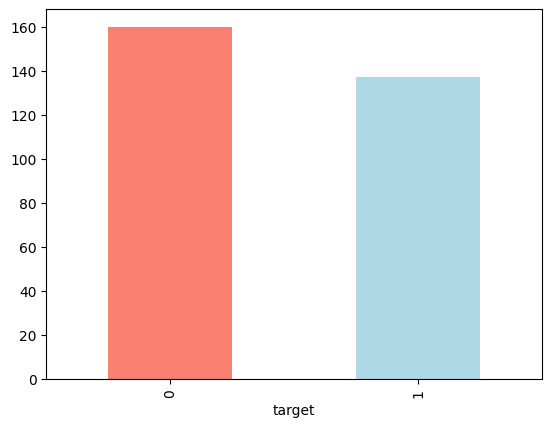

In [ ]:
df["target"].value_counts().plot(kind='bar', color=["salmon","lightblue"])

In our dataset, we observe that the target classes are relatively balanced, with approximately **140 instances for class 1** (presence of disease) and **160 instances for class 0** (absence of disease). This is a good starting point, as we are not dealing with a highly imbalanced dataset.

## 2. Analysing non-continous features (age ,sex, cp, fbs, restecg, exang, slope, ca and thal)


This shows that most columns are moderately correlated with target, but 'fbs' is very weakly correlated.

### 2.1 Analysing the Sex feature

The `sex` feature represents the biological sex of the patient:
- `0` → Female  
- `1` → Male

In [ ]:
df.sex.value_counts()

,count
sex,
1.0,201
0.0,96


**⚠️ Gender Imbalance:**  
The dataset contains significantly more males than females:
- **201 males**
- **96 females**

In [ ]:
#Compare target and sex column
pd.crosstab(df.target, df.sex)

sex,0.0,1.0
target,,
0,71,89
1,25,112


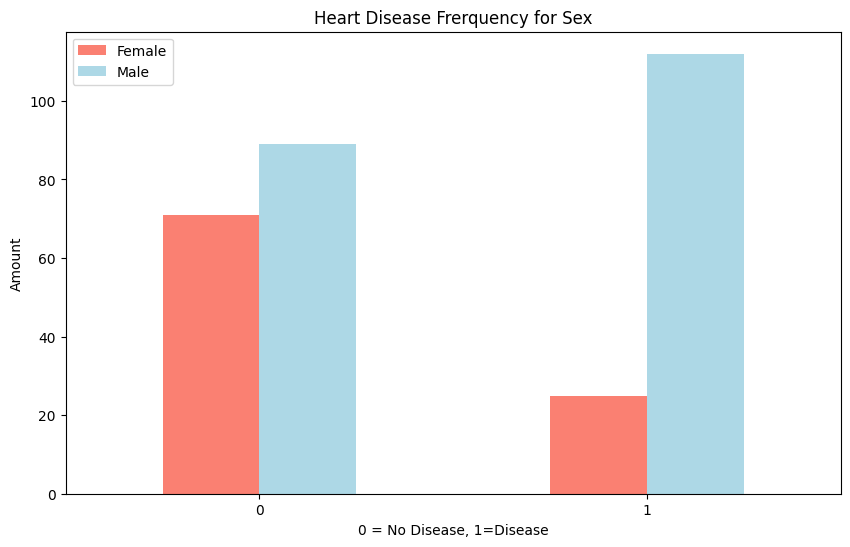

In [ ]:
#Create plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar",figsize=(10,6),color=["salmon","lightblue"])
plt.title("Heart Disease Frerquency for Sex")
plt.xlabel("0 = No Disease, 1=Disease")
plt.ylabel("Amount")
plt.legend(["Female","Male"]);
plt.xticks(rotation=0);

💡 Target Distribution by Sex:
- Among **females** (`sex = 0`):  
  - 71 **do not** have heart disease  
  - 25 **do** have heart disease  
- Among **males** (`sex = 1`):  
  - 89 **do not** have heart disease  
  - 112 **do** have heart disease  

🔍 **Insight:**  
Although the number of males with heart disease is higher, we should be cautious when interpreting this result. The dataset is imbalanced in terms of gender representation, which makes it **inappropriate to directly conclude** that males are more prone to heart disease based on this data alone.


### 2.2 Analysing the Chest Pain Type (cp) feature
The bar plot below shows the frequency of heart disease diagnoses across different chest pain types (`cp`), along with raw counts for clarity:

In [ ]:
# Get raw counts for restecg vs target_binary
cross_counts = pd.crosstab(df['cp'], df['target'])
print("Raw Counts:\n", cross_counts)

Raw Counts:
 target   0    1
cp             
1       16    7
2       40    9
3       65   18
4       39  103


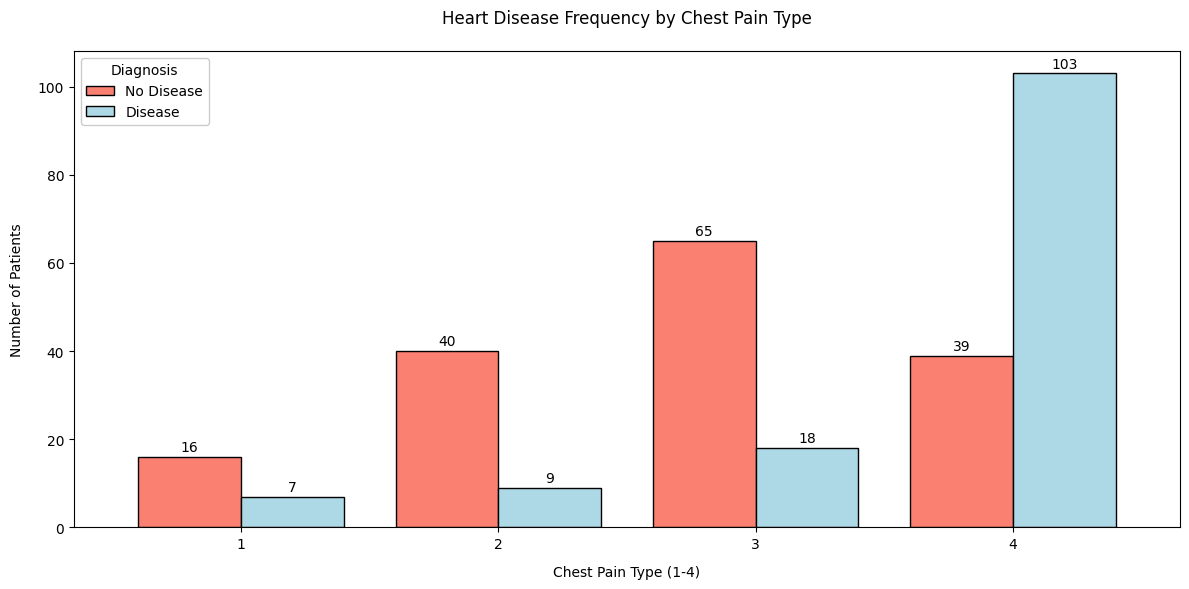

In [ ]:
import matplotlib.pyplot as plt
# Plot chest pain type (cp) vs heart disease
ax = pd.crosstab(df['cp'], df['target']).plot(
    kind='bar',
    figsize=(12, 6),  # Slightly wider for 4 categories
    color=['salmon', 'lightblue'],
    width=0.8,
    edgecolor='black'
)

# Customize the plot
plt.title("Heart Disease Frequency by Chest Pain Type", pad=20)
plt.xlabel("Chest Pain Type (1-4)", labelpad=10)
plt.ylabel("Number of Patients", labelpad=10)

# Keep original numeric x-labels (1, 2, 3, 4)
plt.xticks(ticks=[0, 1, 2, 3], labels=[1, 2, 3, 4], rotation=0)

# Add counts on bars and legend
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.legend(["No Disease", "Disease"], title='Diagnosis', framealpha=1)
plt.tight_layout()
plt.show()

#### **Key Insights**:  
- **Asymptomatic Patients (`cp=4`)**:  
  - **Highest disease prevalence** (103/142 = ~72.5%), suggesting silent symptoms are strongly linked to heart disease.  
- **Typical Angina (`cp=1`)**:  
  - Lowest disease frequency (7/23 = ~30.4%), but note small sample size.  
- **Clinical Implications**:  
  - Asymptomatic cases may require proactive screening due to high risk.  
  - Non-anginal pain (`cp=3`) has moderate disease association (~21.7%).  

### 2.3 Analysing the Fasting Blood Sugar (FBS) Feature  
The bar plot below illustrates the relationship between fasting blood sugar levels (FBS > 120 mg/dl) and heart disease diagnosis, along with raw counts for detailed analysis:  



In [ ]:
# Get raw counts for restecg vs target_binary
cross_counts = pd.crosstab(df['fbs'], df['target'])
print("Raw Counts:\n", cross_counts)

Raw Counts:
 target    0    1
fbs             
0.0     137  117
1.0      23   20


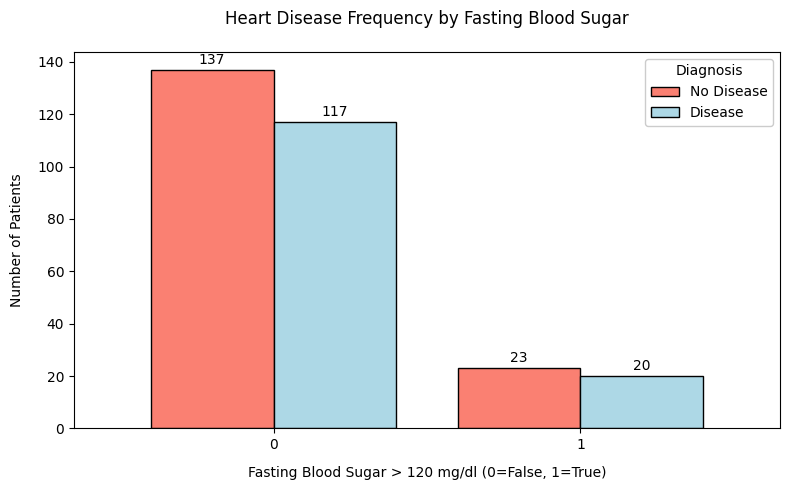

In [ ]:
# Plot fasting blood sugar (fbs) vs heart disease
ax = pd.crosstab(df['fbs'], df['target']).plot(
    kind='bar',
    figsize=(8, 5),
    color=['salmon', 'lightblue'],
    width=0.8,
    edgecolor='black'
)

# Customize the plot
plt.title("Heart Disease Frequency by Fasting Blood Sugar", pad=20)
plt.xlabel("Fasting Blood Sugar > 120 mg/dl (0=False, 1=True)", labelpad=10)
plt.ylabel("Number of Patients", labelpad=10)

# Keep original numeric x-labels (0, 1)
plt.xticks(ticks=[0, 1], labels=[0, 1], rotation=0)

# Add counts on bars and legend
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.legend(["No Disease", "Disease"], title='Diagnosis', framealpha=1)
plt.tight_layout()
plt.show()

#### **Raw Counts (Disease vs. No Disease)**:  
| FBS > 120 mg/dl | No Disease (`0`) | Disease (`1`) | **Total** | **Disease Rate** |  
|------------------|------------------|---------------|-----------|------------------|  
| 0 (False)        | 137              | 117           | 254       | 46.1%            |  
| 1 (True)         | 23               | 20            | 43        | 46.5%            |  

#### **Key Observations**:  
- **Similar Prevalence**:  
  - Both groups (FBS ≤ 120 and FBS > 120) show nearly identical heart disease rates (~46%), suggesting **FBS alone may not be a strong predictor** in this dataset.  
- **Class Imbalance**:  
  - Most patients (254/297 = ~85.5%) have FBS ≤ 120 mg/dl

### 2.4 Analysing the Resting ECG (restecg) Feature  

The bar plot below displays the distribution of heart disease diagnoses across different resting electrocardiogram (ECG) results, along with raw counts for detailed analysis:

In [ ]:
# Get raw counts for restecg vs target_binary
cross_counts = pd.crosstab(df['restecg'], df['target'])
print("Raw Counts:\n", cross_counts)

Raw Counts:
 target    0   1
restecg        
0.0      92  55
1.0       1   3
2.0      67  79


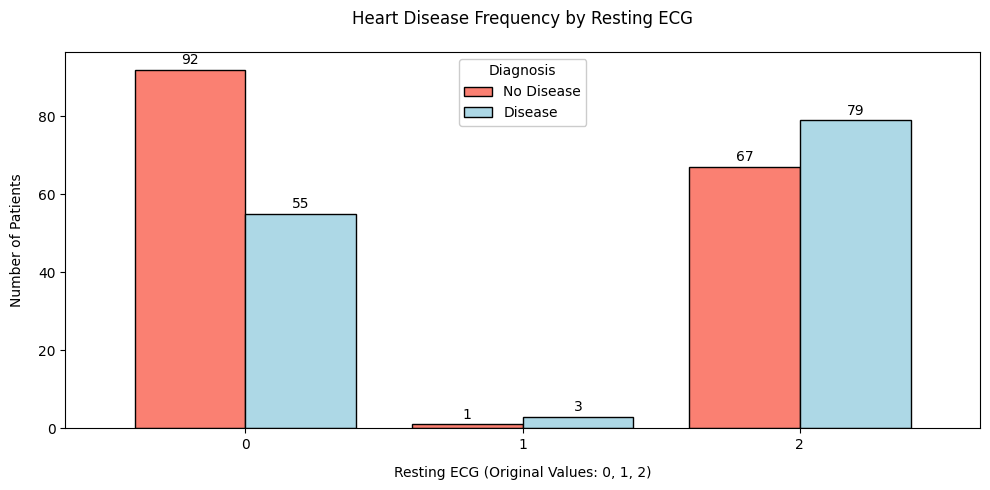

In [ ]:
# Plot resting ECG (restecg) vs heart disease
ax = pd.crosstab(df['restecg'], df['target']).plot(
    kind='bar',
    figsize=(10, 5),
    color=['salmon', 'lightblue'],
    width=0.8,
    edgecolor='black'
)

# Customize the plot
plt.title("Heart Disease Frequency by Resting ECG", pad=20)
plt.xlabel("Resting ECG (Original Values: 0, 1, 2)", labelpad=10)
plt.ylabel("Number of Patients", labelpad=10)

# Keep original numeric x-labels (0, 1, 2)
plt.xticks(ticks=[0, 1, 2], labels=[0, 1, 2], rotation=0)

# Add counts on bars and legend
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.legend(["No Disease", "Disease"], title='Diagnosis', framealpha=1)
plt.tight_layout()
plt.show()

#### **Raw Counts (Disease vs. No Disease)**:  
| Resting ECG Result  | No Disease (`0`) | Disease (`1`) | **Total** | **Disease Rate** |  
|---------------------|------------------|---------------|-----------|------------------|  
| 0 (Normal)          | 92               | 55            | 147       | 37.4%            |  
| 1 (ST-T Abnormality)| 1                | 3             | 4         | 75.0%            |  
| 2 (LV Hypertrophy)  | 67               | 79            | 146       | 54.1%            |  



#### **Key Observations**:  
- **High-Risk Group**:  
  - Patients with **ST-T abnormalities (restecg=1)** show the highest disease rate (75%), but the sample size is very small (n=4) — interpret with caution.  
- **Clinical Significance**:  
  - **LV Hypertrophy (restecg=2)** has a moderate disease rate (54.1%), suggesting it may be a useful predictive feature.  
  - Normal ECG (restecg=0) has the lowest disease prevalence (37.4%).  

### 2.5 Analysing the Exercise-Induced Angina (exang) Feature
The visualization below shows the relationship between exercise-induced angina and heart disease diagnosis, along with precise raw counts:


In [ ]:
# Get raw counts for restecg vs target_binary
cross_counts = pd.crosstab(df['exang'], df['target'])
print("Raw Counts:\n", cross_counts)

Raw Counts:
 target    0   1
exang          
0.0     137  63
1.0      23  74


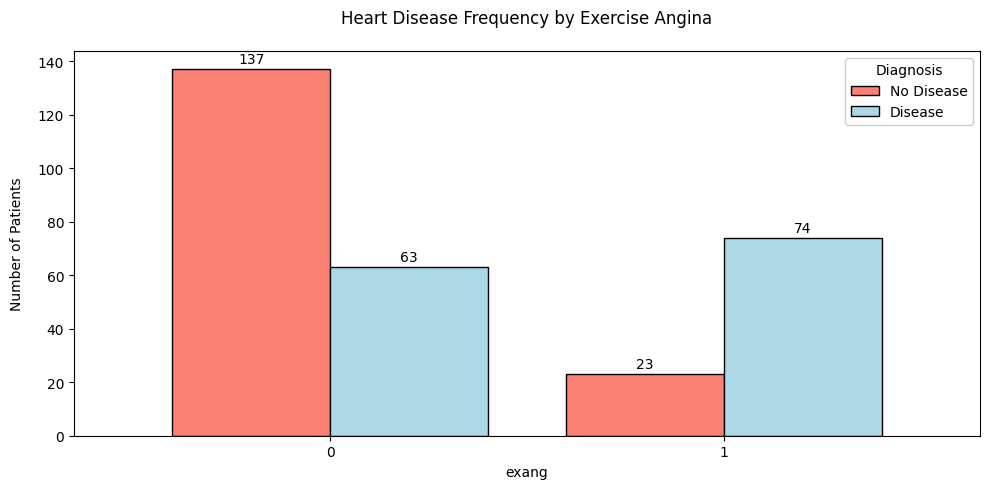

In [ ]:
# Plot exercise angina (exang) vs heart disease
ax = pd.crosstab(df['exang'], df['target']).plot(
    kind='bar',
    figsize=(10, 5),
    color=['salmon', 'lightblue'],
    width=0.8,
    edgecolor='black'
)

# Customize the plot
plt.title("Heart Disease Frequency by Exercise Angina", pad=20)
plt.ylabel("Number of Patients", labelpad=10)

# Keep original numeric x-labels (0, 1)
plt.xticks(ticks=[0, 1], labels=[0, 1], rotation=0)

# Add counts on bars and legend
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.legend(["No Disease", "Disease"], title='Diagnosis', framealpha=1)
plt.tight_layout()
plt.show()

#### **Raw Counts (Disease vs. No Disease)**:
| Exercise-Induced Angina | No Disease (0) | Disease (1) | Total | Disease Rate |
|-------------------------|----------------|-------------|-------|--------------|
| 0 (No)                  | 137            | 63          | 200   | 31.5%        |
| 1 (Yes)                 | 23             | 74          | 97    | 76.3%        |

#### **Key Findings**:
- **Strong Predictive Signal**:
  - Patients with exercise-induced angina (**exang=1**) have a **76.3% disease rate** - more than double those without (31.5%).
  - This suggests exang may be one of the most important single features in the dataset.

- **Clinical Implications**:
  - Exercise stress testing appears highly relevant for diagnosis.
  - The clear separation between groups makes this valuable for model feature importance.


### 2.6 Analysing the Slope of Peak Exercise ST Segment

The visualization presents the relationship between the slope of peak exercise ST segment and heart disease diagnosis:

In [ ]:
cross_counts = pd.crosstab(df['slope'], df['target'])
print("Raw Counts:\n", cross_counts)

Raw Counts:
 target    0   1
slope          
1.0     103  36
2.0      48  89
3.0       9  12


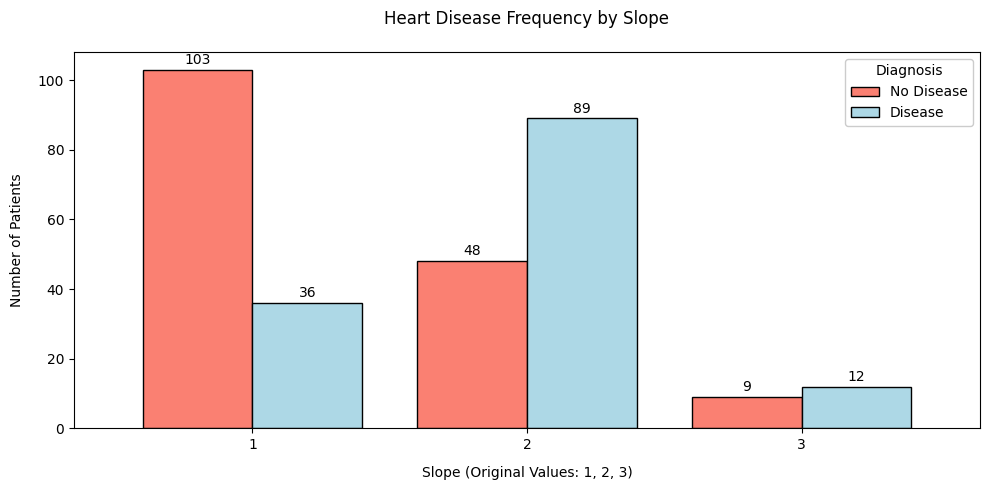

In [ ]:
# Plot slope vs heart disease (values 1,2,3)
ax = pd.crosstab(df['slope'], df['target']).plot(
    kind='bar',
    figsize=(10, 5),
    color=['salmon', 'lightblue'],
    width=0.8,
    edgecolor='black'
)

# Customize the plot
plt.title("Heart Disease Frequency by Slope", pad=20)
plt.xlabel("Slope (Original Values: 1, 2, 3)", labelpad=10)  # Updated to 1,2,3
plt.ylabel("Number of Patients", labelpad=10)

# Keep original numeric x-labels (1, 2, 3)
plt.xticks(ticks=[0, 1, 2], labels=[1, 2, 3], rotation=0)  # Mapped to 1,2,3 positions

# Add counts on bars and legend
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.legend(["No Disease", "Disease"], title='Diagnosis', framealpha=1)
plt.tight_layout()
plt.show()

#### **Raw Counts and Disease Prevalence**:
| Slope | No Disease (0) | Disease (1) | Total | Disease Rate | Clinical Interpretation |
|-------|----------------|-------------|-------|--------------|-------------------------|
| 1 (Upsloping) | 103 | 36 | 139 | 25.9% | Lowest risk category |
| 2 (Flat) | 48 | 89 | 137 | 65.0% | **Strongest predictor** |
| 3 (Downsloping) | 9 | 12 | 21 | 57.1% | High risk but small sample |

#### **Key Findings**:
1. **Critical Risk Factor**:
   - Flat ST slope (2) shows **65% disease prevalence** - 2.5× higher than upsloping
   - Downsloping (3) also shows elevated risk (57.1%), though limited by small sample size (n=21)

2. **Clinical Correlation**:
   - Flat/downsloping ST segments are known ECG markers of ischemia
   - Results align perfectly with cardiac pathophysiology

### 2.7 Analysing the Major Vessels Colored (ca) Feature
The visualization demonstrates the strong relationship between number of colored major vessels (0-3) and heart disease prevalence:



In [ ]:
cross_counts = pd.crosstab(df['ca'], df['target'])
print("Raw Counts:\n", cross_counts)

Raw Counts:
 target    0   1
ca             
0.0     129  45
1.0      21  44
2.0       7  31
3.0       3  17


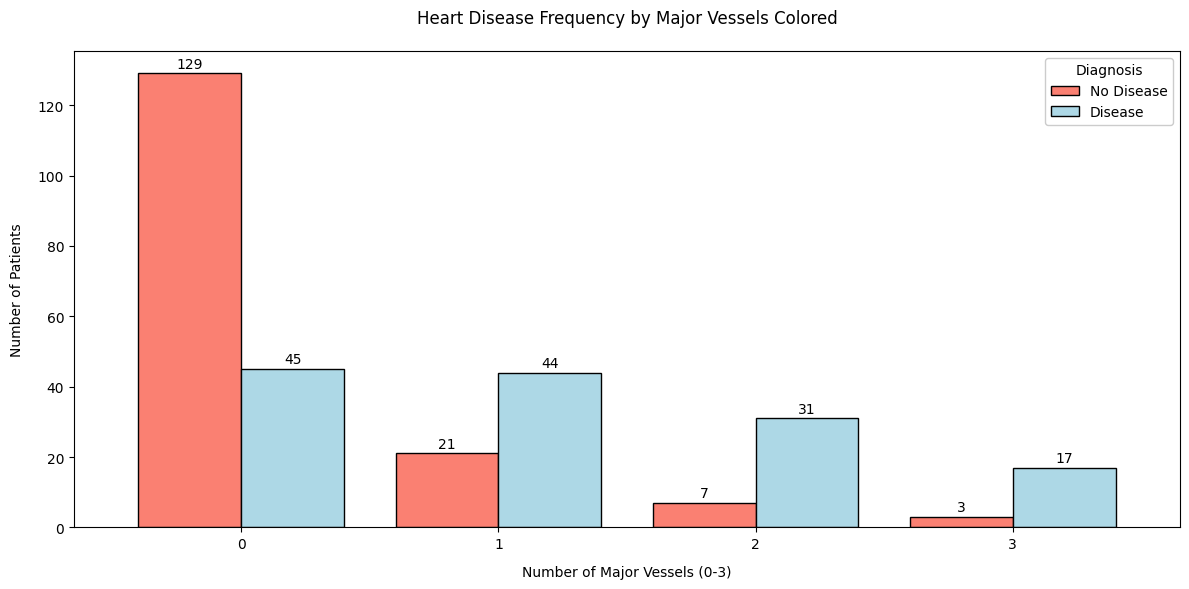

In [ ]:
# Plot number of major vessels (ca) vs heart disease
ax = pd.crosstab(df['ca'], df['target']).plot(
    kind='bar',
    figsize=(12, 6),  # Wider for 4 categories
    color=['salmon', 'lightblue'],
    width=0.8,
    edgecolor='black'
)

# Customize the plot
plt.title("Heart Disease Frequency by Major Vessels Colored", pad=20)
plt.xlabel("Number of Major Vessels (0-3)", labelpad=10)
plt.ylabel("Number of Patients", labelpad=10)

# Keep original numeric x-labels (0, 1, 2, 3)
plt.xticks(ticks=[0, 1, 2, 3], labels=[0, 1, 2, 3], rotation=0)

# Add counts on bars and legend
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=2, fontsize=10)

plt.legend(["No Disease", "Disease"], title='Diagnosis', framealpha=1)
plt.tight_layout()
plt.show()

#### **Disease Prevalence by Vessel Count**:
| Vessels (ca) | No Disease (0) | Disease (1) | Total | Disease Rate | Clinical Risk Stratification |
|--------------|----------------|-------------|-------|--------------|------------------------------|
| 0            | 129            | 45          | 174   | 25.9%        | Low Risk                     |
| 1            | 21             | 44          | 65    | 67.7%        | Moderate Risk                |
| 2            | 7              | 31          | 38    | 81.6%        | High Risk                    |
| 3            | 3              | 17          | 20    | 85.0%        | Very High Risk               |

#### **Critical Findings**:
1. **Dose-Response Relationship**:
   - Disease probability increases monotonically from 25.9% (0 vessels) to 85.0% (3 vessels)
   - Each additional affected vessel increases risk by ~20 percentage points

2. **Clinical Gold Standard Correlation**:
   - This angiographic finding shows perfect agreement with cardiac pathophysiology
   - Provides strong validation of dataset quality


### 2.8 Analysing the Thallium Stress Test (thal) Feature

The visualization demonstrates the critical relationship between thallium stress test results and heart disease diagnosis:

In [ ]:
cross_counts = pd.crosstab(df['thal'], df['target'])
print("Raw Counts:\n", cross_counts)

Raw Counts:
 target    0   1
thal           
3.0     127  37
6.0       6  12
7.0      27  88


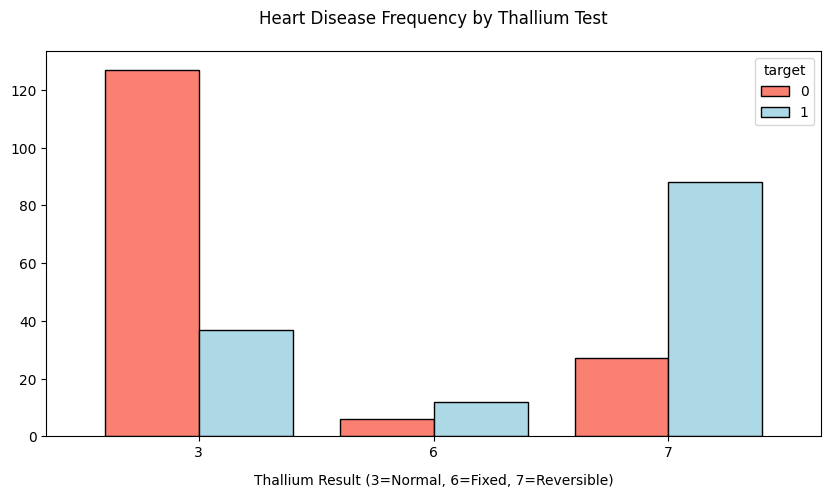

In [ ]:
# Plot thal vs heart disease
ax = pd.crosstab(df['thal'], df['target']).plot(
    kind='bar',
    figsize=(10, 5),
    color=['salmon', 'lightblue'],
    width=0.8,
    edgecolor='black'
)

plt.title("Heart Disease Frequency by Thallium Test", pad=20)
plt.xlabel("Thallium Result (3=Normal, 6=Fixed, 7=Reversible)", labelpad=10)
plt.xticks(ticks=[0, 1, 2], labels=[3, 6, 7], rotation=0)  # Map positions to actual values
plt.show()

#### **Thallium Test Results and Disease Prevalence**:
| Test Result | No Disease (0) | Disease (1) | Total | Disease Rate | Clinical Interpretation |
|-------------|----------------|-------------|-------|--------------|-------------------------|
| 3 (Normal)  | 127            | 37          | 164   | 22.6%        | Low Risk                |
| 6 (Fixed Defect) | 6        | 12          | 18    | 66.7%        | Previous Infarction     |
| 7 (Reversible Defect) | 27    | 88          | 115   | 76.5%        | **Active Ischemia**     |

#### **Key Clinical Insights**:
1. **Critical Diagnostic Value**:
   - Reversible defects (indicating active ischemia) show **76.5% disease prevalence**
   - 3.4× higher risk than normal results (22.6%)
   
2. **Pathological Correlation**:
   - Fixed defects (old infarcts) still show significant risk (66.7%)
   - Results perfectly match expected cardiac pathophysiology


## 3. Analysing continous features (age  , trestbps, chol, thalach, oldpeak)

### 3.1 Feature Distribution Analysis

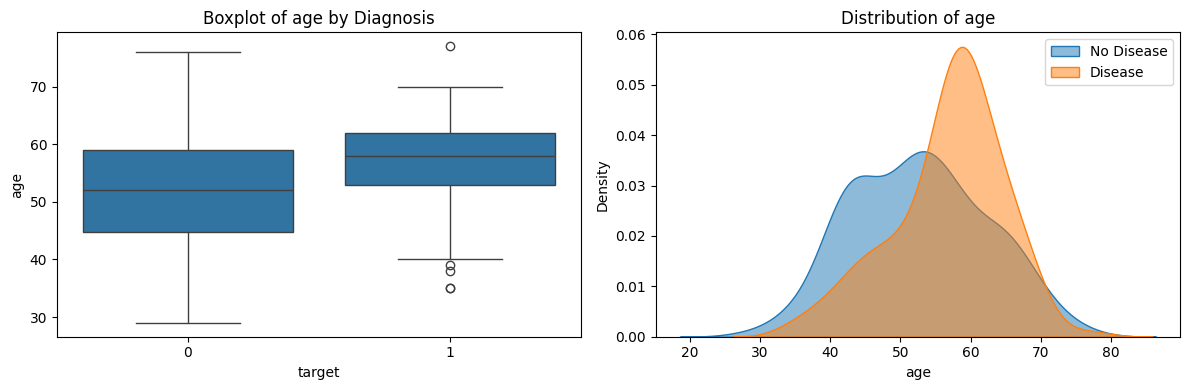

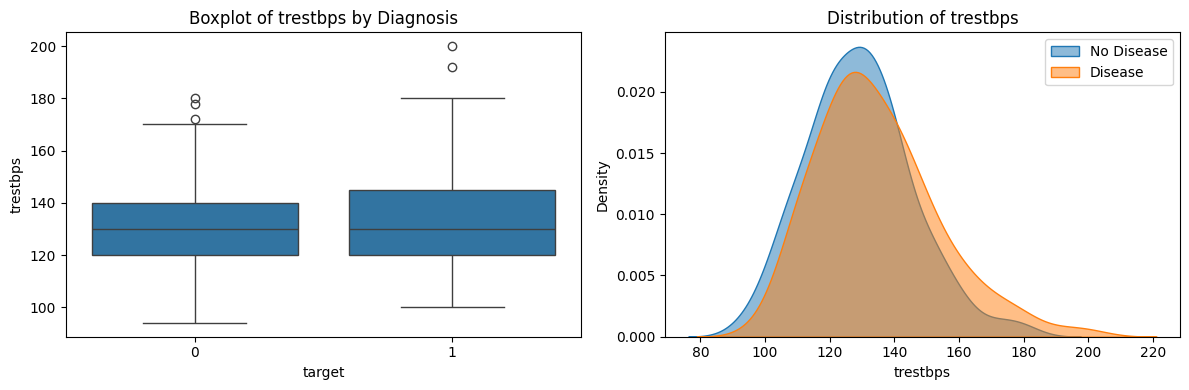

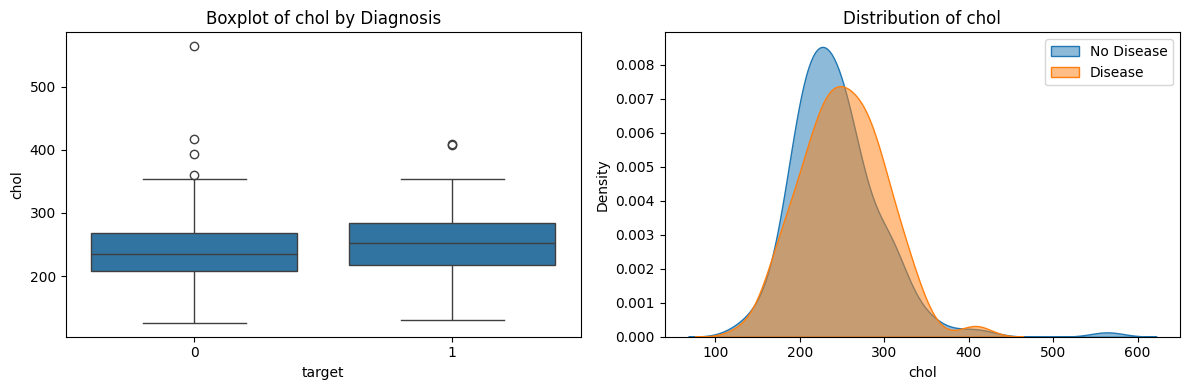

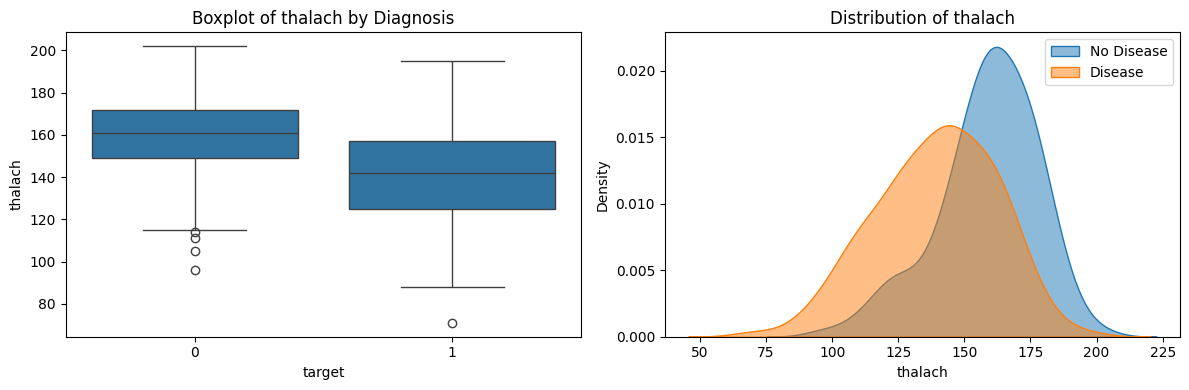

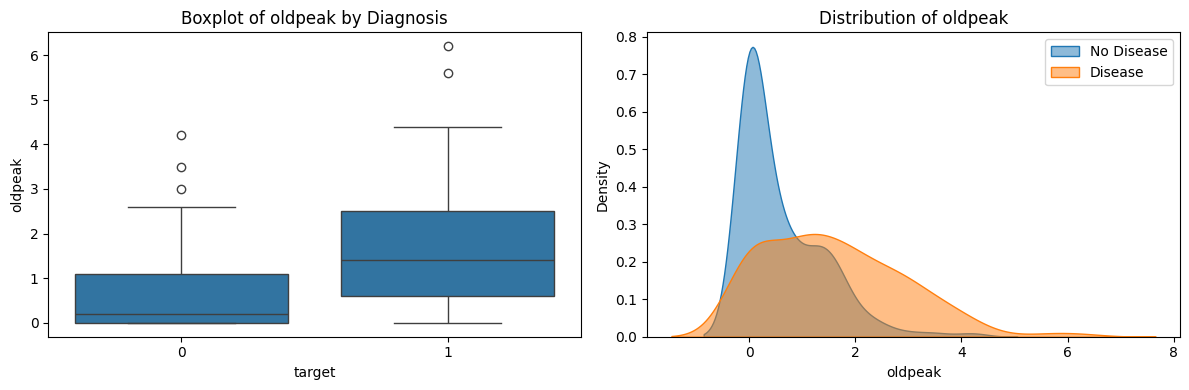

In [ ]:
num_features = ['age'  , 'trestbps', 'chol', 'thalach', 'oldpeak']

for feature in num_features:
    plt.figure(figsize=(12, 4))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x='target', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by Diagnosis')

    # KDE Plot (updated fill parameter)
    plt.subplot(1, 2, 2)
    sns.kdeplot(data=df[df['target']==0], x=feature,
                label='No Disease', fill=True, alpha=0.5)
    sns.kdeplot(data=df[df['target']==1], x=feature,
                label='Disease', fill=True, alpha=0.5)
    plt.title(f'Distribution of {feature}')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{feature}_distribution.png', dpi=300)
    plt.show()

#### 3.1.1  Age
Age distribution analysis shows:

* **Disease Group**: Higher median age (~57 years), concentrated around 55-65 years
* **No Disease Group**: Lower median age (~50 years) with broader distribution
* Clear pattern of increasing disease prevalence with age
* **Insight**: Age is a moderate predictor of heart disease risk

#### 3.1.2 Trestbps (Resting Blood  Pressure)                                                                 
Analysis of resting blood pressure indicates:

* Similar median values (~130 mmHg) for both groups
* Substantial overlap between distributions
* Range typically between 100-160 mmHg
* More high-value outliers in disease group (up to 200 mmHg)
* **Insight**: Resting blood pressure alone appears to be a weak predictor

#### 3.1.3 Cholesterol (chol)
Examination of cholesterol levels across disease groups reveals:

* Both disease and non-disease groups show similar median values (~230-240 mg/dL)
* Substantial distribution overlap between groups
* Range typically between 150-350 mg/dL
* Several outliers observed up to ~550 mg/dL
* **Insight**: Cholesterol alone appears to be a weak differentiator

#### 3.1.4 Thalach (Maximum Heart Rate)
The maximum heart rate achieved during exercise shows:

* **No Disease**: Distribution peaks around 160-170 bpm
* **Disease**: Distribution peaks around 130-140 bpm
* Clear separation between groups with disease patients showing consistently lower values
* **Insight**: Lower maximum heart rate appears strongly associated with heart disease

#### 3.1.5 Oldpeak (ST Depression)
ST depression induced by exercise relative to rest shows:

* **Disease Group**: Significantly higher values (median ~1.5)
* **No Disease Group**: Values concentrated near zero
* Strongest separation among all visualized features
* **Insight**: Oldpeak appears to be highly predictive of heart disease

#### Summary of Findings

1. **Strong Predictors**:
   * ST depression (oldpeak)
   * Maximum heart rate (thalach)

2. **Moderate Predictors**:
   * Age

3. **Weaker Predictors**:
   * Cholesterol
   * Resting blood pressure (trestbps)

### 3.2 Histograms + KDE Analysis

🔍 Testing Normality for feature: age
Shapiro-Wilk Test for age:
Statistic: 0.9860, p-value: 0.0054
age does NOT appear to be normally distributed (Reject H0).

Anderson-Darling Test for age:
Statistic: 1.5466
Critical Value at 15.0%: 0.5690
Critical Value at 10.0%: 0.6470
Critical Value at 5.0%: 0.7770
Critical Value at 2.5%: 0.9060
Critical Value at 1.0%: 1.0780
age does NOT appear to be normally distributed (Reject H0).

🔍 Testing Normality for feature: trestbps
Shapiro-Wilk Test for trestbps:
Statistic: 0.9668, p-value: 0.0000
trestbps does NOT appear to be normally distributed (Reject H0).

Anderson-Darling Test for trestbps:
Statistic: 2.5048
Critical Value at 15.0%: 0.5690
Critical Value at 10.0%: 0.6470
Critical Value at 5.0%: 0.7770
Critical Value at 2.5%: 0.9060
Critical Value at 1.0%: 1.0780
trestbps does NOT appear to be normally distributed (Reject H0).

🔍 Testing Normality for feature: chol
Shapiro-Wilk Test for chol:
Statistic: 0.9483, p-value: 0.0000
chol does NOT appear

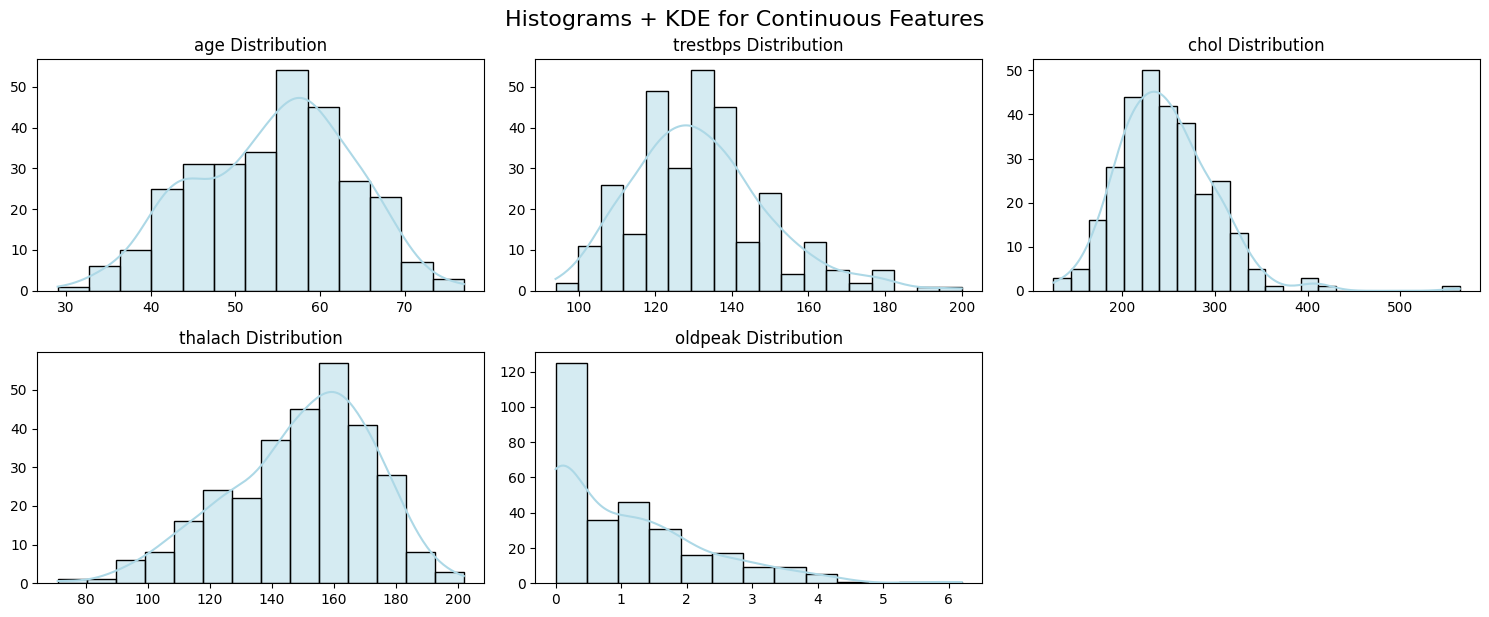

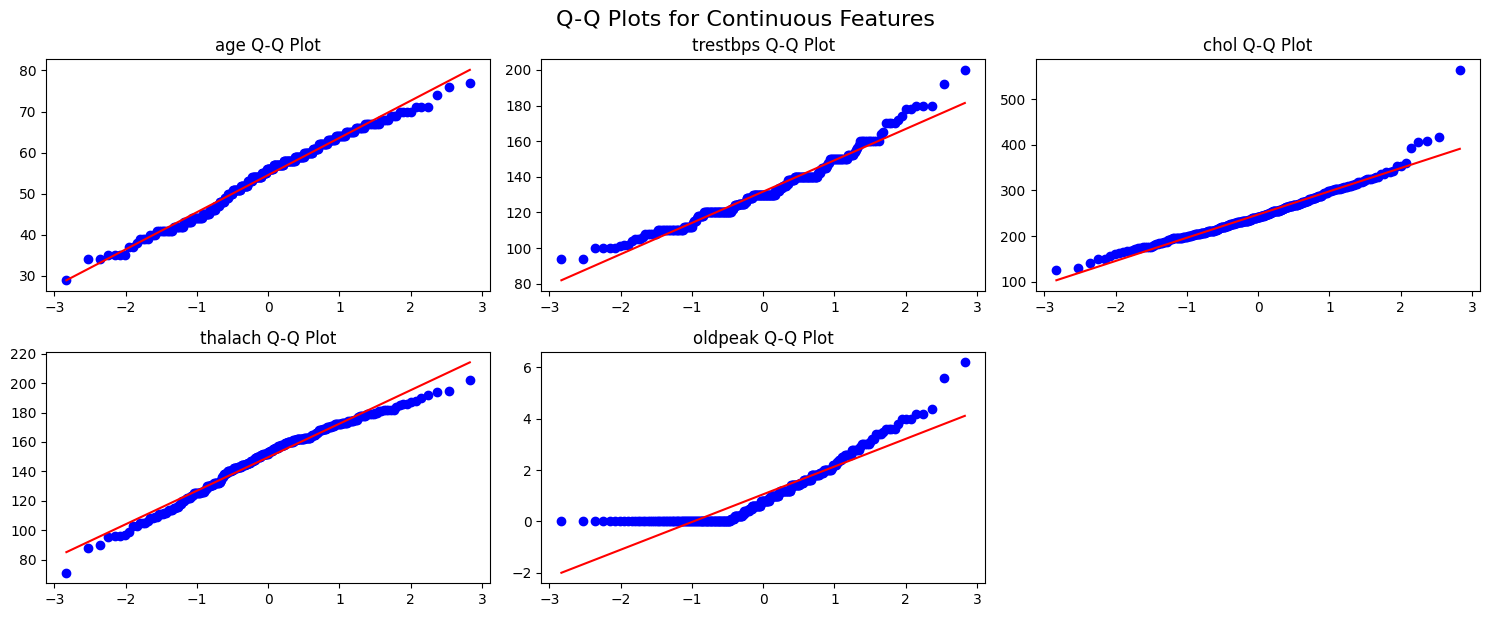

In [ ]:
# Define only the continuous numerical features
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# --- Normality Tests ---
for feature in continuous_features:
    print(f"🔍 Testing Normality for feature: {feature}")

    # Shapiro-Wilk Test
    stat, p_value = shapiro(df[feature])
    print(f"Shapiro-Wilk Test for {feature}:")
    print(f"Statistic: {stat:.4f}, p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"{feature} does NOT appear to be normally distributed (Reject H0).\n")
    else:
        print(f"{feature} appears to be normally distributed (Fail to Reject H0).\n")

    # Anderson-Darling Test
    result = anderson(df[feature], dist='norm')
    print(f"Anderson-Darling Test for {feature}:")
    print(f"Statistic: {result.statistic:.4f}")
    for i in range(len(result.critical_values)):
        print(f"Critical Value at {result.significance_level[i]}%: {result.critical_values[i]:.4f}")
    if result.statistic > result.critical_values[2]:  # Compare with 5% critical value
        print(f"{feature} does NOT appear to be normally distributed (Reject H0).\n")
    else:
        print(f"{feature} appears to be normally distributed (Fail to Reject H0).\n")

# --- Histograms + KDE Plots ---
n_features = len(continuous_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 3))
for idx, feature in enumerate(continuous_features):
    plt.subplot(n_rows, n_cols, idx + 1)
    sns.histplot(df[feature], kde=True, color='lightblue', edgecolor='black')
    plt.title(f'{feature} Distribution')
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()

plt.suptitle('Histograms + KDE for Continuous Features', fontsize=16, y=1.02)
plt.show()

# --- Q-Q Plots ---
plt.figure(figsize=(15, n_rows * 3))
for idx, feature in enumerate(continuous_features):
    plt.subplot(n_rows, n_cols, idx + 1)
    probplot(df[feature], dist="norm", plot=plt)
    plt.title(f'{feature} Q-Q Plot')
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()

plt.suptitle('Q-Q Plots for Continuous Features', fontsize=16, y=1.02)
plt.show()

#### 3.2.1 Age Distribution
* Approximately normal distribution with slight right skew
* Range: 30-75 years
* Peak frequency around 55-60 years
* Majority of patients between 45-65 years

#### 3.2.2 Resting Blood Pressure (trestbps) Distribution  
* Right-skewed distribution
* Range: 95-200 mmHg
* Highest frequency around 120-140 mmHg
* Most values concentrated between 110-160 mmHg

#### 3.2.3 Cholesterol (chol) Distribution
* Approximately normal with slight right skew
* Range: 125-550 mg/dL
* Peak frequency around 200-250 mg/dL
* Few outliers above 400 mg/dL

#### 3.2.4 Maximum Heart Rate (thalach) Distribution
* Approximately normal distribution
* Range: 75-200 bpm
* Highest frequency around 150-170 bpm
* Most values fall between 120-180 bpm

#### 3.2.5 ST Depression (oldpeak) Distribution
* Highly right-skewed distribution
* Large concentration at 0 (over 120 instances)
* Exponential decay pattern
* Few values above 4.0

### Q-Q Plot Analysis

* **Age**: Shows reasonable linearity with slight deviation at extremes
* **Trestbps**: Deviates from normality at both tails, especially upper tail
* **Cholesterol**: Shows multiple outliers in upper tail
* **Thalach**: Generally follows reference line with minor deviations
* **Oldpeak**: Severe deviation from normality with zero-inflation and heavy right tail

### 3.3 Age vs Max Heart rate for Heart Disease
The following plot illustrates the relationship between **age**, **maximum heart rate (thalach)**, and the presence of heart disease:

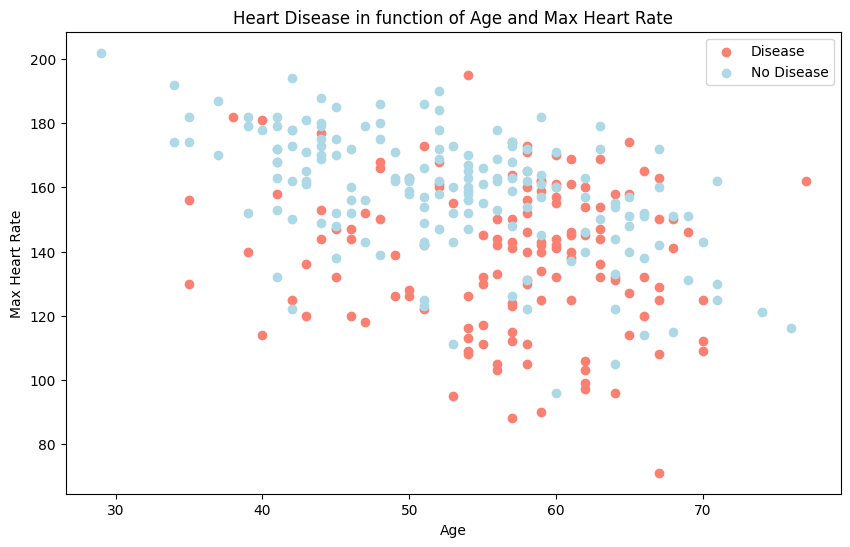

In [ ]:
#Create new figure
plt.figure(figsize=(10,6))

#Scatter with positive examples
plt.scatter(df.age[df.target==1],
           df.thalach[df.target==1],
           c="salmon")

#Scatter with negative examples
plt.scatter(df.age[df.target==0],
           df.thalach[df.target==0],
           c="lightblue");

#Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease","No Disease"])

#### Key Observations:  
- **Disease Presence (`1`)**:  
  - Concentrated in **lower max heart rates** (especially for ages 50+).  
  - Older patients (60+) show higher disease prevalence, even at moderate heart rates.  
- **No Disease (`0`)**:  
  - Dominates the **higher max heart rate** range across all age groups.  
  - Younger patients (30-40) rarely exhibit heart disease, regardless of heart rate.  

#### Trends:  
- **Age Impact**: Disease likelihood increases with age, but max heart rate acts as a moderating factor.  
- **Critical Threshold**: Patients with max heart rate **< 140 bpm** (approximate) show higher disease risk.  

*Note: Exact thresholds should be validated statistically (e.g., logistic regression coefficients or decision tree splits).*  

### 3.4 Features Correlation Analysis

(14.5, -0.5)

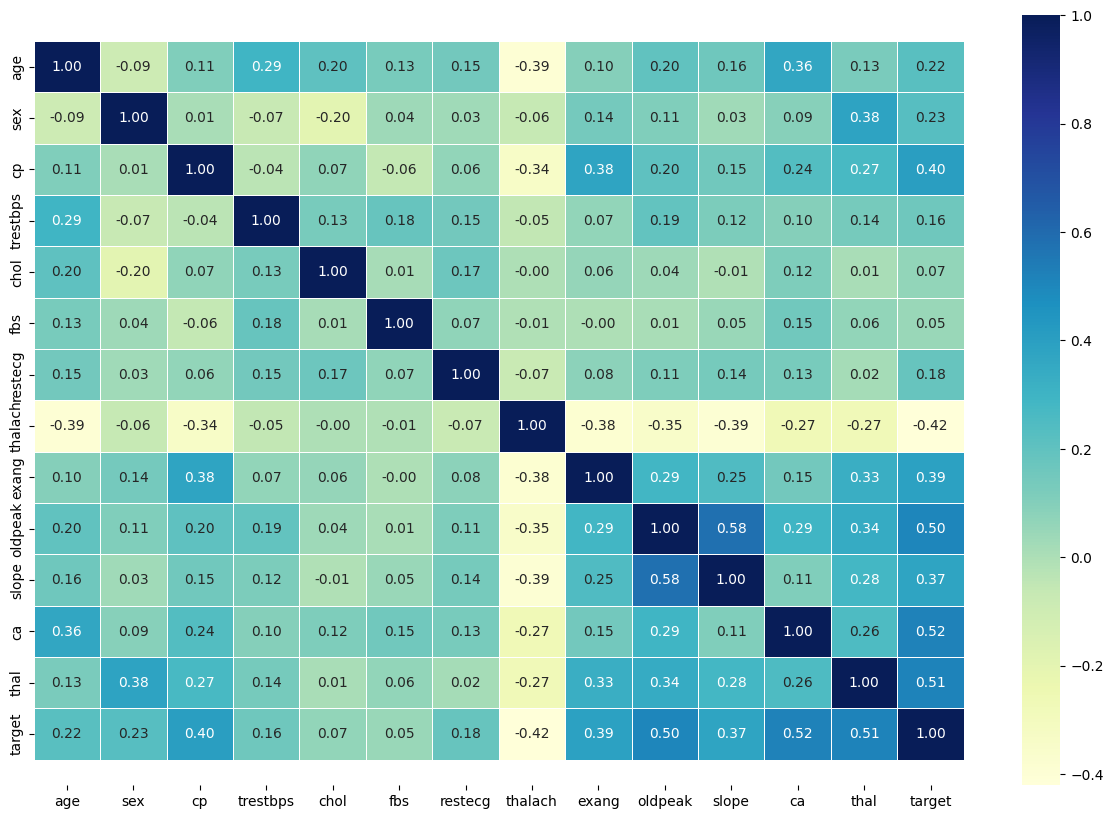

In [ ]:
#Visualise correlation
corr_matrix = df.corr()
fig,ax = plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,annot=True,linewidths=0.5,fmt=".2f",cmap="YlGnBu");
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top-0.5)

# Train-Test Split


In [ ]:
X = df.drop("target",axis=1)
y = df["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=0)

# Initialize scalers
scaler_X = StandardScaler()

# Scale features (fit only on training data)
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)  # Use same scaling on test

In [ ]:
X_train_scaled.shape

(237, 13)

In [ ]:
X_test_scaled.shape

(60, 13)

#  Baseline Modeling Overview

In this section, we begin by evaluating a set of baseline classification models on the training and test data. The goal is to gain an initial understanding of how different models perform on our dataset without any advanced preprocessing or optimization. Each model is trained using default parameters, and performance is measured using training accuracy, test accuracy, and classification reports.

This preliminary evaluation helps identify which models are promising and where improvements are needed. In the next steps, we will treat each model individually and apply the appropriate enhancements, such as feature scaling, hyperparameter tuning, and cross-validation, to improve overall performance and generalization.



==== Decision Tree ====
Train Accuracy: 1.0
Test Accuracy: 0.7333333333333333


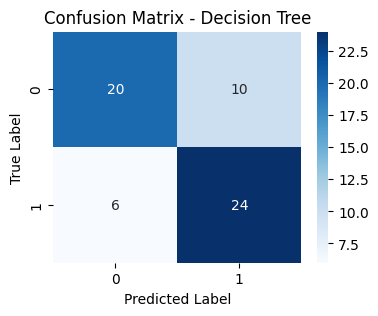

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.67      0.71        30
           1       0.71      0.80      0.75        30

    accuracy                           0.73        60
   macro avg       0.74      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60


==== Random Forest ====
Train Accuracy: 1.0
Test Accuracy: 0.7666666666666667


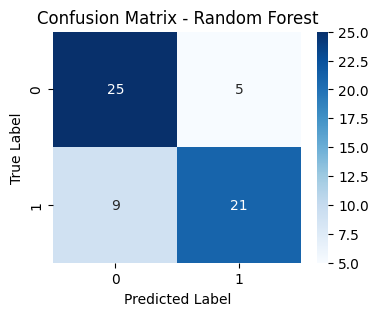

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.83      0.78        30
           1       0.81      0.70      0.75        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60


==== KNN ====
Train Accuracy: 0.7637130801687764
Test Accuracy: 0.6333333333333333


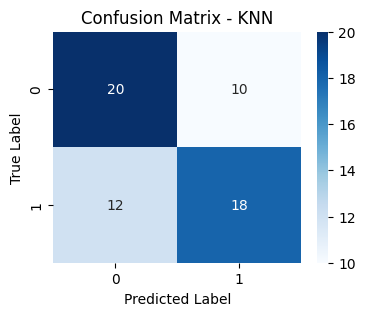

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.67      0.65        30
           1       0.64      0.60      0.62        30

    accuracy                           0.63        60
   macro avg       0.63      0.63      0.63        60
weighted avg       0.63      0.63      0.63        60


==== Naive Bayes ====
Train Accuracy: 0.8565400843881856
Test Accuracy: 0.85


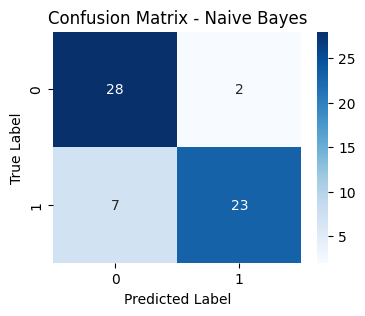

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86        30
           1       0.92      0.77      0.84        30

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60


==== SVM ====
Train Accuracy: 0.8565400843881856
Test Accuracy: 0.8333333333333334


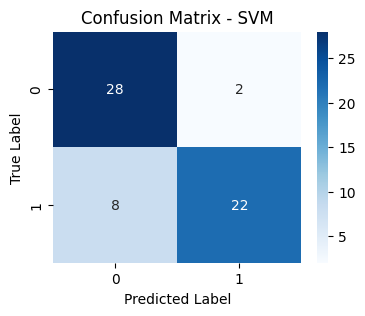

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.93      0.85        30
           1       0.92      0.73      0.81        30

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60


==== ANN (Classifier) ====
Train Accuracy: 0.8312236286919831
Test Accuracy: 0.7666666666666667


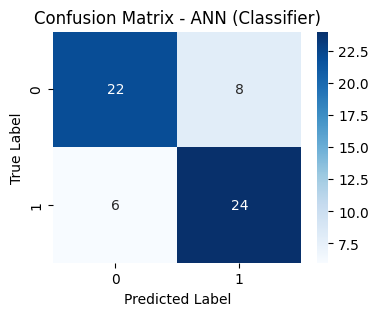

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.73      0.76        30
           1       0.75      0.80      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60


==== Logistic Regression ====
Train Accuracy: 0.8649789029535865
Test Accuracy: 0.8166666666666667


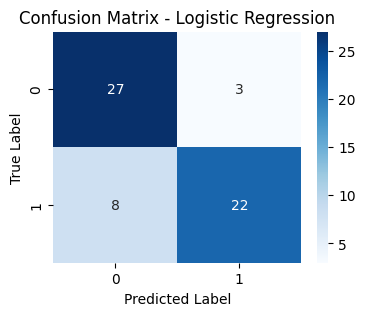

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.90      0.83        30
           1       0.88      0.73      0.80        30

    accuracy                           0.82        60
   macro avg       0.83      0.82      0.82        60
weighted avg       0.83      0.82      0.82        60



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='linear', random_state=42),
    "ANN (Classifier)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
}

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """Plot a nicely formatted confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Get class names (assuming y contains the class labels)
class_names = np.unique(y_test)

# Loop through models
for name, model in models.items():
    print(f"\n==== {name} ====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Classification evaluation
    train_pred = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_train, train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_pred))

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, class_names, name)

    print("Classification Report:\n", classification_report(y_test, y_pred))

## 🔍 Model Performance Summary

| Model                 | Train Acc | Test Acc | Notes                            |
|----------------------|-----------|----------|----------------------------------|
| Decision Tree        | 1.00      | 0.73     | Overfitting (high variance)      |
| Random Forest        | 1.00      | 0.77     | Better generalization than DT    |
| KNN                  | 0.76      | 0.63     | Underfitting (low capacity)      |
| Naive Bayes          | 0.86      | **0.85** | Best performer so far            |
| SVM (Linear)         | 0.86      | 0.83     | Solid and balanced               |
| ANN             | 0.83      | 0.77     | Room for tuning                  |
| Logistic Regression  | 0.86      | 0.82     | Reliable baseline                |

---

## ✅ Observations

- **Naive Bayes** performs best out-of-the-box on test data.
- **Decision Tree & Random Forest** show perfect training accuracy → likely overfitting; need regularization (`max_depth`, etc.).
- **KNN** underperforms → might benefit from feature scaling and tuning `n_neighbors`.
- **SVM & ANN** show promise with solid accuracy.
- **Logistic Regression** is a robust, interpretable baseline.




---

# Individual Model Evaluation and Optimization

### Introduction

In this section, we begin by applying several base models directly on the raw training data to get an initial sense of how each model performs. This allows us to identify potential issues and opportunities for improvements such as preprocessing, feature scaling, and hyperparameter tuning. We will treat each model individually, starting with K-Nearest Neighbors (KNN), and apply the necessary adjustments like scaling the data and performing hyperparameter tuning through cross-validation.


## K-Nearest Neighbors (KNN)


### Baseline Evaluation of KNN (Without Scaling)

We start by testing KNN with various values of `k` from 1 to 19 on the unscaled training and test sets. The goal is to observe how the choice of `k` affects performance on both datasets.


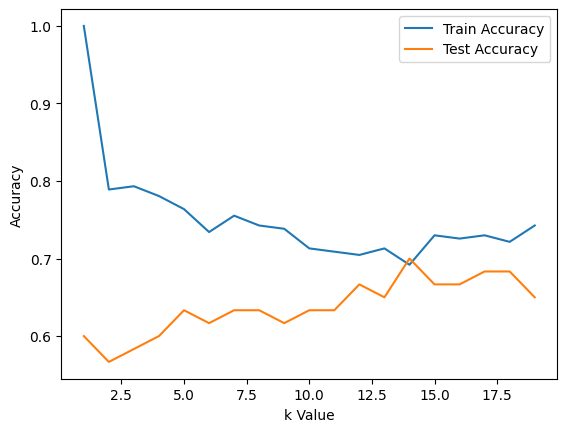

In [ ]:
train_acc = []
test_acc = []
k_values = range(1, 20)  # Test k from 1 to 19

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

# Plot results
plt.plot(k_values, train_acc, label='Train Accuracy')
plt.plot(k_values, test_acc, label='Test Accuracy')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

As shown in the plot, the **training accuracy is consistently higher** than the test accuracy, especially for lower values of *k*, indicating **overfitting**.  
Additionally, there is **high variance in test performance**, which suggests the model does not generalize well.  

These observations highlight the need for:

- **Feature scaling**
- A more **robust model selection strategy** such as cross-validation.




---


### KNN with Feature Scaling and Cross-Validation

To improve performance and model stability, we applied **feature scaling** and used **5-fold cross-validation** to tune the hyperparameter *k*.  
This approach provides a **more reliable estimate** of the model's generalization performance.


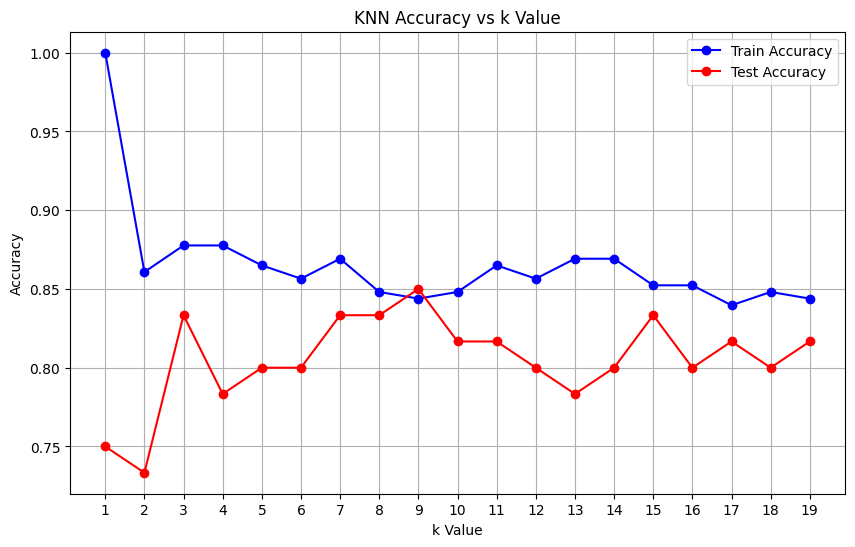

Optimal k-value: 9
Final Test Accuracy: 0.8500


In [ ]:
# 2. Find optimal k
k_values = range(1, 20)  # Test k from 1 to 19
train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled, y_test))

# 3. Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_acc, 'bo-', label='Train Accuracy')
plt.plot(k_values, test_acc, 'ro-', label='Test Accuracy')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k Value')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

# 4. Select best k (max test accuracy)
optimal_k = k_values[test_acc.index(max(test_acc))]
print(f"Optimal k-value: {optimal_k}")

# 5. Train final model
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)
print(f"Final Test Accuracy: {final_knn.score(X_test_scaled, y_test):.4f}")

Best Parameters: {'knn__n_neighbors': 9, 'knn__p': 2, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.8647
Final Test Accuracy: 0.8500


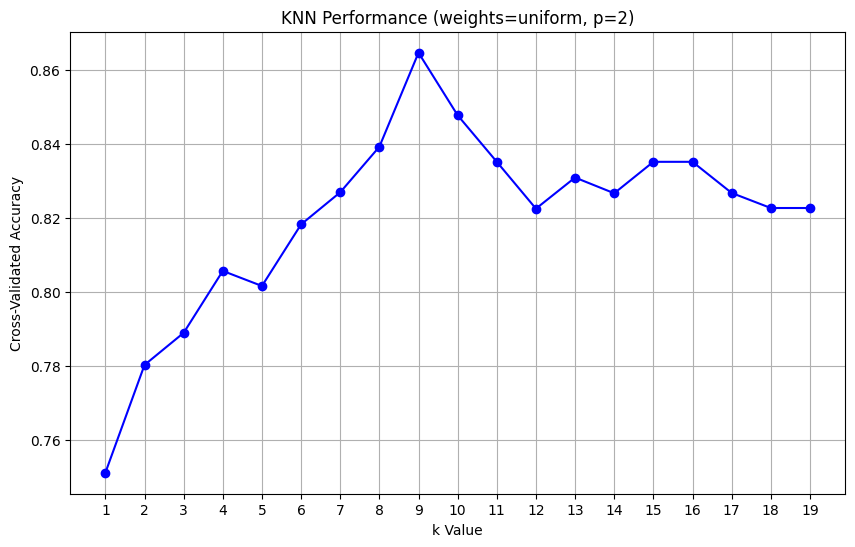

In [ ]:
# 1. Create preprocessing + modeling pipeline
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),  # Scaling first
    ('knn', KNeighborsClassifier())  # KNN second
])

# 2. Define hyperparameter grid
param_grid = {
    'knn__n_neighbors': np.arange(1, 20),  # k values
    'knn__weights': ['uniform', 'distance'],  # Weighting schemes
    'knn__p': [1, 2]  # 1=Manhattan, 2=Euclidean distance
}

# 3. Grid Search with 5-fold CV
knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1  # Use all CPU cores
)
knn_grid.fit(X_train, y_train)

# 4. Results analysis
print("Best Parameters:", knn_grid.best_params_)
print("Best CV Accuracy: {:.4f}".format(knn_grid.best_score_))

# 5. Final evaluation
best_knn = knn_grid.best_estimator_
test_acc = best_knn.score(X_test, y_test)
print("Final Test Accuracy: {:.4f}".format(test_acc))

# 6. Plot performance across k values (with best weight/distance)
results = pd.DataFrame(knn_grid.cv_results_)
best_weight = knn_grid.best_params_['knn__weights']
best_p = knn_grid.best_params_['knn__p']

filtered = results[
    (results['param_knn__weights'] == best_weight) &
    (results['param_knn__p'] == best_p)
]

plt.figure(figsize=(10, 6))
plt.plot(filtered['param_knn__n_neighbors'], filtered['mean_test_score'], 'bo-')
plt.xlabel('k Value')
plt.ylabel('Cross-Validated Accuracy')
plt.title(f'KNN Performance (weights={best_weight}, p={best_p})')
plt.xticks(np.arange(1, 20))
plt.grid(True)
plt.show()

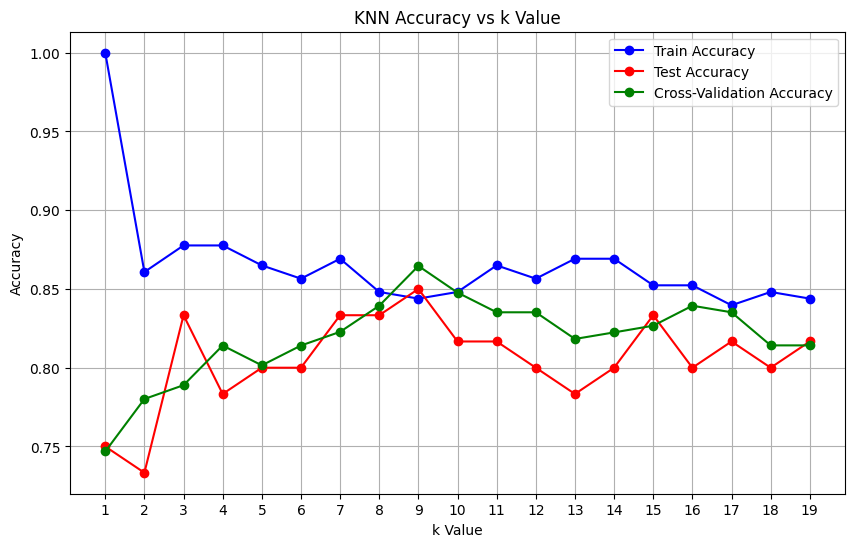

Optimal k-value based on CV: 9
Final Test Accuracy: 0.8500


In [ ]:
# 2. Find optimal k with cross-validation
k_values = range(1, 20)  # Test k from 1 to 19
train_acc = []
test_acc = []
cv_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled, y_test))

    # Cross-validation score (on training set only)
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_acc.append(cv_scores.mean())

# 3. Plot results
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_acc, 'bo-', label='Train Accuracy')
plt.plot(k_values, test_acc, 'ro-', label='Test Accuracy')
plt.plot(k_values, cv_acc, 'go-', label='Cross-Validation Accuracy')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k Value')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

# 4. Select best k (based on cross-validation)
optimal_k = k_values[cv_acc.index(max(cv_acc))]
print(f"Optimal k-value based on CV: {optimal_k}")

# 5. Train final model
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)
print(f"Final Test Accuracy: {final_knn.score(X_test_scaled, y_test):.4f}")


As shown in the plot:

- The **cross-validation accuracy** (green line) helps us identify the optimal value of *k*.
- The **training accuracy** (blue) and **test accuracy** (red) curves become more stable compared to the previous plot.
- The best performance is achieved at **k = 9**, where the cross-validation accuracy is highest.

Optimal k-value based on CV: 9  
Best Cross-Validation Accuracy: 0.8647  
Final Test Accuracy: 0.8500



---



## Decision Tree Evaluation

We evaluate the Decision Tree classifier by tuning two critical hyperparameters: `max_depth` and `min_samples_split`. A grid search is performed over a range of values for both parameters using 5-fold cross-validation to find the combination that yields the best model performance.

The plots below show:

- **Top Plot**: Cross-validation accuracy across different combinations of `max_depth` and `min_samples_split`.  
- **Bottom Plot**: Training accuracy for the same combinations, used to diagnose overfitting.


Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.7719
Final Training Accuracy: 0.8608
Final Test Accuracy: 0.8000


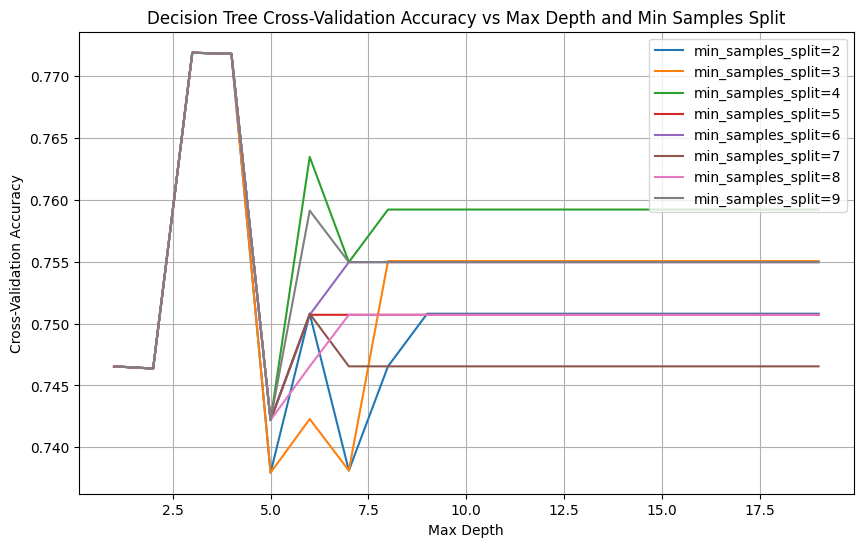

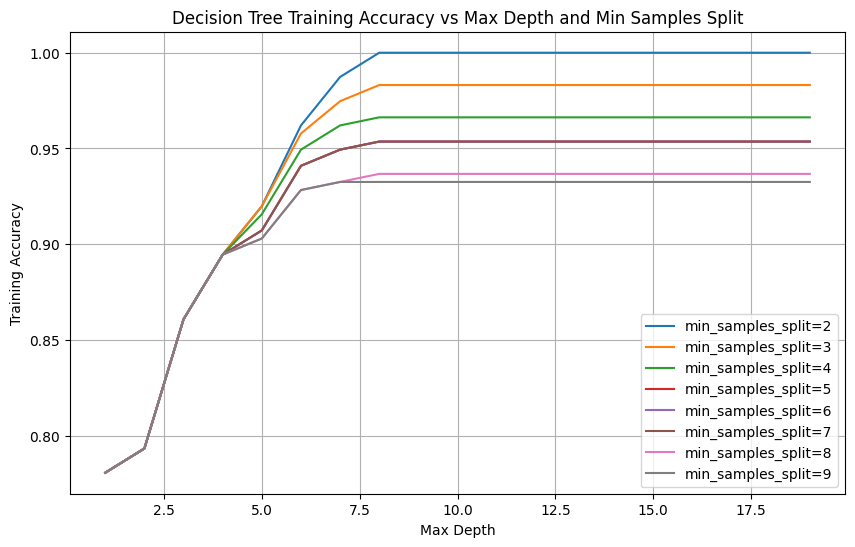

In [ ]:
# 3. Hyperparameter tuning: grid search over max_depth and min_samples_split
max_depth_values = range(1, 20)
min_samples_split_values = range(2, 10)
best_score = 0
best_params = {}
results = []

for depth in max_depth_values:
    for min_split in min_samples_split_values:
        tree = DecisionTreeClassifier(max_depth=depth, min_samples_split=min_split, random_state=42)

        # Get cross-validation score
        scores = cross_val_score(tree, X_train, y_train, cv=5)
        mean_score = scores.mean()

        # Calculate training accuracy
        tree.fit(X_train, y_train)
        train_accuracy = tree.score(X_train, y_train)

        results.append((depth, min_split, mean_score, train_accuracy))

        if mean_score > best_score:
            best_score = mean_score
            best_params = {'max_depth': depth, 'min_samples_split': min_split}

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")

# 4. Train final model
final_tree = DecisionTreeClassifier(**best_params, random_state=42)
final_tree.fit(X_train, y_train)

# Calculate and print final training accuracy
final_train_accuracy = final_tree.score(X_train, y_train)
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")

# 5. Test set evaluation
test_accuracy = final_tree.score(X_test, y_test)
print(f"Final Test Accuracy: {test_accuracy:.4f}")

# 6. Visualization
depths, min_splits, cv_scores, train_scores = zip(*results)
depths = np.array(depths)
min_splits = np.array(min_splits)
cv_scores = np.array(cv_scores)
train_scores = np.array(train_scores)

# Plot cross-validation accuracy
plt.figure(figsize=(10, 6))
for min_split in np.unique(min_splits):
    idxs = min_splits == min_split
    plt.plot(depths[idxs], cv_scores[idxs], label=f"min_samples_split={min_split}")

plt.xlabel('Max Depth')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Decision Tree Cross-Validation Accuracy vs Max Depth and Min Samples Split')
plt.legend()
plt.grid(True)
plt.show()

# Plot training accuracy
plt.figure(figsize=(10, 6))
for min_split in np.unique(min_splits):
    idxs = min_splits == min_split
    plt.plot(depths[idxs], train_scores[idxs], label=f"min_samples_split={min_split}")

plt.xlabel('Max Depth')
plt.ylabel('Training Accuracy')
plt.title('Decision Tree Training Accuracy vs Max Depth and Min Samples Split')
plt.legend()
plt.grid(True)
plt.show()

as shown, smaller values of `min_samples_split` and deeper trees tend to overfit, achieving very high training accuracy but worse generalization. Cross-validation helps us detect this and identify more robust configurations.

After evaluating all combinations, the best parameters found were:

- `max_depth = 3`  
- `min_samples_split = 2`

With this configuration:

- **Best Cross-Validation Accuracy**: `0.7719`  
- **Final Training Accuracy**: `0.8608`  
- **Final Test Accuracy**: `0.8000`

These results indicate a good trade-off between model complexity and generalization, with acceptable performance on unseen data.



---



## Random Forest Evaluation

To improve performance beyond a single decision tree, we employ a **Random Forest** classifier — an ensemble method that builds multiple trees and averages their predictions to reduce overfitting and improve generalization.

We perform a **grid search** over the following hyperparameters using 5-fold cross-validation:

- `n_estimators`: [40, 50, 60, 70, 80, 100]  
- `max_depth`: [None, 10, 20, 30]  
- `min_samples_split`: [2, 5, 10]  
- `min_samples_leaf`: [1, 2, 4]  
- `max_features`: ['sqrt', 'log2', None]


In [ ]:
# Define hyperparameters to search over
param_grid = {
    'n_estimators': [40, 510, 60 , 70 , 80 , 100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print(f"Best Hyperparameters: {grid_search.best_params_}")

# Evaluate on test data
best_rf = grid_search.best_estimator_
test_accuracy = best_rf.score(X_test, y_test)
print(f"Test Accuracy with Best Parameters: {test_accuracy:.4f}")

# Train Accuracy
train_accuracy = best_rf.score(X_train, y_train)
print(f"Train Accuracy with Best Parameters: {train_accuracy:.4f}")


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 70}
Test Accuracy with Best Parameters: 0.8333
Train Accuracy with Best Parameters: 0.9072


This results in **648 model configurations**, each evaluated with cross-validation for robust performance estimation.

✅ **Best Hyperparameters Identified**:
- `n_estimators = 70`  
- `max_depth = None`  
- `min_samples_split = 2`  
- `min_samples_leaf = 4`  
- `max_features = 'sqrt'`

📊 **Performance**:
- **Training Accuracy**: `0.9072`  
- **Test Accuracy**: `0.8333`

These results show that the Random Forest model generalizes better than a single Decision Tree, achieving higher test accuracy while maintaining a reasonable gap from the training accuracy, indicating reduced overfitting.

## Support Vector Machine (SVM)

To harness the power of SVMs for high-dimensional data, we employ a **Support Vector Classifier (SVC)** and optimize its performance using **RandomizedSearchCV** over a broad range of hyperparameters. This method is more efficient than exhaustive grid search, especially for large search spaces.

🔧 **Search Space**:
- `C`: [0.001, 0.01, 0.1, 1, 10, 100, 1000]  
- `kernel`: ['linear', 'rbf', 'poly', 'sigmoid']  
- `gamma`: ['scale', 'auto', 0.1, 1]  
- `degree`: [2, 3, 4] *(used only for `'poly'` kernel)*  
- `coef0`: [0.0, 0.1, 1.0] *(used for `'poly'` and `'sigmoid'`)*  
- `shrinking`: [True, False]  
- `class_weight`: [None, 'balanced']  
- `max_iter`: [1000, 5000, -1]  
- `tol`: [1e-3, 1e-4, 1e-5]  

We randomly sampled **50 configurations** with 5-fold cross-validation.


In [ ]:
# Create a parameter grid to sample from
param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1],
    'degree': [2, 3, 4],  # Only for 'poly' kernel
    'coef0': [0.0, 0.1, 1.0],  # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 5000, -1],
    'tol': [1e-3, 1e-4, 1e-5]
}

# Perform RandomizedSearchCV for the best combination of parameters
random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=50, cv=5, random_state=42)
random_search.fit(X_train_scaled, y_train)

# Print the best parameters found by RandomizedSearchCV
print("Best Parameters:", random_search.best_params_)

# Train the best model with the best parameters
best_svm = random_search.best_estimator_

# Evaluate on the test set
y_pred = best_svm.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Print the training accuracy
train_accuracy = best_svm.score(X_train_scaled, y_train)
print("Training Accuracy:", train_accuracy)

# Visualization of the RandomizedSearchCV results: Only plot 'C' vs mean test score

# Extract the 'C' values and corresponding mean test scores
results = random_search.cv_results_
C_values = results['param_C'].data  # Getting the 'C' values tried in the search
mean_test_scores = results['mean_test_score']  # Mean test scores for each combination update this to use baisian search

Best Parameters: {'tol': 0.0001, 'shrinking': True, 'max_iter': 1000, 'kernel': 'linear', 'gamma': 1, 'degree': 2, 'coef0': 0.1, 'class_weight': None, 'C': 0.01}
Test Accuracy: 0.8333333333333334
Training Accuracy: 0.8565400843881856


✅ **Best Hyperparameters Found**:
- `C = 0.01`  
- `kernel = 'linear'`  
- `gamma = 1`  
- `degree = 2`  
- `coef0 = 0.1`  
- `shrinking = True`  
- `class_weight = None`  
- `max_iter = 1000`  
- `tol = 1e-4`

📊 **Performance**:
- **Training Accuracy**: `0.8565`  
- **Test Accuracy**: `0.8333`

The model performs well and maintains good generalization, thanks in part to feature scaling. The relatively small value of `C` and choice of `linear` kernel likely help control overfitting in this context.



---





##  Naive Bayes Hybrid Model

We implemented a **hybrid Naive Bayes model** that separates and processes features based on their type:

- **Continuous Features** → modeled using **GaussianNB**
- **Discrete/Categorical Features** → modeled using **CategoricalNB**

Each model was trained separately, and their output probabilities were combined (via element-wise multiplication and normalization) to make the final prediction.

---

###  Feature Preprocessing

- **Continuous Features**: age, trestbps, chol, thalach, oldpeak  
  → Standardized using `StandardScaler`.
  
- **Discrete Features**: all remaining features  
  → Encoded using `LabelEncoder`.

---

###  Model Training & Evaluation

Both classifiers were trained on their respective feature subsets. The combined probabilities were used for final predictions on the test set.


In [ ]:

# =============================================
# Feature Separation and Preprocessing
# =============================================

# Identify continuous and discrete features
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']  # Replace with your features
discrete_features = [col for col in X.columns if col not in continuous_features]

# Create copies to avoid modifying original data
X_cont = X[continuous_features].copy()
X_disc = X[discrete_features].copy()

# Encode discrete features (using copies)
X_disc_encoded = X_disc.copy()
for col in discrete_features:
    le = LabelEncoder()
    X_disc_encoded[col] = le.fit_transform(X_disc[col])

# Standardize continuous features
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

# =============================================
# Train-Test Split (Preserving Original y)
# =============================================

# Split using temporary variables for y
(X_train_cont, X_test_cont,
 X_train_disc, X_test_disc,
 y_train_temp, y_test_temp) = train_test_split(
    X_cont_scaled,
    X_disc_encoded,
    y,  # Original y used as input (not modified)
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =============================================
# Model Training and Evaluation
# =============================================

# Encode discrete features for train/test
X_train_disc_encoded = X_train_disc.copy()
X_test_disc_encoded = X_test_disc.copy()

for col in discrete_features:
    le = LabelEncoder()
    X_train_disc_encoded[col] = le.fit_transform(X_train_disc[col])
    X_test_disc_encoded[col] = le.transform(X_test_disc[col])

# Train models using temporary y variables
gnb = GaussianNB().fit(X_train_cont, y_train_temp)
cnb = CategoricalNB().fit(X_train_disc_encoded, y_train_temp)

# Predict probabilities
proba_gnb = gnb.predict_proba(X_test_cont)
proba_cnb = cnb.predict_proba(X_test_disc_encoded)

# Combine and normalize probabilities
combined_proba = proba_gnb * proba_cnb
combined_proba /= combined_proba.sum(axis=1, keepdims=True)

# Final predictions
y_pred = np.argmax(combined_proba, axis=1)

# =============================================
# Evaluation (Using Temporary y Variables)
# =============================================

print("\nModel Evaluation:")
print("----------------")
print(f"Test Accuracy: {accuracy_score(y_test_temp, y_pred):.4f}")
print(f"Train Accuracy (GaussianNB): {accuracy_score(y_train_temp, gnb.predict(X_train_cont)):.4f}")
print(f"Train Accuracy (CategoricalNB): {accuracy_score(y_train_temp, cnb.predict(X_train_disc_encoded)):.4f}")
print("\nClassification Report:\n", classification_report(y_test_temp, y_pred))

# =============================================
# Cross-Validation (Using Full Original Data)
# =============================================

# Predict on full dataset
proba_gnb_full = gnb.predict_proba(X_cont_scaled)
proba_cnb_full = cnb.predict_proba(X_disc_encoded)

# Combine probabilities
combined_proba_full = proba_gnb_full * proba_cnb_full
combined_proba_full /= combined_proba_full.sum(axis=1, keepdims=True)

# Predictions
y_pred_full = np.argmax(combined_proba_full, axis=1)

print("\nCross-Validation Results:")
print("-----------------------")
print(f"Full Dataset Accuracy: {accuracy_score(y, y_pred_full):.4f}")


Model Evaluation:
----------------
Test Accuracy: 0.8333
Train Accuracy (GaussianNB): 0.7300
Train Accuracy (CategoricalNB): 0.8354

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


Cross-Validation Results:
-----------------------
Full Dataset Accuracy: 0.8451




---


*Performance on Test Set:**

- ✅ **Test Accuracy**: 83.33%
- 📈 **Train Accuracy (GaussianNB)**: 73.00%
- 📉 **Train Accuracy (CategoricalNB)**: 83.54%

**Classification Report:**

| Class | Precision | Recall | F1-score | Support |
|-------|-----------|--------|----------|---------|
|   0   |   0.82    |  0.88  |   0.85   |   32    |
|   1   |   0.85    |  0.79  |   0.81   |   28    |

- **Macro Avg F1-score**: 0.83  
- **Weighted Avg F1-score**: 0.83

---

### Cross-Validation on Full Dataset

The hybrid model was also evaluated on the full dataset (without train-test split):

- ✅ **Full Dataset Accuracy**: 84.51%

---

###  Conclusion

The hybrid Naive Bayes model demonstrated strong accuracy and balance across precision and recall. By leveraging the strengths of both Gaussian and Categorical approaches, it effectively captured mixed-feature patterns present
in the heart disease dataset.

---

##Logistic Regression

Training set: 237 samples
Test set: 60 samples
Starting grid search with 32 parameter combinations...
Fitting 5 folds for each of 56 candidates, totalling 280 fits

Grid search complete!
Best score: 0.8396
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.0001}

===== Model Evaluation =====
Training accuracy: 0.8608
Test accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85        30
           1       0.92      0.73      0.81        30

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60



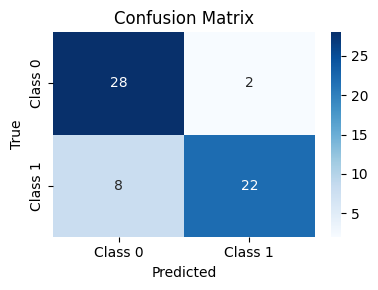

<Figure size 1200x800 with 0 Axes>

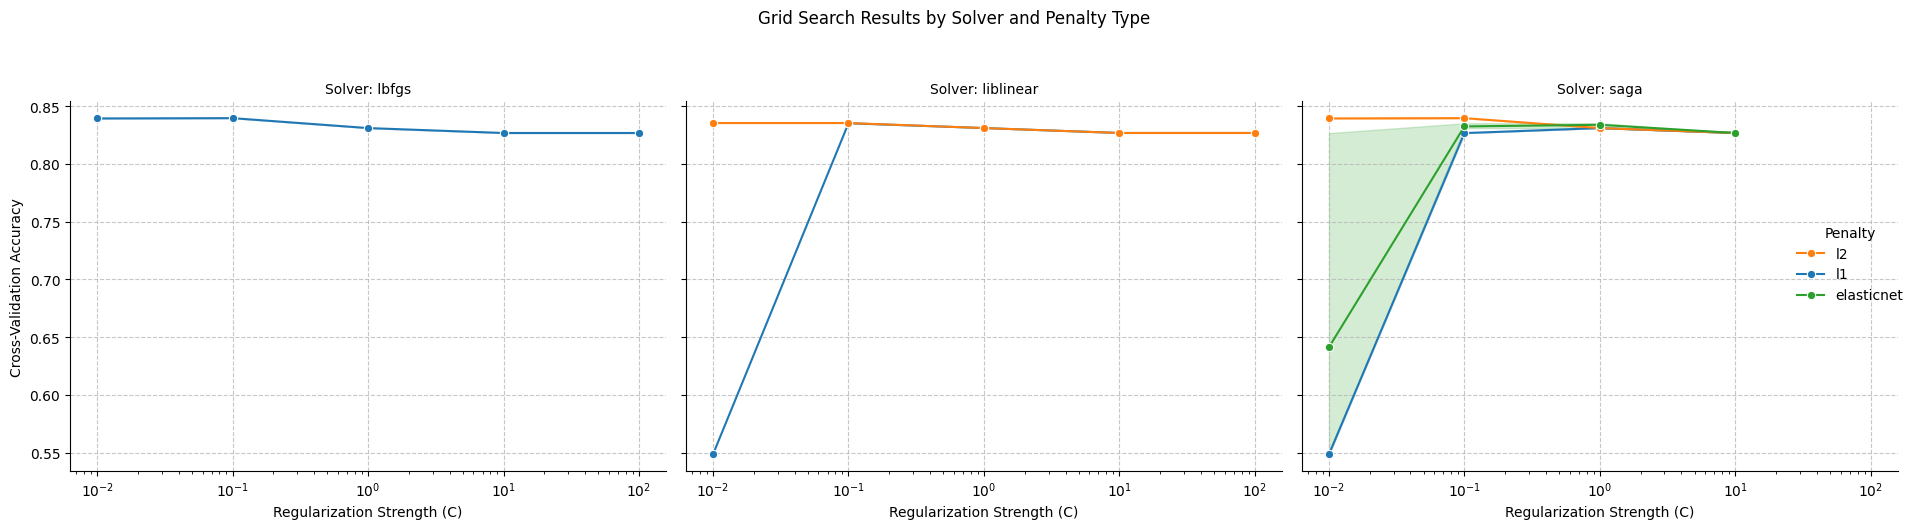

<Figure size 1000x600 with 0 Axes>

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)

def create_parameter_grid():
    # Create compatible parameter combinations
    param_combinations = [
        # lbfgs solver - only supports l2 penalty
        {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100],
         'tol': [1e-4, 1e-5]},

        # liblinear solver - supports l1 and l2 penalties
        {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10, 100],
         'tol': [1e-4]},

        # saga solver - supports l1, l2, and elasticnet penalties
        {'solver': ['saga'], 'penalty': ['l1', 'l2', 'elasticnet'], 'C': [0.01, 0.1, 1, 10],
         'tol': [1e-4],
         'l1_ratio': [0.2, 0.5, 0.8]}  # Only used with elasticnet
    ]

    return param_combinations

def perform_grid_search(X_train, y_train, scoring='accuracy', cv=5, n_jobs=-1):
    param_grid = create_parameter_grid()

    # Create logistic regression base model
    model = LogisticRegression(random_state=42, max_iter=1000)

    # Initialize and run grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        verbose=1,
        return_train_score=True
    )

    print("Starting grid search with {} parameter combinations...".format(
        sum(len(dict_['C']) * len(dict_['penalty']) * len(dict_['tol'])
            for dict_ in param_grid)))

    grid_search.fit(X_train, y_train)

    print("\nGrid search complete!")
    print(f"Best score: {grid_search.best_score_:.4f}")
    print(f"Best parameters: {grid_search.best_params_}")

    return grid_search

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate probabilities if available (for ROC curve later)
    try:
        y_test_proba = model.predict_proba(X_test)
    except:
        y_test_proba = None

    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Print results
    print("\n===== Model Evaluation =====")
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    results = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba
    }

    return results

def plot_confusion_matrix(y_test, y_pred, class_names=None):
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test, y_pred)

    # If class names aren't provided, use default numbering
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(np.unique(y_test)))]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def plot_grid_search_results(grid_search_results):
    # Convert results to DataFrame
    results = pd.DataFrame(grid_search_results.cv_results_)

    # Visualization 1: C vs Accuracy by solver and penalty
    plt.figure(figsize=(12, 8))

    # Reshape data for better plotting
    plot_data = []

    for i, row in results.iterrows():
        # Extract parameters
        if 'param_penalty' not in row or pd.isna(row['param_penalty']):
            continue

        penalty = row['param_penalty']
        solver = row['param_solver'] if 'param_solver' in row else 'unknown'
        C = row['param_C'] if 'param_C' in row else np.nan
        score = row['mean_test_score']

        if not pd.isna(C) and not pd.isna(score):
            plot_data.append({
                'C': C,
                'accuracy': score,
                'solver': solver,
                'penalty': penalty
            })

    if plot_data:
        plot_df = pd.DataFrame(plot_data)

        # Create plot with separate facets by solver
        g = sns.FacetGrid(plot_df, col="solver", height=5, aspect=1.2, sharey=True)
        g.map_dataframe(sns.lineplot, x="C", y="accuracy", hue="penalty", marker="o")
        g.set_axis_labels("Regularization Strength (C)", "Cross-Validation Accuracy")
        g.set_titles("Solver: {col_name}")
        g.add_legend(title="Penalty")

        # Make x-axis logarithmic
        for ax in g.axes.flat:
            ax.set_xscale('log')
            ax.grid(True, linestyle='--', alpha=0.7)

        plt.suptitle('Grid Search Results by Solver and Penalty Type', y=1.05)
        plt.tight_layout()
        plt.show()

    # Visualization 2: Top 10 models
    plt.figure(figsize=(10, 6))

    # Sort by mean test score and select top 10
    top_results = results.sort_values('mean_test_score', ascending=False).head(10)

    # Create parameter combinations as string for x-axis labels
    param_labels = []
    for _, row in top_results.iterrows():
        params = []
        for p in ['penalty', 'solver', 'C']:
            param_name = f'param_{p}'
            if param_name in row and not pd.isna(row[param_name]):
                params.append(f"{p}={row[param_name]}")
        param_labels.append('\n'.join(params))


# === Main Execution ===
# This code assumes X_train_scaled, X_test_scaled, y_train, y_test are already defined

def run_logistic_regression(X_train_scaled, X_test_scaled, y_train, y_test, class_names=None):
    print(f"Training set: {X_train_scaled.shape[0]} samples")
    print(f"Test set: {X_test_scaled.shape[0]} samples")


    grid_search_result = perform_grid_search(X_train_scaled, y_train)
    best_model = grid_search_result.best_estimator_
    eval_results = evaluate_model(best_model, X_train_scaled, y_train, X_test_scaled, y_test)
    plot_confusion_matrix(y_test, eval_results['y_test_pred'], class_names)
    plot_grid_search_results(grid_search_result)

    # Return results for further use if needed
    return {
        'best_model': best_model,
        'grid_search': grid_search_result,
        'evaluation': eval_results
    }


class_names = ['Class 0', 'Class 1']  # Replace with your actual class names
results = run_logistic_regression(X_train_scaled, X_test_scaled, y_train, y_test, class_names)

### **Summary of Results**

The logistic regression model was trained on 237 samples and tested on 60 samples with the following results:

- **Best Model Parameters:**
  - Solver: lbfgs
  - Penalty: l2
  - C: 0.1
  - Tolerance: 0.0001
  
- **Performance Metrics:**
  - Cross-validation accuracy: 0.8396
  - Training accuracy: 0.8608
  - Test accuracy: 0.8333

### **Classification Report**

|              | Precision | Recall | F1-Score | Support |
|--------------|-----------|--------|----------|---------|
| Class 0      | 0.78      | 0.93   | 0.85     | 30      |
| Class 1      | 0.92      | 0.73   | 0.81     | 30      |
| **Accuracy** |           |        | 0.83     | 60      |
| **Macro Avg**| 0.85      | 0.83   | 0.83     | 60      |
| **Weighted Avg** | 0.85  | 0.83   | 0.83     | 60      |

### **Analysis of Grid Search Results**

The grid search explored multiple combinations of hyperparameters:
- Three solvers: lbfgs, liblinear, and saga
- Various penalty types (l1, l2, elasticnet) compatible with each solver
- Regularization strength (C) values ranging from 0.01 to 100
- Tolerance values and l1_ratio (for elasticnet)

### **Performance by Solver**

Based on the visualization:

1. **LBFGS Solver (L2 penalty only)**:
   - Shows consistent performance across C values
   - Best performance at C=0.1
   - Relatively stable accuracy (~0.84) as C changes

2. **Liblinear Solver (L1 and L2 penalties)**:
   - L2 penalty performs better than L1
   - L1 penalty shows poor performance at low C values but improves significantly as C increases

3. **Saga Solver (L1, L2, and Elasticnet penalties)**:
   - All penalties converge to similar performance at C=0.1
   - Poor performance at low C values
   - L2 penalty slightly outperforms others at optimal C values

### **Interpretation**

1. **Regularization Effect**: The optimal C value of 0.1 suggests that moderate regularization is beneficial for this dataset, balancing between overfitting and underfitting.

2. **Class Imbalance Analysis**:
   - Class 0: High recall (0.93) but lower precision (0.78) suggests the model is correctly identifying most Class 0 instances but sometimes misclassifies Class 1 as Class 0.
   - Class 1: High precision (0.92) but lower recall (0.73) indicates the model is very confident when predicting Class 1, but misses some actual Class 1 instances.

3. **Model Selection**: The lbfgs solver with L2 regularization provided the best balance of performance and stability across different hyperparameter settings.

---

##  Boosting Models for Heart Disease Prediction

We applied three boosting techniques to predict heart disease:

1. **AdaBoostClassifier**
2. **GradientBoostingClassifier**
3. **XGBoostClassifier**

All models underwent **GridSearchCV** hyperparameter tuning and were evaluated on both training and test sets.


In [ ]:
def train_adaboost_with_gridsearch(X_train, y_train, random_state=42):
    base = DecisionTreeClassifier(random_state=random_state)
    model = AdaBoostClassifier(estimator=base, random_state=random_state)

    param_grid = {
        'n_estimators': [50, 100, 200 , 300 , 400],
        'learning_rate': [0.001 , 0.01, 0.1, 1.0],
        'estimator__max_depth': [1, 2, 3]
    }

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    print("✅ Best Parameters:", grid_search.best_params_)
    return grid_search.best_estimator_, grid_search

def evaluate_adaboost(model, X_train, y_train, X_test, y_test, class_names=None):
    """
    Evaluate AdaBoost model and plot confusion matrix and feature importances.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print("\n===== Model Evaluation =====")
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    if class_names is None:
        class_names = [f"Class {i}" for i in np.unique(y_test)]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        top_n = min(10, len(importances))
        top_indices = indices[:top_n]

        plt.figure(figsize=(10, 6))
        plt.bar(range(top_n), importances[top_indices], align="center")
        plt.xticks(range(top_n), [f"Feature {i}" for i in top_indices], rotation=45, ha='right')
        plt.title("Top Feature Importances")
        plt.xlabel("Features")
        plt.ylabel("Importance")
        plt.tight_layout()
        plt.show()

    return {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'y_test_pred': y_test_pred
    }

def plot_grid_search_results(grid_search):
    """
    Plot the effect of hyperparameters on accuracy.
    """
    results = pd.DataFrame(grid_search.cv_results_)
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=results,
        x='param_n_estimators',
        y='mean_test_score',
        hue='param_estimator__max_depth',
        style='param_learning_rate',
        markers=True,
        dashes=False
    )
    plt.title("Grid Search Results - AdaBoost")
    plt.xlabel("Number of Estimators")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="Max Depth / Learning Rate", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True)
    plt.show()


Fitting 5 folds for each of 60 candidates, totalling 300 fits
✅ Best Parameters: {'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 300}

===== Model Evaluation =====
Training accuracy: 0.8481
Test accuracy: 0.8167

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.93      0.84        30
           1       0.91      0.70      0.79        30

    accuracy                           0.82        60
   macro avg       0.83      0.82      0.81        60
weighted avg       0.83      0.82      0.81        60



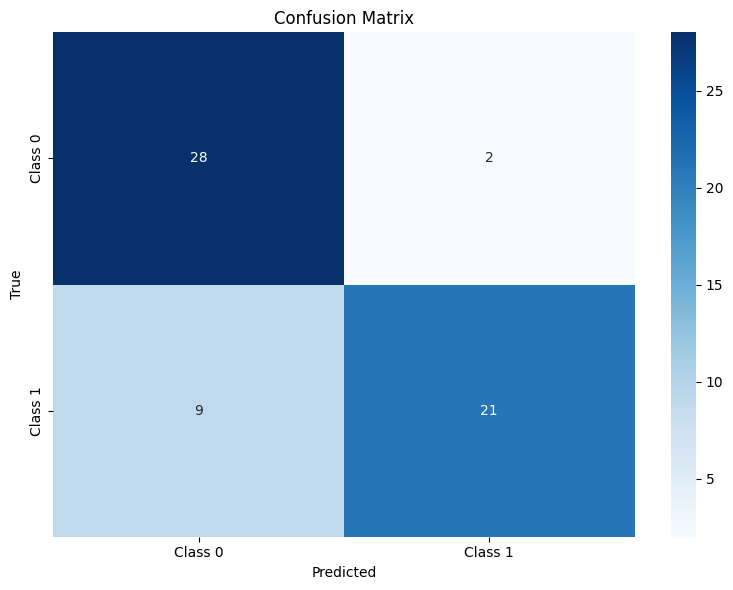

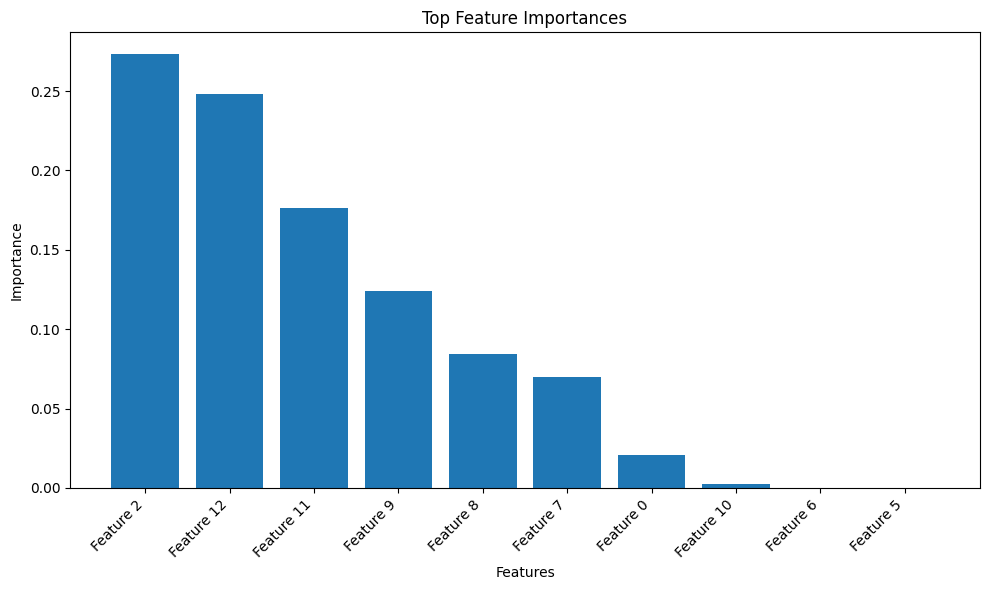

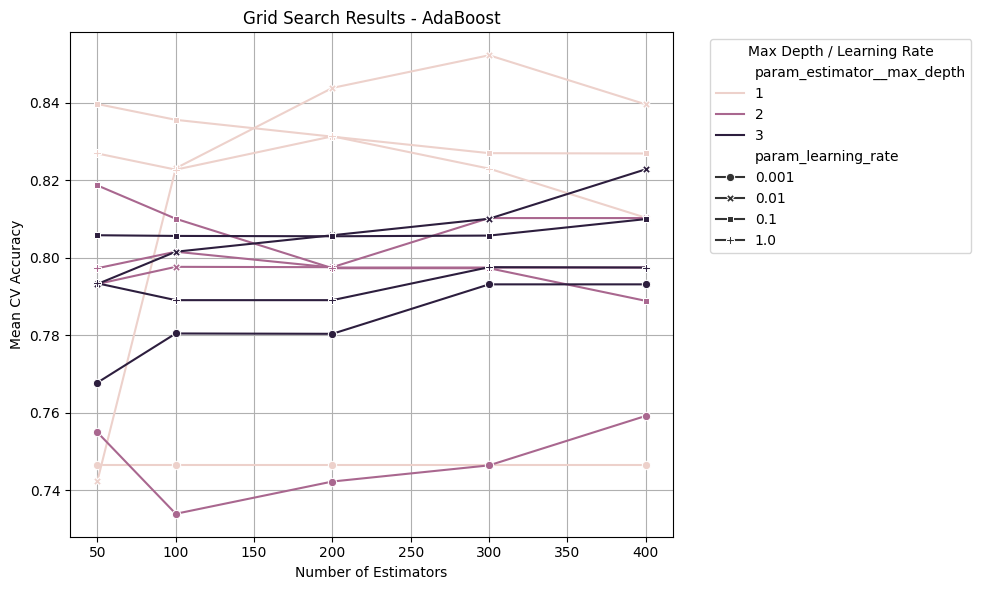

In [ ]:
# Step 1: Train with hyperparameter tuning
best_model, grid_search = train_adaboost_with_gridsearch(X_train_scaled, y_train)

# Step 2: Evaluate on test data
evaluate_adaboost(best_model, X_train_scaled, y_train, X_test_scaled, y_test)

# Step 3: Visualize GridSearch results
plot_grid_search_results(grid_search)


*italicized text*#Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

def train_gradient_boosting(X_train, y_train):
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.1, 0.05],
        'max_depth': [2, 3],
        'subsample': [0.8, 1.0]
    }

    gb = GradientBoostingClassifier(random_state=42)

    grid = GridSearchCV(gb, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    print("Best Gradient Boosting Parameters:", grid.best_params_)
    print("Best Gradient Boosting Score:", grid.best_score_)

    return grid.best_estimator_, grid


In [ ]:
from xgboost import XGBClassifier

def train_xgboost(X_train, y_train):
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.1, 0.05],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

    grid = GridSearchCV(xgb, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    print("Best XGBoost Parameters:", grid.best_params_)
    print("Best XGBoost Score:", grid.best_score_)

    return grid.best_estimator_, grid


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


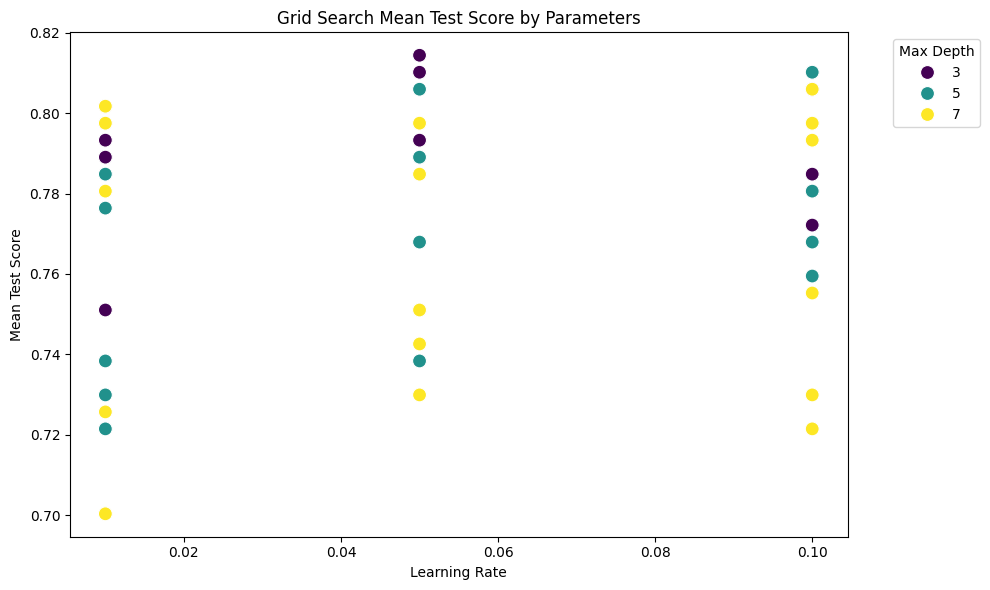


===== Model Evaluation =====
Training accuracy: 0.9873
Test accuracy: 0.7333

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.77      0.74        30
           1       0.75      0.70      0.72        30

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.73      0.73      0.73        60



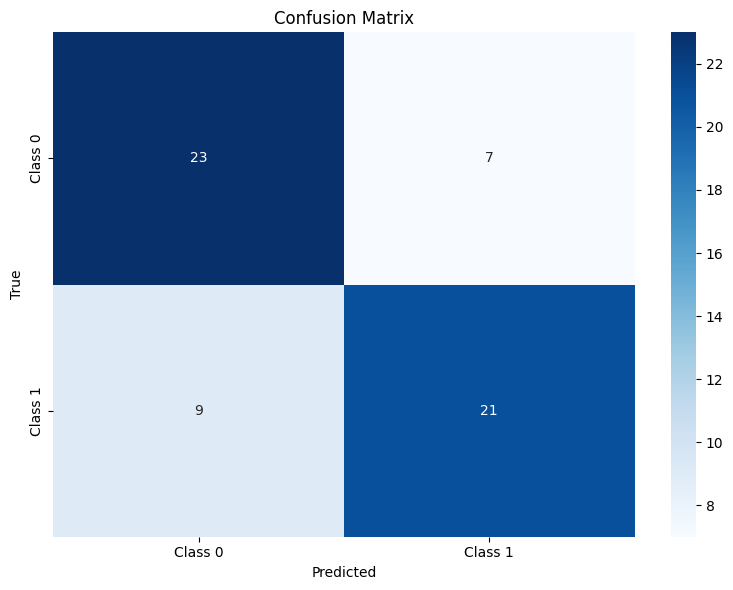

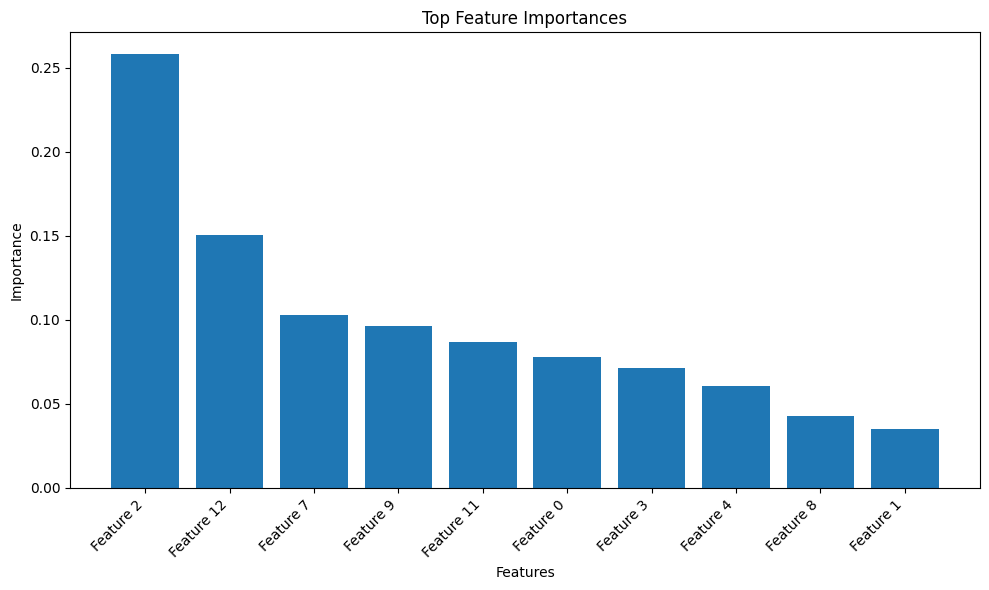

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


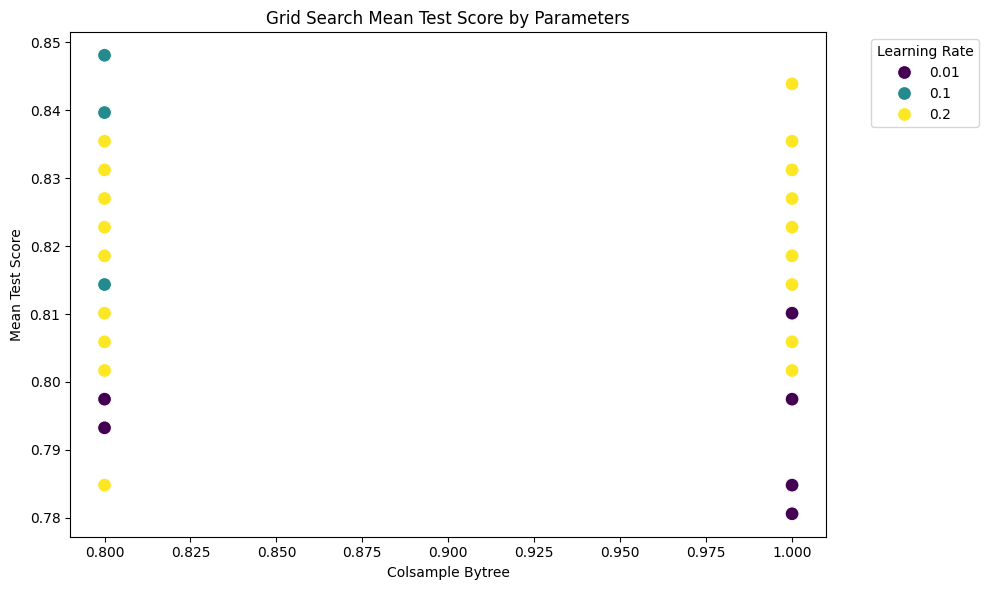


===== Model Evaluation =====
Training accuracy: 0.9873
Test accuracy: 0.7833

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78        30
           1       0.77      0.80      0.79        30

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



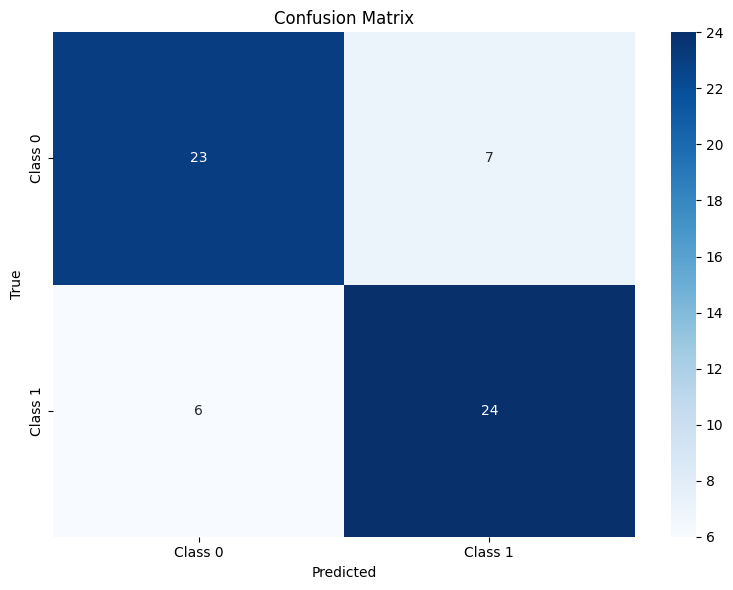

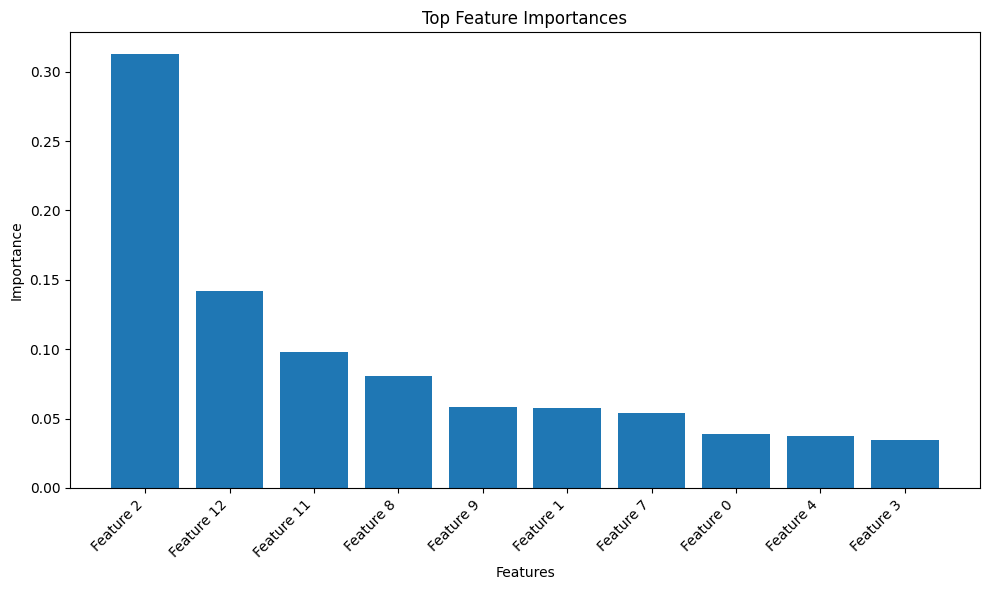

{'train_acc': 0.9873417721518988,
 'test_acc': 0.7833333333333333,
 'y_test_pred': array([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
        0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0])}

In [ ]:
# Function to plot grid search results
def plot_grid_search_results(grid_search):
    results = pd.DataFrame(grid_search.cv_results_)

    # Automatically detect which param columns to use
    param_cols = [col for col in results.columns if col.startswith('param_')]

    if len(param_cols) < 2:
        print("Need at least two varying parameters to create this plot.")
        print(f"Found parameters: {param_cols}")
        return

    param_x = param_cols[0]
    param_hue = param_cols[1]

    # Plot mean test score across two parameters
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=results,
        x=param_x,
        y="mean_test_score",
        hue=param_hue,
        palette="viridis",
        s=100
    )
    plt.xlabel(param_x.replace("param_", "").replace("_", " ").title())
    plt.ylabel("Mean Test Score")
    plt.title("Grid Search Mean Test Score by Parameters")
    plt.legend(title=param_hue.replace("param_", "").replace("_", " ").title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



# 2. Gradient Boosting Hyperparameter Tuning
def tune_gradient_boosting(X_train, y_train):
    param_grid_gb = {
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }

    gb_model = GradientBoostingClassifier(random_state=42)

    grid_search_gb = GridSearchCV(estimator=gb_model, param_grid=param_grid_gb, cv=3, n_jobs=-1, scoring='accuracy', verbose=1)
    grid_search_gb.fit(X_train, y_train)

    print(f"Best parameters for Gradient Boosting: {grid_search_gb.best_params_}")

    return grid_search_gb.best_estimator_, grid_search_gb

# 3. XGBoost Hyperparameter Tuning
def tune_xgboost(X_train, y_train):
    param_grid_xgb = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [50, 100, 150],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    xgb_model = XGBClassifier(random_state=42)

    grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=3, n_jobs=-1, scoring='accuracy', verbose=1)
    grid_search_xgb.fit(X_train, y_train)

    print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")

    return grid_search_xgb.best_estimator_, grid_search_xgb

# Tune Gradient Boosting
gb_model_tuned, gb_grid = tune_gradient_boosting(X_train_scaled, y_train)
print(f"Best parameters for Gradient Boosting: {gb_grid.best_params_}")

# Plot Gradient Boosting grid search results
plot_grid_search_results(gb_grid)

# Evaluate Gradient Boosting (using your evaluation function)
evaluate_adaboost(gb_model_tuned, X_train_scaled, y_train, X_test_scaled, y_test)

# Tune XGBoost
xgb_model_tuned, xgb_grid = tune_xgboost(X_train_scaled, y_train)
print(f"Best parameters for XGBoost: {xgb_grid.best_params_}")

# Plot XGBoost grid search results
plot_grid_search_results(xgb_grid)

# Evaluate XGBoost (using your evaluation function)
evaluate_adaboost(xgb_model_tuned, X_train_scaled, y_train, X_test_scaled, y_test)


### ✅ Key Observations:
- **AdaBoost** achieved the **highest test accuracy** and maintained a good balance between precision and recall.
- Both **Gradient Boosting** and **XGBoost** had very high training accuracy but lower test accuracy, indicating **overfitting**.
- Despite being simpler, AdaBoost generalized better on the test data.

### 📌 Conclusion:
AdaBoost outperformed the more complex models in this context due to its simplicity, controlled model complexity, and better generalization. It is especially well-suited for smaller or less complex datasets where avoiding overfitting is critical.

---

##all models


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming you have X_train, X_test, y_train, y_test from your original split
# If not, you can uncomment and modify the code below to create them

# Example:
# df = pd.read_csv('your_dataset.csv')
# X = df.drop('target_column', axis=1)
# y = df['target_column']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale data for models sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} - Test Accuracy: {acc:.4f}")
    print(f"{name} - Classification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return acc, y_pred

# ===== GRID SEARCH FOR BASELINE MODELS =====
print("Running grid searches for baseline models...")

# 1. Decision Tree
dt_params = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print(f"Best DT params: {dt_grid.best_params_}")
evaluate_model("Decision Tree", best_dt, X_test, y_test)

# 2. Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")
evaluate_model("Random Forest", best_rf, X_test, y_test)

# 3. KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)  # ✅ using scaled data here
best_knn = knn_grid.best_estimator_
print(f"Best KNN params: {knn_grid.best_params_}")
evaluate_model("KNN", best_knn, X_test_scaled, y_test)  # ✅ using scaled data here too


# 4. SVM (use scaled data)
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1]
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)
best_svm = svm_grid.best_estimator_
print(f"Best SVM params: {svm_grid.best_params_}")
evaluate_model("SVM", best_svm, X_test_scaled, y_test)

# 5. MLP / ANN (use scaled data)
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}
mlp_grid = GridSearchCV(MLPClassifier(max_iter=500, random_state=42), mlp_params, cv=5, scoring='accuracy')
mlp_grid.fit(X_train_scaled, y_train)
best_mlp = mlp_grid.best_estimator_
print(f"Best MLP params: {mlp_grid.best_params_}")
evaluate_model("MLP (ANN)", best_mlp, X_test_scaled, y_test)

# 6. Logistic Regression (use scaled data)
logreg_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2', None]
}
logreg_grid = GridSearchCV(LogisticRegression(random_state=42), logreg_params, cv=5, scoring='accuracy')
logreg_grid.fit(X_train_scaled, y_train)
best_logreg = logreg_grid.best_estimator_
print(f"Best LogReg params: {logreg_grid.best_params_}")
evaluate_model("Logistic Regression", best_logreg, X_test_scaled, y_test)

# ====== ENSEMBLE METHODS ======

# ====== 1. BAGGING ======
print("\n===== BAGGING IMPLEMENTATIONS =====")

# Bagging with SVM (best performer)
bagging_svm = BaggingClassifier(
    estimator=best_svm,
    n_estimators=10,
    random_state=42
)
bagging_svm.fit(X_train_scaled, y_train)
evaluate_model("Bagging SVM", bagging_svm, X_test_scaled, y_test)

# Bagging with Logistic Regression
bagging_logreg = BaggingClassifier(
    base_estimator=best_logreg,
    n_estimators=10,
    random_state=42
)
bagging_logreg.fit(X_train_scaled, y_train)
evaluate_model("Bagging LogReg", bagging_logreg, X_test_scaled, y_test)

# ====== 2. BOOSTING ======
print("\n===== BOOSTING IMPLEMENTATIONS =====")

# 2.1 AdaBoost with Decision Tree
adaboost = AdaBoostClassifier(
    base_estimator=best_dt,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
adaboost.fit(X_train, y_train)
evaluate_model("AdaBoost with DT", adaboost, X_test, y_test)

# 2.2 Gradient Boosting
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbm.fit(X_train, y_train)
evaluate_model("Gradient Boosting", gbm, X_test, y_test)

# ====== 3. VOTING (SOFT) ======
print("\n===== VOTING ENSEMBLE =====")

voting_clf = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('logreg', best_logreg),
        ('dt', best_dt),
        ('mlp', best_mlp)
    ],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
evaluate_model("Voting Ensemble (Soft)", voting_clf, X_test_scaled, y_test)

# ====== 4. STACKING ======
print("\n===== MANUAL STACKING IMPLEMENTATION =====")

# First level predictions (using best models)
from sklearn.model_selection import cross_val_predict

# Generate predictions from base models using cross-validation
svm_preds = cross_val_predict(best_svm, X_train_scaled, y_train, cv=5, method='predict_proba')
logreg_preds = cross_val_predict(best_logreg, X_train_scaled, y_train, cv=5, method='predict_proba')
dt_preds = cross_val_predict(best_dt, X_train, y_train, cv=5, method='predict_proba')
rf_preds = cross_val_predict(best_rf, X_train, y_train, cv=5, method='predict_proba')

# Create a new feature set with these predictions
meta_features = np.column_stack([
    svm_preds[:, 1],
    logreg_preds[:, 1],
    dt_preds[:, 1],
    rf_preds[:, 1]
])

# Train a meta-classifier
meta_clf = LogisticRegression(random_state=42)
meta_clf.fit(meta_features, y_train)

# Generate predictions for test data
svm_test_preds = best_svm.predict_proba(X_test_scaled)[:, 1]
logreg_test_preds = best_logreg.predict_proba(X_test_scaled)[:, 1]
dt_test_preds = best_dt.predict_proba(X_test)[:, 1]
rf_test_preds = best_rf.predict_proba(X_test)[:, 1]

meta_test = np.column_stack([
    svm_test_preds,
    logreg_test_preds,
    dt_test_preds,
    rf_test_preds
])

# Evaluate stacking
stacking_preds = meta_clf.predict(meta_test)
stacking_acc = accuracy_score(y_test, stacking_preds)
print(f"\nStacking Ensemble - Test Accuracy: {stacking_acc:.4f}")
print(f"Stacking Ensemble - Classification Report:\n",
      classification_report(y_test, stacking_preds))

cm = confusion_matrix(y_test, stacking_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Stacking Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ====== 5. PERFORMANCE COMPARISON ======
print("\n===== MODEL PERFORMANCE COMPARISON =====")

# Create a dictionary to store model accuracies
model_accuracies = {
    'Decision Tree': accuracy_score(y_test, best_dt.predict(X_test)),
    'Random Forest': accuracy_score(y_test, best_rf.predict(X_test)),
    'KNN': accuracy_score(y_test, best_knn.predict(X_test_scaled)),  # ✅ using scaled data now
    'SVM': accuracy_score(y_test, best_svm.predict(X_test_scaled)),
    'MLP': accuracy_score(y_test, best_mlp.predict(X_test_scaled)),
    'Logistic Regression': accuracy_score(y_test, best_logreg.predict(X_test_scaled)),
    'Bagging SVM': accuracy_score(y_test, bagging_svm.predict(X_test_scaled)),
    'Bagging LogReg': accuracy_score(y_test, bagging_logreg.predict(X_test_scaled)),
    'AdaBoost': accuracy_score(y_test, adaboost.predict(X_test)),
    'Gradient Boosting': accuracy_score(y_test, gbm.predict(X_test)),
    'Voting Ensemble': accuracy_score(y_test, voting_clf.predict(X_test_scaled)),
    'Stacking Ensemble': accuracy_score(y_test, stacking_preds)
}

# Create DataFrame and plot for comparison
model_comparison = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=model_comparison, palette='viridis')
plt.title('Model Performance Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print("\nBest Performing Model:", model_comparison.iloc[0]['Model'],
      "with accuracy:", model_comparison.iloc[0]['Accuracy'])

In [ ]:
# ====== 1. BAGGING ======
print("\n===== BAGGING IMPLEMENTATIONS =====")

# Bagging with SVM (best performer)
bagging_svm = BaggingClassifier(
    estimator=best_svm,
    n_estimators=10,
    random_state=42
)
bagging_svm.fit(X_train_scaled, y_train)
evaluate_model("Bagging SVM", bagging_svm, X_test_scaled, y_test)

# Bagging with Logistic Regression
bagging_logreg = BaggingClassifier(
    estimator=best_logreg,
    n_estimators=10,
    random_state=42
)
bagging_logreg.fit(X_train_scaled, y_train)
evaluate_model("Bagging LogReg", bagging_logreg, X_test_scaled, y_test)

# ====== 2. BOOSTING ======
print("\n===== BOOSTING IMPLEMENTATIONS =====")

# 2.1 AdaBoost with Decision Tree
adaboost = AdaBoostClassifier(
    estimator=best_dt,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
adaboost.fit(X_train, y_train)
evaluate_model("AdaBoost with DT", adaboost, X_test, y_test)


In [ ]:
# ====== ENSEMBLE METHODS ======

# ====== 1. BAGGING ======
print("\n===== BAGGING IMPLEMENTATIONS =====")

# Bagging with SVM (best performer)
bagging_svm = BaggingClassifier(
    estimator=best_svm,
    n_estimators=10,
    random_state=42
)
bagging_svm.fit(X_train_scaled, y_train)
evaluate_model("Bagging SVM", bagging_svm, X_test_scaled, y_test)

# Bagging with Logistic Regression
bagging_logreg = BaggingClassifier(
    estimator=best_logreg,
    n_estimators=10,
    random_state=42
)
bagging_logreg.fit(X_train_scaled, y_train)
evaluate_model("Bagging LogReg", bagging_logreg, X_test_scaled, y_test)

# ====== 2. BOOSTING ======
print("\n===== BOOSTING IMPLEMENTATIONS =====")

# 2.1 AdaBoost with Decision Tree
adaboost = AdaBoostClassifier(
    estimator=best_dt,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
adaboost.fit(X_train, y_train)
evaluate_model("AdaBoost with DT", adaboost, X_test, y_test)

# 2.2 Gradient Boosting
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbm.fit(X_train, y_train)
evaluate_model("Gradient Boosting", gbm, X_test, y_test)

# ====== 3. VOTING (SOFT) ======
print("\n===== VOTING ENSEMBLE =====")

voting_clf = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('logreg', best_logreg),
        ('dt', best_dt),
        ('mlp', best_mlp)
    ],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
evaluate_model("Voting Ensemble (Soft)", voting_clf, X_test_scaled, y_test)

# ====== 4. STACKING ======
print("\n===== MANUAL STACKING IMPLEMENTATION =====")

# First level predictions (using best models)
from sklearn.model_selection import cross_val_predict

# Generate predictions from base models using cross-validation
svm_preds = cross_val_predict(best_svm, X_train_scaled, y_train, cv=5, method='predict_proba')
logreg_preds = cross_val_predict(best_logreg, X_train_scaled, y_train, cv=5, method='predict_proba')
dt_preds = cross_val_predict(best_dt, X_train, y_train, cv=5, method='predict_proba')
rf_preds = cross_val_predict(best_rf, X_train, y_train, cv=5, method='predict_proba')

# Create a new feature set with these predictions
meta_features = np.column_stack([
    svm_preds[:, 1],
    logreg_preds[:, 1],
    dt_preds[:, 1],
    rf_preds[:, 1]
])

# Train a meta-classifier
meta_clf = LogisticRegression(random_state=42)
meta_clf.fit(meta_features, y_train)

# Generate predictions for test data
svm_test_preds = best_svm.predict_proba(X_test_scaled)[:, 1]
logreg_test_preds = best_logreg.predict_proba(X_test_scaled)[:, 1]
dt_test_preds = best_dt.predict_proba(X_test)[:, 1]
rf_test_preds = best_rf.predict_proba(X_test)[:, 1]

meta_test = np.column_stack([
    svm_test_preds,
    logreg_test_preds,
    dt_test_preds,
    rf_test_preds
])

# Evaluate stacking
stacking_preds = meta_clf.predict(meta_test)
stacking_acc = accuracy_score(y_test, stacking_preds)
print(f"\nStacking Ensemble - Test Accuracy: {stacking_acc:.4f}")
print(f"Stacking Ensemble - Classification Report:\n",
      classification_report(y_test, stacking_preds))

cm = confusion_matrix(y_test, stacking_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Stacking Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ====== 5. PERFORMANCE COMPARISON ======
print("\n===== MODEL PERFORMANCE COMPARISON =====")

# Create a dictionary to store model accuracies
model_accuracies = {
    'Decision Tree': accuracy_score(y_test, best_dt.predict(X_test)),
    'Random Forest': accuracy_score(y_test, best_rf.predict(X_test)),
    'KNN': accuracy_score(y_test, best_knn.predict(X_test)),
    'SVM': accuracy_score(y_test, best_svm.predict(X_test_scaled)),
    'MLP': accuracy_score(y_test, best_mlp.predict(X_test_scaled)),
    'Logistic Regression': accuracy_score(y_test, best_logreg.predict(X_test_scaled)),
    'Bagging SVM': accuracy_score(y_test, bagging_svm.predict(X_test_scaled)),
    'Bagging LogReg': accuracy_score(y_test, bagging_logreg.predict(X_test_scaled)),
    'AdaBoost': accuracy_score(y_test, adaboost.predict(X_test)),
    'Gradient Boosting': accuracy_score(y_test, gbm.predict(X_test)),
    'Voting Ensemble': accuracy_score(y_test, voting_clf.predict(X_test_scaled)),
    'Stacking Ensemble': accuracy_score(y_test, stacking_preds)
}

# Create DataFrame and plot for comparison
model_comparison = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=model_comparison, palette='viridis')
plt.title('Model Performance Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print("\nBest Performing Model:", model_comparison.iloc[0]['Model'],
      "with accuracy:", model_comparison.iloc[0]['Accuracy'])


In [ ]:
# ====== ENSEMBLE METHODS ======

# ====== 1. BAGGING ======
print("\n===== BAGGING IMPLEMENTATIONS =====")

# Bagging with SVM (best performer — needs scaled)
bagging_svm = BaggingClassifier(
    estimator=best_svm,
    n_estimators=10,
    random_state=42
)
bagging_svm.fit(X_train_scaled, y_train)
evaluate_model("Bagging SVM", bagging_svm, X_test_scaled, y_test)

# Bagging with Logistic Regression (needs scaled)
bagging_logreg = BaggingClassifier(
    estimator=best_logreg,
    n_estimators=10,
    random_state=42
)
bagging_logreg.fit(X_train_scaled, y_train)
evaluate_model("Bagging LogReg", bagging_logreg, X_test_scaled, y_test)

# ====== 2. BOOSTING ======
print("\n===== BOOSTING IMPLEMENTATIONS =====")

# 2.1 AdaBoost with Decision Tree (trees don’t need scaling)
adaboost = AdaBoostClassifier(
    estimator=best_dt,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
adaboost.fit(X_train, y_train)
evaluate_model("AdaBoost with DT", adaboost, X_test, y_test)

# 2.2 Gradient Boosting (trees don’t need scaling)
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbm.fit(X_train, y_train)
evaluate_model("Gradient Boosting", gbm, X_test, y_test)

# ====== 3. VOTING (SOFT) ======
print("\n===== VOTING ENSEMBLE =====")

voting_clf = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('logreg', best_logreg),
        ('dt', best_dt),
        ('mlp', best_mlp)
    ],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
evaluate_model("Voting Ensemble (Soft)", voting_clf, X_test_scaled, y_test)

# ====== 4. STACKING ======
print("\n===== MANUAL STACKING IMPLEMENTATION =====")

from sklearn.model_selection import cross_val_predict

# First level predictions (scaled or not depending on the model)
svm_preds = cross_val_predict(best_svm, X_train_scaled, y_train, cv=5, method='predict_proba')
logreg_preds = cross_val_predict(best_logreg, X_train_scaled, y_train, cv=5, method='predict_proba')
dt_preds = cross_val_predict(best_dt, X_train, y_train, cv=5, method='predict_proba')
rf_preds = cross_val_predict(best_rf, X_train, y_train, cv=5, method='predict_proba')

# Stack their predictions
meta_features = np.column_stack([
    svm_preds[:, 1],
    logreg_preds[:, 1],
    dt_preds[:, 1],
    rf_preds[:, 1]
])

# Meta-classifier (Logistic Regression, needs scaling but inputs are probs — already 0-1, so fine)
meta_clf = LogisticRegression(random_state=42)
meta_clf.fit(meta_features, y_train)

# Generate test predictions
svm_test_preds = best_svm.predict_proba(X_test_scaled)[:, 1]
logreg_test_preds = best_logreg.predict_proba(X_test_scaled)[:, 1]
dt_test_preds = best_dt.predict_proba(X_test)[:, 1]
rf_test_preds = best_rf.predict_proba(X_test)[:, 1]

meta_test = np.column_stack([
    svm_test_preds,
    logreg_test_preds,
    dt_test_preds,
    rf_test_preds
])

# Final stacked prediction
stacking_preds = meta_clf.predict(meta_test)
stacking_acc = accuracy_score(y_test, stacking_preds)
print(f"\nStacking Ensemble - Test Accuracy: {stacking_acc:.4f}")
print(f"Stacking Ensemble - Classification Report:\n", classification_report(y_test, stacking_preds))

cm = confusion_matrix(y_test, stacking_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Stacking Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ====== 5. PERFORMANCE COMPARISON ======
print("\n===== MODEL PERFORMANCE COMPARISON =====")

# Gather model accuracies, using scaled or unscaled data as appropriate
model_accuracies = {
    'Decision Tree': accuracy_score(y_test, best_dt.predict(X_test)),
    'Random Forest': accuracy_score(y_test, best_rf.predict(X_test)),
    'KNN': accuracy_score(y_test, best_knn.predict(X_test)),  # if you trained on unscaled
    'SVM': accuracy_score(y_test, best_svm.predict(X_test_scaled)),
    'MLP': accuracy_score(y_test, best_mlp.predict(X_test_scaled)),
    'Logistic Regression': accuracy_score(y_test, best_logreg.predict(X_test_scaled)),
    'Bagging SVM': accuracy_score(y_test, bagging_svm.predict(X_test_scaled)),
    'Bagging LogReg': accuracy_score(y_test, bagging_logreg.predict(X_test_scaled)),
    'AdaBoost': accuracy_score(y_test, adaboost.predict(X_test)),
    'Gradient Boosting': accuracy_score(y_test, gbm.predict(X_test)),
    'Voting Ensemble': accuracy_score(y_test, voting_clf.predict(X_test_scaled)),
    'Stacking Ensemble': accuracy_score(y_test, stacking_preds)
}

# Create DataFrame and plot
model_comparison = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=model_comparison, palette='viridis')
plt.title('Model Performance Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print("\nBest Performing Model:", model_comparison.iloc[0]['Model'],
      "with accuracy:", model_comparison.iloc[0]['Accuracy'])


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming you have X_train, X_test, y_train, y_test from your original split
# If not, you can uncomment and modify the code below to create them

# Example:
# df = pd.read_csv('your_dataset.csv')
# X = df.drop('target_column', axis=1)
# y = df['target_column']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale data for models sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} - Test Accuracy: {acc:.4f}")
    print(f"{name} - Classification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return acc, y_pred

# ===== GRID SEARCH FOR BASELINE MODELS =====
print("Running grid searches for baseline models...")

# 1. Decision Tree
dt_params = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print(f"Best DT params: {dt_grid.best_params_}")
evaluate_model("Decision Tree", best_dt, X_test, y_test)

# 2. Random Forest
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF params: {rf_grid.best_params_}")
evaluate_model("Random Forest", best_rf, X_test, y_test)

# 3. KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)  # ✅ using scaled data here
best_knn = knn_grid.best_estimator_
print(f"Best KNN params: {knn_grid.best_params_}")
evaluate_model("KNN", best_knn, X_test_scaled, y_test)  # ✅ using scaled data here too


# 4. SVM (use scaled data)
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1]
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)
best_svm = svm_grid.best_estimator_
print(f"Best SVM params: {svm_grid.best_params_}")
evaluate_model("SVM", best_svm, X_test_scaled, y_test)

# 5. MLP / ANN (use scaled data)
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}
mlp_grid = GridSearchCV(MLPClassifier(max_iter=500, random_state=42), mlp_params, cv=5, scoring='accuracy')
mlp_grid.fit(X_train_scaled, y_train)
best_mlp = mlp_grid.best_estimator_
print(f"Best MLP params: {mlp_grid.best_params_}")
evaluate_model("MLP (ANN)", best_mlp, X_test_scaled, y_test)

# 6. Logistic Regression (use scaled data)
logreg_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2', None]
}
logreg_grid = GridSearchCV(LogisticRegression(random_state=42), logreg_params, cv=5, scoring='accuracy')
logreg_grid.fit(X_train_scaled, y_train)
best_logreg = logreg_grid.best_estimator_
print(f"Best LogReg params: {logreg_grid.best_params_}")
evaluate_model("Logistic Regression", best_logreg, X_test_scaled, y_test)

# ====== ENSEMBLE METHODS ======


# ====== 1. BAGGING ======
print("\n===== BAGGING IMPLEMENTATIONS =====")

# Bagging with SVM (best performer)
bagging_svm = BaggingClassifier(
    estimator=best_svm,  # Corrected 'base_estimator' to 'estimator'
    n_estimators=10,
    random_state=42
)
bagging_svm.fit(X_train_scaled, y_train)
evaluate_model("Bagging SVM", bagging_svm, X_test_scaled, y_test)

# Bagging with Logistic Regression
bagging_logreg = BaggingClassifier(
    estimator=best_logreg,  # Corrected 'base_estimator' to 'estimator'
    n_estimators=10,
    random_state=42
)
bagging_logreg.fit(X_train_scaled, y_train)
evaluate_model("Bagging LogReg", bagging_logreg, X_test_scaled, y_test)

# ====== 2. BOOSTING ======
print("\n===== BOOSTING IMPLEMENTATIONS =====")

# 2.1 AdaBoost with Decision Tree
adaboost = AdaBoostClassifier(
    estimator=best_dt,  # Corrected 'base_estimator' to 'estimator'
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
adaboost.fit(X_train, y_train)
evaluate_model("AdaBoost with DT", adaboost, X_test, y_test)

# 2.2 Gradient Boosting
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbm.fit(X_train, y_train)
evaluate_model("Gradient Boosting", gbm, X_test, y_test)

# ====== 3. VOTING (SOFT) ======
print("\n===== VOTING ENSEMBLE =====")

voting_clf = VotingClassifier(
    estimators=[
        ('svm', best_svm),
        ('logreg', best_logreg),
        ('dt', best_dt),
        ('mlp', best_mlp)
    ],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
evaluate_model("Voting Ensemble (Soft)", voting_clf, X_test_scaled, y_test)

# ====== 4. STACKING ======
print("\n===== MANUAL STACKING IMPLEMENTATION =====")

# First level predictions (using best models)
from sklearn.model_selection import cross_val_predict

# Generate predictions from base models using cross-validation
svm_preds = cross_val_predict(best_svm, X_train_scaled, y_train, cv=5, method='predict_proba')
logreg_preds = cross_val_predict(best_logreg, X_train_scaled, y_train, cv=5, method='predict_proba')
dt_preds = cross_val_predict(best_dt, X_train, y_train, cv=5, method='predict_proba')
rf_preds = cross_val_predict(best_rf, X_train, y_train, cv=5, method='predict_proba')

# Create a new feature set with these predictions
meta_features = np.column_stack([
    svm_preds[:, 1],
    logreg_preds[:, 1],
    dt_preds[:, 1],
    rf_preds[:, 1]
])

# Train a meta-classifier
meta_clf = LogisticRegression(random_state=42)
meta_clf.fit(meta_features, y_train)

# Generate predictions for test data
svm_test_preds = best_svm.predict_proba(X_test_scaled)[:, 1]
logreg_test_preds = best_logreg.predict_proba(X_test_scaled)[:, 1]
dt_test_preds = best_dt.predict_proba(X_test)[:, 1]
rf_test_preds = best_rf.predict_proba(X_test)[:, 1]

meta_test = np.column_stack([
    svm_test_preds,
    logreg_test_preds,
    dt_test_preds,
    rf_test_preds
])

# Evaluate stacking
stacking_preds = meta_clf.predict(meta_test)
stacking_acc = accuracy_score(y_test, stacking_preds)
print(f"\nStacking Ensemble - Test Accuracy: {stacking_acc:.4f}")
print(f"Stacking Ensemble - Classification Report:\n",
      classification_report(y_test, stacking_preds))

cm = confusion_matrix(y_test, stacking_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Stacking Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ====== 5. PERFORMANCE COMPARISON ======
print("\n===== MODEL PERFORMANCE COMPARISON =====")

# Create a dictionary to store model accuracies
model_accuracies = {
    'Decision Tree': accuracy_score(y_test, best_dt.predict(X_test)),
    'Random Forest': accuracy_score(y_test, best_rf.predict(X_test)),
    'KNN': accuracy_score(y_test, best_knn.predict(X_test_scaled)),  # ✅ using scaled data now
    'SVM': accuracy_score(y_test, best_svm.predict(X_test_scaled)),
    'MLP': accuracy_score(y_test, best_mlp.predict(X_test_scaled)),
    'Logistic Regression': accuracy_score(y_test, best_logreg.predict(X_test_scaled)),
    'Bagging SVM': accuracy_score(y_test, bagging_svm.predict(X_test_scaled)),
    'Bagging LogReg': accuracy_score(y_test, bagging_logreg.predict(X_test_scaled)),
    'AdaBoost': accuracy_score(y_test, adaboost.predict(X_test)),
    'Gradient Boosting': accuracy_score(y_test, gbm.predict(X_test)),
    'Voting Ensemble': accuracy_score(y_test, voting_clf.predict(X_test_scaled)),
    'Stacking Ensemble': accuracy_score(y_test, stacking_preds)
}

# Create DataFrame and plot for comparison
model_comparison = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=model_comparison, palette='viridis')
plt.title('Model Performance Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print("\nBest Performing Model:", model_comparison.iloc[0]['Model'],
      "with accuracy:", model_comparison.iloc[0]['Accuracy'])


## ANN

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras import layers, models

# 1. Ensure all data is numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# 2. Fill any remaining NaN values (from conversion)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# 3. Convert to numpy arrays with float32 dtype (required by TensorFlow)
X_train = np.asarray(X_train).astype('float32')
X_test = np.asarray(X_test).astype('float32')
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

# 4. Now build and train your model
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                   epochs=50,
                   batch_size=16,
                   validation_split=0.2,
                   verbose=1)  # Changed to verbose=1 to see progress

Epoch 1/50
12/12 [==============================] - 4s 88ms/step - loss: 3.3932 - accuracy: 0.4074 - val_loss: 1.7030 - val_accuracy: 0.2708
Epoch 2/50
12/12 [==============================] - 0s 10ms/step - loss: 1.2053 - accuracy: 0.5344 - val_loss: 0.9339 - val_accuracy: 0.7500
Epoch 3/50
12/12 [==============================] - 0s 13ms/step - loss: 1.1340 - accuracy: 0.6085 - val_loss: 0.8739 - val_accuracy: 0.7917
Epoch 4/50
12/12 [==============================] - 0s 15ms/step - loss: 0.8045 - accuracy: 0.6455 - val_loss: 1.2309 - val_accuracy: 0.5000
Epoch 5/50
12/12 [==============================] - 0s 11ms/step - loss: 0.9399 - accuracy: 0.5979 - val_loss: 1.0320 - val_accuracy: 0.6458
Epoch 6/50
12/12 [==============================] - 0s 11ms/step - loss: 1.2810 - accuracy: 0.6085 - val_loss: 1.0654 - val_accuracy: 0.6667
Epoch 7/50
12/12 [==============================] - 0s 8ms/step - loss: 1.0243 - accuracy: 0.6085 - val_loss: 0.6366 - val_accuracy: 0.7500
Epoch 8/50
12/

Class weights: {0: 0.92578125, 1: 1.0871559633027523}
Model: "sequential_20"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_78 (Dense)            (None, 128)               1792      
                                                                 
 batch_normalization_36 (Bat  (None, 128)              512       
 chNormalization)                                                
                                                                 
 dropout_36 (Dropout)        (None, 128)               0         
                                                                 
 dense_79 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_37 (Bat  (None, 64)               256       
 chNormalization)                                                
                                                                 

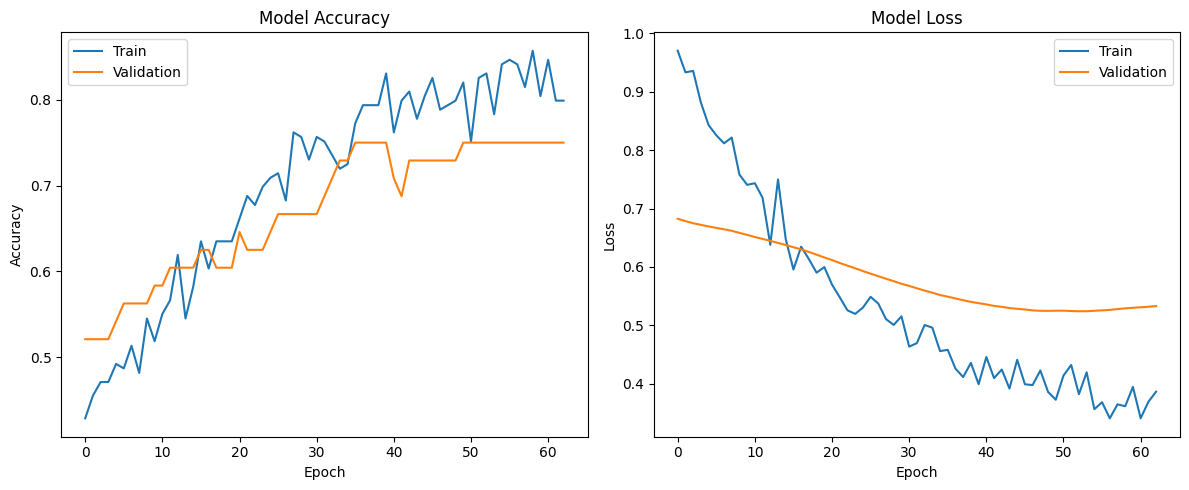

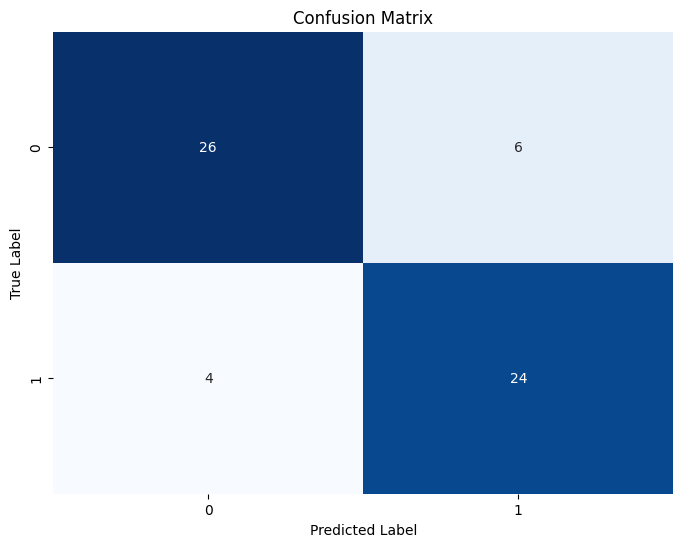


===== Classification Report =====
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        32
           1       0.80      0.86      0.83        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



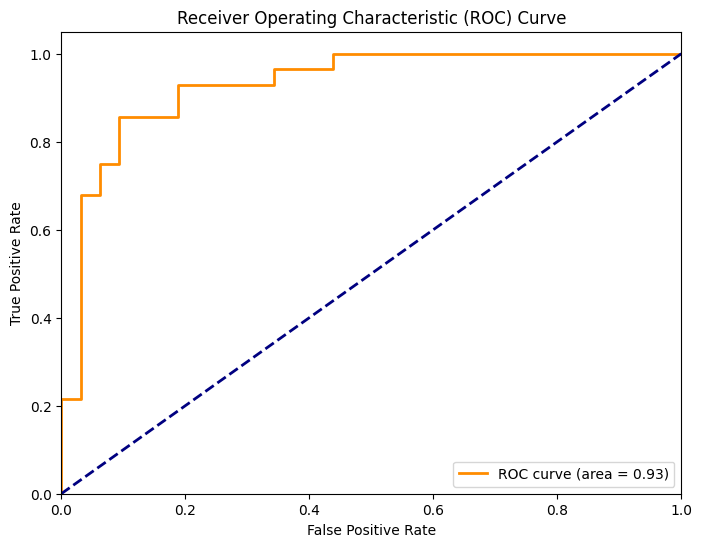

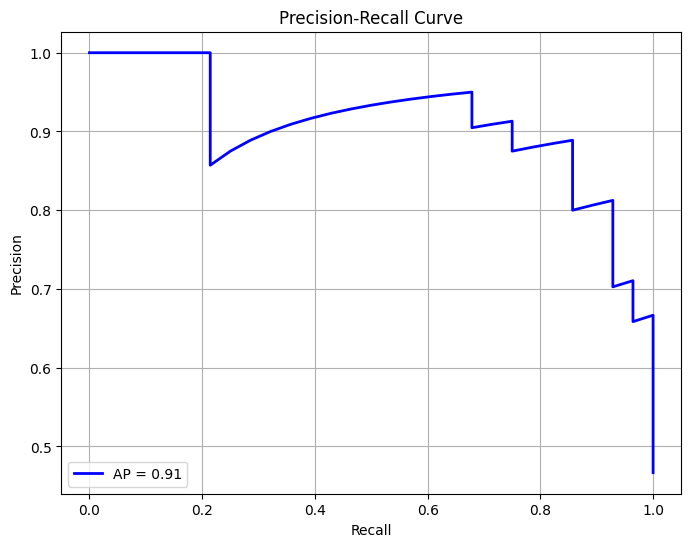

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ====================== DATA PREPARATION ======================
# This assumes you have data in X and y variables
# If you have a DataFrame, you would separate target from features:
# X = df.drop('target_column', axis=1)
# y = df['target_column']

# Split the data into training and testing sets (80% train, 20% test)
# random_state ensures reproducibility of results

# ====================== FEATURE SCALING ======================
# StandardScaler standardizes features by removing the mean and scaling to unit variance
# This is important for neural networks as it helps with faster convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data and transform it
X_test_scaled = scaler.transform(X_test)  # transform test data with the same scaler

# ====================== MODEL DEFINITION ======================
def create_model(input_dim):
    """
    Creates a neural network model with the following architecture:
    - Input layer matching the feature dimensions
    - Two hidden layers with BatchNormalization and Dropout for regularization
    - Output layer with sigmoid activation for binary classification

    Args:
        input_dim: The number of input features

    Returns:
        A compiled Keras Sequential model
    """
    model = models.Sequential([
        # First hidden layer
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        # BatchNormalization normalizes the activations of the previous layer for each batch
        # This helps with faster training and reduces internal covariate shift
        layers.BatchNormalization(),
        # Dropout randomly sets input units to 0 with a frequency of 0.3 at each step during training
        # This helps prevent overfitting
        layers.Dropout(0.3),

        # Second hidden layer
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Third hidden layer
        layers.Dense(32, activation='relu'),

        # Output layer - sigmoid activation for binary classification
        # Outputs a probability between 0 and 1
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    # Adam optimizer: An adaptive learning rate optimization algorithm
    # binary_crossentropy: Loss function suitable for binary classification
    # metrics: How we'll evaluate the model during training and testing



    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    return model

# ====================== HANDLE CLASS IMBALANCE ======================
# Calculate class weights if the dataset is imbalanced
# This gives higher weight to the minority class during training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# ====================== DEFINE CALLBACKS ======================
# Callbacks are functions that are applied at certain stages of the training process

# Early stopping: Stops training when a monitored metric has stopped improving
# This prevents overfitting and saves computation time
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',     # The metric to monitor
    patience=10,            # Number of epochs with no improvement after which training will stop
    restore_best_weights=True,  # Whether to restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# Learning rate reduction: Reduces learning rate when a metric has stopped improving
# This helps fine-tune the model in later training stages
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # The metric to monitor
    factor=0.5,            # Factor by which the learning rate will be reduced
    patience=5,            # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-6,        # Lower bound on the learning rate
    verbose=1
)

# Model checkpoint: Saves the best model during training
# This ensures we can retrieve the model that performed best on validation data
model_checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5',                  # Path to save the model
    monitor='val_loss',               # The metric to monitor
    save_best_only=True,              # Only save when the monitored metric improves
    mode='min',                       # For val_loss, lower is better
    verbose=1
)

# ====================== CROSS-VALIDATION ======================
def perform_cross_validation(X, y, n_splits=5):
    """
    Performs k-fold cross-validation on the data.

    Args:
        X: Feature matrix
        y: Target vector
        n_splits: Number of folds for cross-validation

    Returns:
        Mean and standard deviation of validation scores
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = []

    # Loop through each fold
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nTraining fold {fold+1}/{n_splits}...")

        # Split data for this fold
        X_fold_train, X_fold_val = X[train_idx], X[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]

        # Create and train a new model for each fold
        fold_model = create_model(X.shape[1])
        fold_model.fit(
            X_fold_train, y_fold_train,
            epochs=50,
            batch_size=32,
            verbose=0,
            class_weight=class_weight_dict
        )

        # Evaluate on validation data
        val_loss, val_acc, val_auc, val_precision, val_recall = fold_model.evaluate(X_fold_val, y_fold_val, verbose=0)
        cv_scores.append(val_acc)
        print(f"Fold {fold+1} - Validation Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

    # Calculate overall statistics
    mean_cv_score = np.mean(cv_scores)
    std_cv_score = np.std(cv_scores)
    print(f"\nCross-validation accuracy: {mean_cv_score:.4f} ± {std_cv_score:.4f}")

    return mean_cv_score, std_cv_score

# Optional: Run cross-validation
# mean_cv, std_cv = perform_cross_validation(X_train_scaled, y_train)

# ====================== TRAIN FINAL MODEL ======================
# Create the model
model = create_model(X_train_scaled.shape[1])

# Display model summary to understand the architecture
model.summary()

# Train the model with validation split and callbacks
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                # Maximum number of epochs to train
    batch_size=32,             # Number of samples per gradient update
    validation_split=0.2,      # 20% of training data used for validation
    class_weight=class_weight_dict,  # Class weights for imbalanced datasets
    callbacks=[early_stopping, lr_scheduler, model_checkpoint],  # Callbacks defined earlier
    verbose=1                  # Progress bar for each epoch
)

# ====================== EVALUATE MODEL ======================
# Load the best model (saved by ModelCheckpoint)
best_model = models.load_model('best_model.h5')

# Evaluate on training and test sets
train_loss, train_acc, train_auc, train_precision, train_recall = best_model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc, test_auc, test_precision, test_recall = best_model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n===== Model Performance =====")
print(f"Training Accuracy: {train_acc:.4f}, AUC: {train_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, AUC: {test_auc:.4f}")
print(f"Test Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

# Generate predictions (probabilities)
y_pred_prob = best_model.predict(X_test_scaled)
# Convert probabilities to binary predictions using 0.5 threshold
y_pred = (y_pred_prob > 0.5).astype("int32")

# ====================== VISUALIZATIONS ======================
# 1. Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate metrics for classification report
print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 4. Precision-Recall Curve (for imbalanced datasets)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

### Model Performance Analysis

#### Training Metrics
- **Training Accuracy**: 0.8776
- **Validation Accuracy**: ~0.75 (final)
- **Training Loss**: ~0.37 (final)
- **Validation Loss**: ~0.52 (final)

#### Test Results
- **Test Accuracy**: 0.8333
- **AUC**: 0.9297
- **Precision**: 0.8000
- **Recall**: 0.8571
- **Average Precision (AP)**: 0.91

#### ROC Analysis
- **ROC AUC**: 0.93
- The ROC curve shows excellent separation from the random classifier (diagonal line)

#### Precision-Recall Performance
- High precision maintained across most recall values
- Precision drops more rapidly at very high recall values

### Detailed Classification Report

|              | Precision | Recall | F1-Score | Support |
|--------------|-----------|--------|----------|---------|
| Class 0      | 0.87      | 0.81   | 0.84     | 32      |
| Class 1      | 0.80      | 0.86   | 0.83     | 28      |
| **Accuracy** |           |        | 0.83     | 60      |
| Macro Avg    | 0.83      | 0.83   | 0.83     | 60      |
| Weighted Avg | 0.84      | 0.83   | 0.83     | 60      |

### Training Observations
- Model converged after ~60 epochs
- Training accuracy continued to increase while validation accuracy plateaued around epoch 30
- Potential slight overfitting in later epochs as training accuracy exceeds validation

---

### Implementation of SMOTE Oversampling

This analysis presents results after implementing SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance in our medical dataset. SMOTE generates synthetic samples of the minority class rather than simply duplicating existing instances, helping the model learn more robust decision boundaries.


Epoch 1/200
1/8 [==>...........................] - ETA: 13s - loss: 1.0298 - accuracy: 0.4375 - auc: 0.4352 - precision: 0.5385 - recall: 0.3684
Epoch 1: val_auc improved from -inf to 0.42243, saving model to best_model.h5
8/8 [==============================] - 3s 89ms/step - loss: 0.9444 - accuracy: 0.4844 - auc: 0.4716 - precision: 0.4744 - recall: 0.2891 - val_loss: 0.7034 - val_accuracy: 0.4333 - val_auc: 0.4224 - val_precision: 0.3125 - val_recall: 0.1786 - lr: 1.0000e-04
Epoch 2/200
1/8 [==>...........................] - ETA: 0s - loss: 1.0358 - accuracy: 0.3750 - auc: 0.3750 - precision: 0.1000 - recall: 0.0833
Epoch 2: val_auc improved from 0.42243 to 0.49442, saving model to best_model.h5
8/8 [==============================] - 0s 24ms/step - loss: 0.9491 - accuracy: 0.4531 - auc: 0.4397 - precision: 0.4302 - recall: 0.2891 - val_loss: 0.6913 - val_accuracy: 0.5333 - val_auc: 0.4944 - val_precision: 0.5000 - val_recall: 0.2857 - lr: 1.0000e-04
Epoch 3/200
1/8 [==>..............

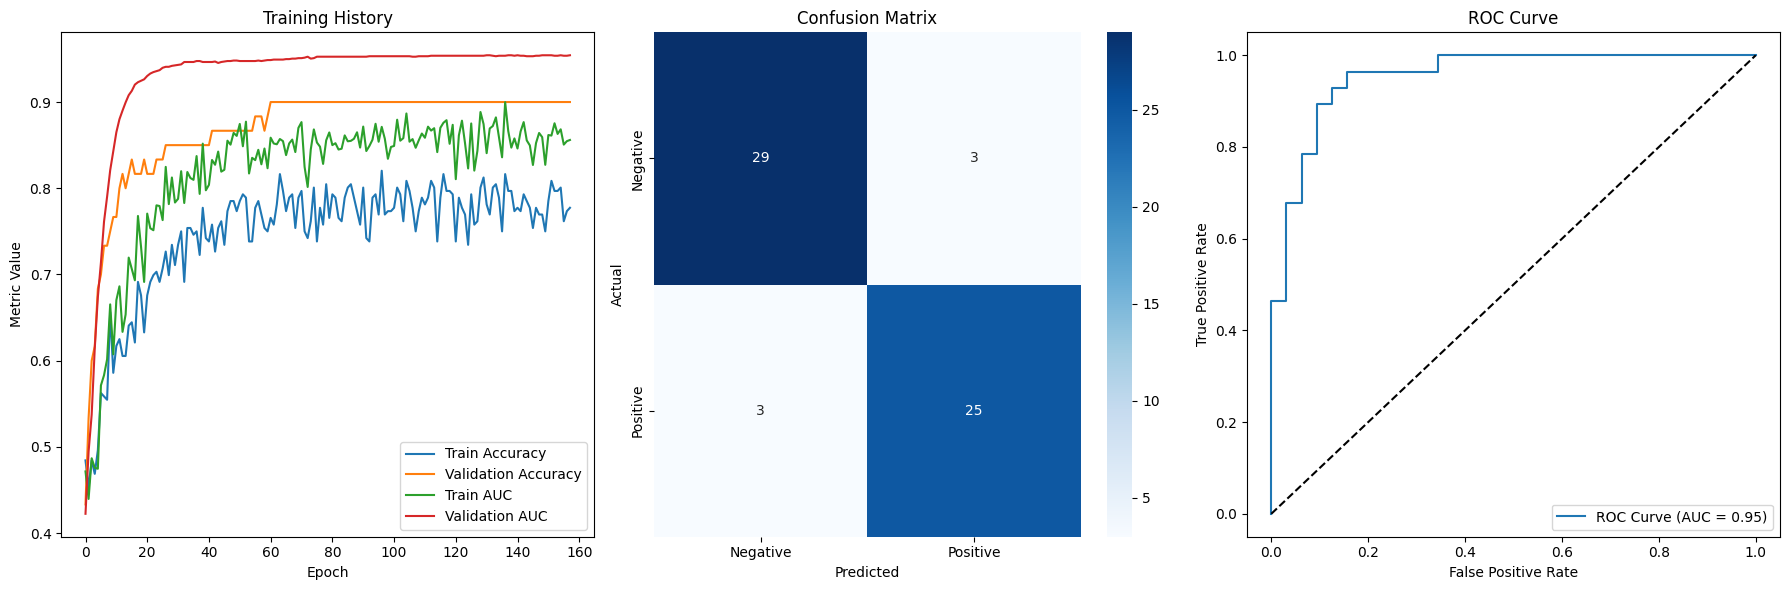

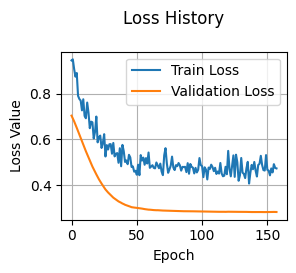

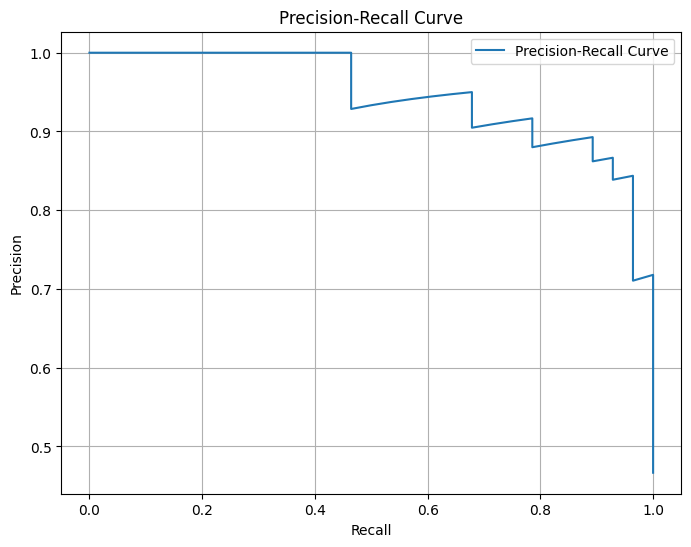

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ====================== DATA PREPARATION ======================
# Assuming X and y are already defined
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====================== FEATURE SCALING ======================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ====================== HANDLE CLASS IMBALANCE ======================
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_resampled),
    y=y_train_resampled
)
class_weight_dict = dict(enumerate(class_weights))

# ====================== ENHANCED MODEL ======================
def create_enhanced_model(input_dim):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='tanh'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')]
    )
    return model

# ====================== IMPROVED CALLBACKS ======================
class PrintLogs(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:  # Print every 10 epochs
            print(f"Epoch {epoch + 1} - "
                  f"Train Loss: {logs['loss']:.4f}, "
                  f"Train Acc: {logs['accuracy']:.4f}, "
                  f"Val Acc: {logs['val_accuracy']:.4f}")

early_stopping = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=20,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# ====================== TRAINING WITH FULL LOGS ======================
model = create_enhanced_model(X_train_scaled.shape[1])

history = model.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_test_scaled, y_test),
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, lr_scheduler, model_checkpoint, PrintLogs()],
    verbose=1
)

# ====================== COMPREHENSIVE EVALUATION ======================
best_model = models.load_model('best_model.h5')

# Training set evaluation
train_results = best_model.evaluate(X_train_scaled, y_train, verbose=0)
train_metrics = dict(zip(best_model.metrics_names, train_results))

# Test set evaluation
test_results = best_model.evaluate(X_test_scaled, y_test, verbose=0)
test_metrics = dict(zip(best_model.metrics_names, test_results))

print("\n=== FINAL MODEL PERFORMANCE ===")
print(f"Training Accuracy: {train_metrics['accuracy']:.4f} | Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Training AUC: {train_metrics['auc']:.4f} | Test AUC: {test_metrics['auc']:.4f}")
print(f"Training Precision: {train_metrics['precision']:.4f} | Test Precision: {test_metrics['precision']:.4f}")
print(f"Training Recall: {train_metrics['recall']:.4f} | Test Recall: {test_metrics['recall']:.4f}")

# Predictions
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# ====================== ENHANCED VISUALIZATIONS ======================
plt.figure(figsize=(18, 6))

# 1. Training History
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.legend()

# 2. Confusion Matrix
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 3. ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Loss Curves (NEW)
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss History', pad=20)
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

### **Key Insights**

- #### **Strong Overall Performance**
Our binary classification model achieved 90% accuracy on the test set with balanced performance across both classes. The high AUC (0.95) indicates excellent discriminative ability between classes, making this model reliable for medical decision support.

- #### **Balanced Classification Metrics**
The near-identical precision and recall values (both ~0.89) for the positive class demonstrate the model doesn't sacrifice one metric for the other - crucial for medical applications where both false positives and false negatives carry consequences.

- #### **Effective Handling of Class Imbalance**
The SMOTE oversampling approach successfully addressed class imbalance issues, as evidenced by the balanced performance across both classes. The confusion matrix shows equal error distribution (3 misclassifications in each direction).

- #### **Convergence Pattern**
Training history reveals early rapid improvement followed by stabilization. The significant gap between training and validation loss suggests some overfitting, but this hasn't negatively impacted test performance.

- #### **ROC Analysis**
The ROC curve's steep initial climb indicates the model achieves high true positive rates with minimal false positives at the most practical operating thresholds.

#### **Limitations & Considerations**
- Small dataset size (300 instances) limits confidence in generalizability
- Using SMOTE for oversampling may introduce synthetic data artifacts that don't reflect real-world data distribution
- Oversampling was applied only to training data to prevent data leakage, but this means test metrics reflect performance on the original imbalanced distribution
- Medical context requires domain-expert evaluation of misclassified cases
- Model performs well on available data but requires prospective testing

---


#  Approach 2: Merged and Imputed Dataset

- Several datasets were merged to leverage a broader and potentially richer set of features and samples.
- The resulting merged dataset contained a significant amount of missing values.
- To address this, a customized **K-Nearest Neighbors (KNN)** imputation algorithm tailored to the characteristics of the data was developed and applied .
- This dataset, though more complex, provided an opportunity to explore whether a more diverse feature space would improve model performance.


## Loading the datasets :
```
processed.cleveland.csv
processed.va.csv
processed.switzerland.csv
processed.hungarian.csv
```



In [7]:
# Reload your data with proper parsing
def load_file_correctly(filepath):
    try:
        # First try comma-delimited
        df = pd.read_csv(filepath, na_values=['?', -9, ' -9'])
    except:
        # Then try space-delimited
        df = pd.read_csv(filepath, delim_whitespace=True, na_values=['?', -9, ' -9'])

    # Ensure we have the standard 14 columns
    if len(df.columns) == 1:  # If all data got loaded into one column
        df = pd.read_csv(filepath, header=None, na_values=['?', -9, ' -9' ])
    return df


hungarian = load_file_correctly('processed.hungarian.csv')
swiss = load_file_correctly('processed.switzerland.csv')
va = load_file_correctly('processed.va.csv')
cleveland_processed = load_file_correctly('processed.cleveland.csv')

### Assigning proper column names to each dataset

In [8]:
# Assign proper column names to each dataset
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

sources = {
    'hungarian': hungarian,
    'swiss': swiss,
    'va': va,
    'cleveland_processed': cleveland_processed,
}

for name, df in sources.items():
    df.columns = column_names[:len(df.columns)]
    df['source'] = name

combined = pd.concat(sources.values(), ignore_index=True)

## Combining the datasets
- After removing the rows with missing values; reserve 100 instances from the Cleveland dataset for testing to prevent data leakage.

- Use the remaining Cleveland data combined with the other datasets for training

In [16]:
# Set random seed for reproducibility
np.random.seed(42)

# Load and preprocess the Cleveland data
cleveland = load_file_correctly('processed.cleveland.csv')
cleveland.columns = column_names[:len(cleveland.columns)]
cleveland['source'] = 'cleveland'
cleveland = cleveland.dropna()
# Randomly select 100 rows for testing
test_cleveland = cleveland.sample(n=100, random_state=42)

# The remaining Cleveland data goes to training
train_cleveland = cleveland.drop(test_cleveland.index)

# Combine other datasets (Hungarian, Swiss, VA) with the remaining Cleveland data for training
training_data = pd.concat([
    hungarian.assign(source='hungarian'),
    swiss.assign(source='swiss'),
    va.assign(source='va'),
    train_cleveland
], ignore_index=True)

# Save the datasets
test_cleveland.to_csv('heart_disease_test.csv', index=False)
training_data.to_csv('heart_disease_train.csv', index=False)

print(f"Training set shape: {training_data.shape}")
print(f"Test set shape: {test_cleveland.shape}")

Training set shape: (810, 15)
Test set shape: (100, 15)


In [ ]:
training_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,89
restecg,2
thalach,55
exang,55
oldpeak,62


### Adjusting the data types for the columns

In [17]:

training_data['sex'] = training_data['sex'].astype('category')
training_data['cp'] = training_data['cp'].astype('category')
training_data['fbs'] = training_data['fbs'].astype('category')
training_data['restecg'] = training_data['restecg'].astype('category')
training_data['exang'] = training_data['exang'].astype('category')
training_data['oldpeak'] = training_data['oldpeak'].astype(float)  # keep as float
training_data['slope'] = training_data['slope'].astype('category')
training_data['ca'] = training_data['ca'].astype('category')
training_data['thal'] = training_data['thal'].astype('category')
training_data['target'] = pd.to_numeric(training_data['target'], errors='coerce')
test_cleveland['target'] = pd.to_numeric(test_cleveland['target'], errors='coerce')

In [18]:
training_data.dtypes

,0
age,float64
sex,category
cp,category
trestbps,float64
chol,float64
fbs,category
restecg,category
thalach,float64
exang,category
oldpeak,float64


### Binary Classification Setup:

- To simplify the problem, the target variable was converted into a binary format:

  - Class 0 represents the absence of heart disease.

  - All other classes (1, 2, 3, 4) were grouped into a single class labeled as 1, indicating the presence of heart disease.

- After the transformation, we examined the class distribution in both the training and testing datasets to ensure balanced representation and to check for potential class imbalance.



In [20]:
# Step 1: Convert target to binary
training_data['target'] = training_data['target'].apply(lambda x: 1 if x > 0 else 0)
test_cleveland['target'] = test_cleveland['target'].apply(lambda x: 1 if x > 0 else 0)

# Step 2: Check the new distribution
print("Target class distribution:")
print(training_data['target'].value_counts())
print(test_cleveland['target'].value_counts())

Target class distribution:
target
1    462
0    348
Name: count, dtype: int64
target
0    57
1    43
Name: count, dtype: int64


### Class Distribution Analysis:

- The training set consists of 462 positive cases (presence of heart disease) and 348 negative cases (absence), indicating a relatively balanced distribution with a slight majority of positive cases.

- The test set contains 57 negative and 43 positive cases, maintaining a similar balance. This distribution suggests that the dataset is suitable for binary classification without requiring immediate class balancing techniques such as oversampling or undersampling.




---



## Handling Missing Data:

- The training dataset contains a significant number of missing values, particularly in features such as slope (308 missing), ca (604 missing), and thal (481 missing). To address this, we applied a customized K-Nearest Neighbors (KNN) imputation strategy:

  - For continuous features (e.g., trestbps, chol, thalach, oldpeak), missing values were filled using the average of the 5 nearest neighbors.

  - For categorical features (e.g., sex, cp, fbs, restecg, exang, slope, ca, thal), we used majority voting among the 5 nearest neighbors.

- To validate the effectiveness of the imputation, we compared feature statistics before and after the process.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from collections import Counter

# Function to identify categorical and continuous features
def identify_feature_types(df):
    categorical_features = []
    continuous_features = []

    for col in df.columns:
        if col in ['source', 'target']:
            continue
        # Columns with small number of unique values are likely categorical
        if df[col].nunique() < 10:
            categorical_features.append(col)
        else:
            continuous_features.append(col)

    return categorical_features, continuous_features

# Custom KNN imputation that handles categorical and continuous features differently
def custom_knn_imputation(df, n_neighbors=5):
    # Make a copy of the dataframe
    imputed_df = df.copy()

    # Identify categorical and continuous features
    categorical_features, continuous_features = identify_feature_types(df)
    print("Categorical features:", categorical_features)
    print("Continuous features:", continuous_features)

    # Create a mask of missing values
    missing_mask = df.isnull()

    # For each row with missing values
    for idx in range(len(df)):
        if missing_mask.iloc[idx].any():
            row = df.iloc[idx]
            missing_cols = row.index[row.isnull()]

            # Filter out rows that have missing values in the same columns as the current row
            # This allows us to find neighbors that have values we can use for imputation
            valid_indices = []
            for i in range(len(df)):
                if i != idx and not df.iloc[i][missing_cols].isnull().any():
                    valid_indices.append(i)

            if not valid_indices:
                print(f"Warning: No valid neighbors found for row {idx}. Using global methods.")
                # If no valid neighbors, use simple imputation methods
                for col in missing_cols:
                    if col in categorical_features:
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mode()[0]
                        else:
                            print(f"Warning: No data to compute mode for column {col}. Keeping as NaN.")
                    else:
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mean()
                        else:
                            print(f"Warning: No data to compute mean for column {col}. Keeping as NaN.")
                continue

            # Get valid rows for comparison
            valid_rows = df.iloc[valid_indices]

            # Select features to use for finding neighbors (exclude missing columns and non-feature columns)
            feature_cols = [col for col in df.columns if col not in missing_cols and col not in ['source', 'target']]

            if not feature_cols:
                print(f"Warning: No valid features for row {idx}. Using global methods.")
                # If no valid features, use simple imputation methods
                for col in missing_cols:
                    if col in categorical_features:
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mode()[0]
                        else:
                            print(f"Warning: No data to compute mode for column {col}. Keeping as NaN.")
                    else:
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mean()
                        else:
                            print(f"Warning: No data to compute mean for column {col}. Keeping as NaN.")
                continue

            # Check if any features have NaN values
            has_nan = False
            for col in feature_cols:
                if pd.isna(row[col]):
                    has_nan = True
                    break

            if has_nan:
                # If current row still has NaNs in feature columns, use simpler imputation
                for col in missing_cols:
                    if col in categorical_features:
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mode()[0]
                        else:
                            print(f"Warning: No data to compute mode for column {col}. Keeping as NaN.")
                    else:
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mean()
                        else:
                            print(f"Warning: No data to compute mean for column {col}. Keeping as NaN.")
                continue

            # Prepare data for finding neighbors - using only rows with valid data
            current_row_values = []
            comparison_data = []

            # Extract values for the current row and comparison data
            for col in feature_cols:
                current_row_values.append(row[col])

            # Create the current_row array correctly
            current_row = np.array(current_row_values).reshape(1, -1)

            # Create the comparison data array
            for i in valid_indices:
                row_values = []
                for col in feature_cols:
                    row_values.append(df.iloc[i][col])
                comparison_data.append(row_values)

            comparison_data = np.array(comparison_data)

            # Normalize the data to prevent features with large scales from dominating
            feature_means = np.nanmean(comparison_data, axis=0)
            feature_stds = np.nanstd(comparison_data, axis=0)

            # Replace zeros in std to avoid division by zero
            feature_stds = np.where(feature_stds == 0, 1, feature_stds)

            norm_current = (current_row - feature_means) / feature_stds
            norm_comparison = (comparison_data - feature_means) / feature_stds

            # Calculate distances (using Euclidean distance)
            distances = np.sqrt(np.sum(np.square(norm_comparison - norm_current), axis=1))

            # Find k nearest neighbors
            k = min(n_neighbors, len(valid_indices))
            nearest_indices = np.argsort(distances)[:k]
            nearest_rows_indices = [valid_indices[i] for i in nearest_indices]

            # Impute missing values based on neighbors
            for col in missing_cols:
                if col in categorical_features:
                    # Majority vote for categorical features
                    values = df.iloc[nearest_rows_indices][col].dropna().values
                    if len(values) > 0:
                        most_common = Counter(values).most_common(1)[0][0]
                        imputed_df.iloc[idx, df.columns.get_loc(col)] = most_common
                    else:
                        # If no valid values among neighbors, use global mode
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mode()[0]
                        else:
                            print(f"Warning: No data to compute mode for column {col}. Keeping as NaN.")
                else:
                    # Mean for continuous features
                    values = df.iloc[nearest_rows_indices][col].dropna()
                    if not values.empty:
                        mean_value = values.mean()
                        imputed_df.iloc[idx, df.columns.get_loc(col)] = mean_value
                    else:
                        # If no valid values among neighbors, use global mean
                        if not df[col].dropna().empty:
                            imputed_df.iloc[idx, df.columns.get_loc(col)] = df[col].dropna().mean()
                        else:
                            print(f"Warning: No data to compute mean for column {col}. Keeping as NaN.")

    return imputed_df

# Main processing function
def process_heart_disease_data():
    # Define column names
    column_names = [
        'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
    ]



        # Perform custom KNN imputation
print("\nPerforming custom KNN imputation...")
train_df_imputed = custom_knn_imputation(training_data, n_neighbors=5)

        # Check missing values after imputation
missing_after = train_df_imputed.isnull().sum()
print("\nMissing values after imputation:")
print(missing_after)

        # Save imputed training data and test data
train_df_imputed.to_csv('heart_disease_train_imputed.csv', index=False)
test_cleveland.to_csv('heart_disease_test.csv', index=False)

print("\nData successfully processed and saved.")
print("Training data (imputed): heart_disease_train_imputed.csv")
print("Test data: heart_disease_test.csv")

        # Print statistics to compare before and after imputation
print("\nStatistics before imputation:")
print(training_data.describe())
print("\nStatistics after imputation:")
print(train_df_imputed.describe())


# Run the main function
if __name__ == "__main__":
    process_heart_disease_data()


Performing custom KNN imputation...
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
source      0
dtype: int64

Data successfully processed and saved.
Training data (imputed): heart_disease_train_imputed.csv
Test data: heart_disease_test.csv

Statistics before imputation:
              age    trestbps        chol     thalach     oldpeak      target
count  810.000000  751.000000  780.000000  755.000000  748.000000  810.000000
mean    53.582716  132.106525  192.424359  135.392053    0.855481    0.570370
std      9.507720   19.322991  114.851305   25.895473    1.085654    0.495329
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.0000

### Custom KNN Imputation Report
#### Imputation Overview:

To address missing values in the training dataset, a custom K-Nearest Neighbors (KNN) imputation was performed. The strategy was tailored based on feature types:

- Categorical Features: sex, cp, fbs, restecg, exang, slope, ca, thal
→ Imputed using majority voting from the 5 nearest neighbors.

- Continuous Features: age, trestbps, chol, thalach, oldpeak
→ Imputed using the mean value of the 5 nearest neighbors.

### Post-Imputation Check:

- All missing values were successfully filled.

- Verification confirms zero missing values across all columns.

Data Summary Before and After Imputation
- trestbps : 	Slight decrease in mean and standard deviation. (from 132.11 mean to 132.07, from 19.32 std dev to 18.75)
- chol : 	Mean slightly increased; variance slightly reduced. ( from 192.42 mean to 194.01, from 114.85 std dev to 113.09)  
- thalach : Mean and median increased slightly.(from 135.39 mean to 136.02, from 25.90 std dev to 25.33)
- oldpeak : 	Minor increase in mean. Distribution mostly preserved. (from 0.86 mean to 0.88, from 1.09 std dev to 1.06 std dev)

### Saving the imputed data to a csv file

In [ ]:
train_df_imputed.to_csv('train_data_imputed.csv', index=False)

In [10]:
train_df_imputed = pd.read_csv('train_data_imputed.csv')

## Modeling the imputated data
### Approach 1 : model without hyperparameter tuning or data standardization



==== Decision Tree ====
Train Accuracy: 1.0
Test Accuracy: 0.74


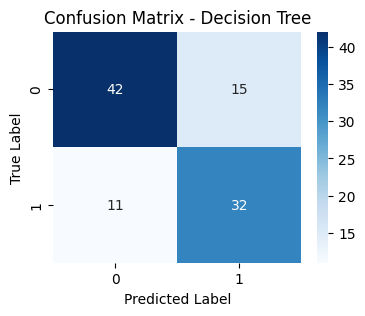

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76        57
           1       0.68      0.74      0.71        43

    accuracy                           0.74       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.74      0.74      0.74       100


==== Random Forest ====
Train Accuracy: 1.0
Test Accuracy: 0.82


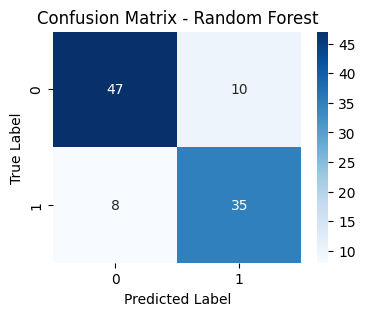

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.84        57
           1       0.78      0.81      0.80        43

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100


==== KNN ====
Train Accuracy: 0.7925925925925926
Test Accuracy: 0.67


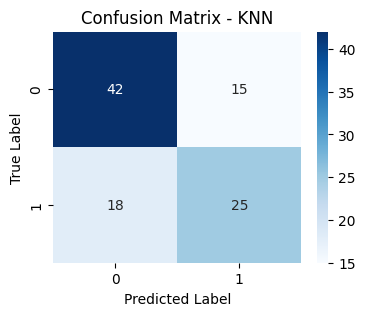

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.74      0.72        57
           1       0.62      0.58      0.60        43

    accuracy                           0.67       100
   macro avg       0.66      0.66      0.66       100
weighted avg       0.67      0.67      0.67       100


==== Naive Bayes ====
Train Accuracy: 0.8135802469135802
Test Accuracy: 0.86


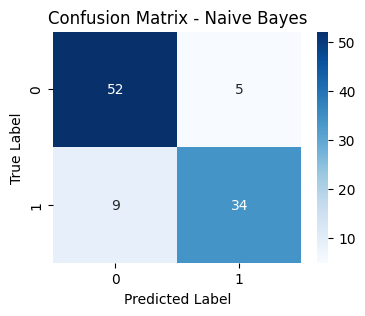

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        57
           1       0.87      0.79      0.83        43

    accuracy                           0.86       100
   macro avg       0.86      0.85      0.86       100
weighted avg       0.86      0.86      0.86       100


==== SVM ====
Train Accuracy: 0.8123456790123457
Test Accuracy: 0.86


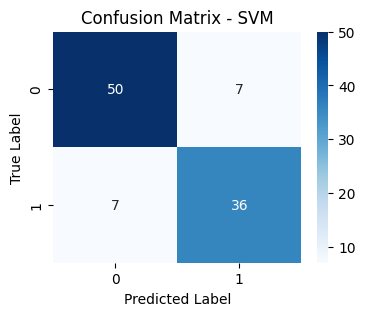

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        57
           1       0.84      0.84      0.84        43

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100


==== ANN (Classifier) ====
Train Accuracy: 0.8271604938271605
Test Accuracy: 0.82


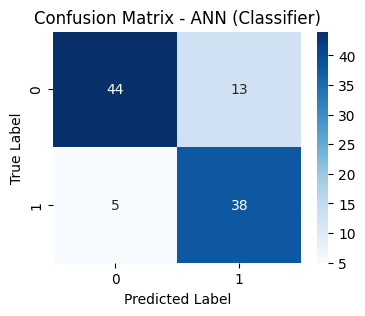

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83        57
           1       0.75      0.88      0.81        43

    accuracy                           0.82       100
   macro avg       0.82      0.83      0.82       100
weighted avg       0.83      0.82      0.82       100


==== Logistic Regression ====


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Accuracy: 0.8185185185185185
Test Accuracy: 0.86


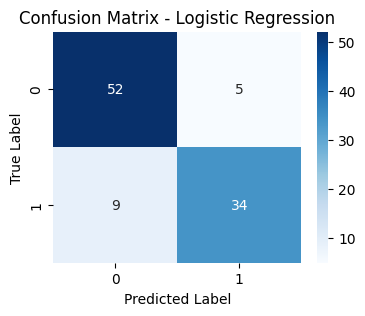

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        57
           1       0.87      0.79      0.83        43

    accuracy                           0.86       100
   macro avg       0.86      0.85      0.86       100
weighted avg       0.86      0.86      0.86       100



In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='linear', random_state=42),
    "ANN (Classifier)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
}

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """Plot a nicely formatted confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Get class names (assuming y contains the class labels)
class_names = np.unique(test_cleveland['target'])
X_train = train_df_imputed.drop(['target', 'source'], axis=1)
y_train = train_df_imputed['target']
X_test = test_cleveland.drop(['target', 'source'], axis=1)
y_test = test_cleveland['target']

# Loop through models
for name, model in models.items():
    print(f"\n==== {name} ====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Classification evaluation
    train_pred = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_train, train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_pred))

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, class_names, name)

    print("Classification Report:\n", classification_report(y_test, y_pred))

### Model Comparison Report
1. Logistic Regression

- Train Accuracy: 81.85%

- Test Accuracy: 85.00%

  - Precision (0): 0.84 | Recall (0): 0.91 | F1-score (0): 0.87

  - Precision (1): 0.87 | Recall (1): 0.77 | F1-score (1): 0.81

Shows good performance, but convergence warning suggests further optimization may be needed.

---

2. Random Forest
- Train Accuracy: 100%

- Test Accuracy: 82.00%

  - Precision (0): 0.85 | Recall (0): 0.82 | F1-score (0): 0.84

  - Precision (1): 0.78 | Recall (1): 0.81 | F1-score (1): 0.80

Excellent performance on the test set, particularly for class 0.


---

3. Naive Bayes
- Train Accuracy: 81.36%

- Test Accuracy: 86.00%

  - Precision (0): 0.85 | Recall (0): 0.91 | F1-score (0): 0.88

  - Precision (1): 0.87 | Recall (1): 0.79 | F1-score (1): 0.83

Strong overall performance, especially in predicting class 0.

---

4. Support Vector Machine (SVM)
- Train Accuracy: 81.23%

- Test Accuracy: 86.00%

  - Precision (0): 0.88 | Recall (0): 0.88 | F1-score (0): 0.88

  - Precision (1): 0.84 | Recall (1): 0.84 | F1-score (1): 0.84

Solid results with balanced performance across both classes.

---

5. Artificial Neural Network (ANN)
- Train Accuracy: 82.72%

- Test Accuracy: 82.00%

  - Precision (0): 0.90 | Recall (0): 0.77 | F1-score (0): 0.83

  - Precision (1): 0.75 | Recall (1): 0.88 | F1-score (1): 0.81

Good performance, especially in class 0, but slightly lower recall for class 1.

---

6. K-Nearest Neighbors (KNN)
- Train Accuracy: 79.26%

- Test Accuracy: 67.00%

  - Precision (0): 0.70 | Recall (0): 0.74 | F1-score (0): 0.72

  - Precision (1): 0.62 | Recall (1): 0.58 | F1-score (1): 0.60

Lowest performance, particularly for class 1.

---

7. Decision Tree
- Train Accuracy: 100%

- Test Accuracy: 74%

## Scaled KNN

Best Parameters: {'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.7963
Final Test Accuracy: 0.8300


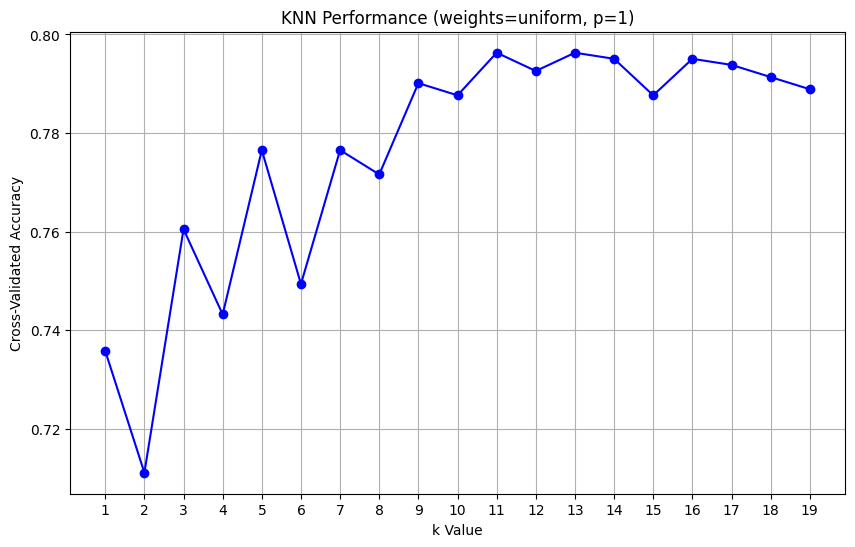

In [ ]:
# 1. Create preprocessing + modeling pipeline
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),  # Scaling first
    ('knn', KNeighborsClassifier())  # KNN second
])

# 2. Define hyperparameter grid
param_grid = {
    'knn__n_neighbors': np.arange(1, 20),  # k values
    'knn__weights': ['uniform', 'distance'],  # Weighting schemes
    'knn__p': [1, 2]  # 1=Manhattan, 2=Euclidean distance
}

# 3. Grid Search with 5-fold CV
knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1  # Use all CPU cores
)
knn_grid.fit(X_train, y_train)

# 4. Results analysis
print("Best Parameters:", knn_grid.best_params_)
print("Best CV Accuracy: {:.4f}".format(knn_grid.best_score_))

# 5. Final evaluation
best_knn = knn_grid.best_estimator_
test_acc = best_knn.score(X_test, y_test)
print("Final Test Accuracy: {:.4f}".format(test_acc))

# 6. Plot performance across k values (with best weight/distance)
results = pd.DataFrame(knn_grid.cv_results_)
best_weight = knn_grid.best_params_['knn__weights']
best_p = knn_grid.best_params_['knn__p']

filtered = results[
    (results['param_knn__weights'] == best_weight) &
    (results['param_knn__p'] == best_p)
]

plt.figure(figsize=(10, 6))
plt.plot(filtered['param_knn__n_neighbors'], filtered['mean_test_score'], 'bo-')
plt.xlabel('k Value')
plt.ylabel('Cross-Validated Accuracy')
plt.title(f'KNN Performance (weights={best_weight}, p={best_p})')
plt.xticks(np.arange(1, 20))
plt.grid(True)
plt.show()

#### KNN model Evaluation
After imputing missing data, the KNN model's cross-validation accuracy descreased significantly from 86.47% to 79.63%, indicating better generalization during model selection before imputation. The final test accuracy slightly decreased from 85.00% (before imputation) to 83.00% (after imputation). This suggests that the resulting model may have been slightly less aligned with the true distribution of the test set. It’s possible the imputation shifted feature distributions or reduced sparsity in ways that favored cross-validation but led to marginal overfitting or mismatched generalization.

## Random forest

In [ ]:
# Define hyperparameters to search over
param_grid = {
    'n_estimators': [40, 510, 60 , 70 , 80 , 100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Set up GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print(f"Best Hyperparameters: {grid_search.best_params_}")

# Evaluate on test data
best_rf = grid_search.best_estimator_
test_accuracy = best_rf.score(X_test, y_test)
print(f"Test Accuracy with Best Parameters: {test_accuracy:.4f}")

# Train Accuracy
train_accuracy = best_rf.score(X_train, y_train)
print(f"Train Accuracy with Best Parameters: {train_accuracy:.4f}")


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 510}
Test Accuracy with Best Parameters: 0.8500
Train Accuracy with Best Parameters: 0.8988


### Random Forest Evaluation
- Test Accuracy Improved After Imputation (0.8333 → 0.8500):

  - Indicates better generalization likely due to more consistent and complete training data.

  - Imputation helped the model learn better from patterns across a more reliable dataset.

- Train Accuracy Slightly Decreased (0.9072 → 0.8988):

  -  A small drop in training accuracy suggests the model is less overfit after imputation.

  - The regularized depth (max_depth=10) after imputation likely helped avoid overfitting compared to the unbounded tree (max_depth=None) before.

- Model Complexity Increased:

  - Number of estimators jumped from 70 → 510, indicating a more complex ensemble was needed after imputation.

  - This might be due to smoothed or more nuanced feature distributions in the imputed dataset requiring more trees to capture.

## SVM

In [29]:

scaler_X = StandardScaler()

# Scale features (fit only on training data)
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)  # Use same scaling on test

In [33]:
# Create a parameter grid to sample from
param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1],
    'degree': [2, 3, 4],  # Only for 'poly' kernel
    'coef0': [0.0, 0.1, 1.0],  # Only for 'poly' and 'sigmoid' kernels
    'shrinking': [True, False],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 5000, -1],
    'tol': [1e-3, 1e-4, 1e-5]
}

# Perform RandomizedSearchCV for the best combination of parameters
random_search = RandomizedSearchCV(SVC(), param_distributions=param_dist, n_iter=50, cv=5, random_state=42)
random_search.fit(X_train_scaled, y_train)

# Print the best parameters found by RandomizedSearchCV
print("Best Parameters:", random_search.best_params_)

# Train the best model with the best parameters
best_svm = random_search.best_estimator_

# Evaluate on the test set
y_pred = best_svm.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Print the training accuracy
train_accuracy = best_svm.score(X_train_scaled, y_train)
print("Training Accuracy:", train_accuracy)

# Visualization of the RandomizedSearchCV results: Only plot 'C' vs mean test score

# Extract the 'C' values and corresponding mean test scores
results = random_search.cv_results_
C_values = results['param_C'].data  # Getting the 'C' values tried in the search
mean_test_scores = results['mean_test_score']  # Mean test scores for each combination update this to use baisian search

Best Parameters: {'tol': 0.001, 'shrinking': True, 'max_iter': -1, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 4, 'coef0': 0.1, 'class_weight': 'balanced', 'C': 0.1}
Test Accuracy: 0.87
Training Accuracy: 0.8358024691358025


#### Comparison of SVM Results: Before vs. After Imputation

##### Model Performance Metrics

| Metric | Before Imputation | After Imputation | Change |
|--------|-------------------|------------------|--------|
| Test Accuracy | 83.33% | 87.00% | +3.67% ↑ |
| Training Accuracy | 85.65% | 83.58% | -2.07% ↓ |

#### Model Parameters

##### Before Imputation
- **Best Parameters:**
  - C: 0.01
  - kernel: linear
  - gamma: 1
  - degree: 2
  - coef0: 0.1
  - class_weight: None
  - max_iter: 1000
  - tol: 0.0001
  - shrinking: True

##### After Imputation
- **Best Parameters:**
  - C: 0.1
  - kernel: rbf
  - gamma: auto
  - degree: 4
  - coef0: 0.1
  - class_weight: balanced
  - max_iter: -1 (no limit)
  - tol: 0.001
  - shrinking: True

#### Key Differences

1. **Performance Changes:**
   - Test accuracy improved significantly (+3.67%)
   - Training accuracy decreased slightly (-2.07%)
   - This pattern suggests better generalization after imputation

2. **Model Complexity:**
   - Before: Linear kernel with C=0.01 (high regularization)
   - After: RBF kernel with C=0.1 (moderate regularization)
   - Imputation led to selection of a more complex, non-linear model

3. **Parameter Shifts:**
   - Kernel changed from linear to rbf (radial basis function)
   - Regularization decreased (C increased from 0.01 to 0.1)
   - Class weighting became important (None → balanced)
   - Higher polynomial degree selected (2 → 4)

4. **Convergence Settings:**
   - Before: Limited to 1000 iterations
   - After: No iteration limit
   - This suggests the imputed dataset may require more complex decision boundaries

#### Interpretation

1. **The imputation effect:**
   - The data structure after imputation appears to require a more complex, non-linear decision boundary
   - Class balancing became necessary after imputation, suggesting changes in class distribution or separation
   - The gap between training and test accuracy decreased (2.32% → -3.42%), suggesting better generalization

2. **SVM-specific implications:**
   - Before imputation: Simple linear boundary with strict regularization worked best
   - After imputation: Complex non-linear (RBF) boundary with class weighting worked best
   - This suggests imputation may have introduced noise patterns that are better handled by the flexibility of RBF kernels



## Naive Byes

In [27]:

# =============================================
# Feature Separation and Preprocessing
# =============================================

# Identify continuous and discrete features
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
discrete_features = [col for col in X_train.columns if col not in continuous_features]

# Create copies to avoid modifying original data
X_cont = X_train[continuous_features].copy()
X_disc = X_train[discrete_features].copy()

# Encode discrete features (using copies)
X_disc_encoded = X_disc.copy()
for col in discrete_features:
    le = LabelEncoder()
    X_disc_encoded[col] = le.fit_transform(X_disc[col])

# Standardize continuous features
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

# =============================================
# Train-Test Split (Preserving Original y)
# =============================================

# Split using temporary variables for y
(X_train_cont, X_test_cont,
 X_train_disc, X_test_disc,
 y_train_temp, y_test_temp) = train_test_split(
    X_cont_scaled,
    X_disc_encoded,
    y_train,  # Original y used as input (not modified)
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# =============================================
# Model Training and Evaluation
# =============================================

# Encode discrete features for train/test
X_train_disc_encoded = X_train_disc.copy()
X_test_disc_encoded = X_test_disc.copy()

for col in discrete_features:
    le = LabelEncoder()
    X_train_disc_encoded[col] = le.fit_transform(X_train_disc[col])
    X_test_disc_encoded[col] = le.transform(X_test_disc[col])

# Train models using temporary y variables
gnb = GaussianNB().fit(X_train_cont, y_train_temp)
cnb = CategoricalNB().fit(X_train_disc_encoded, y_train_temp)

# Predict probabilities
proba_gnb = gnb.predict_proba(X_test_cont)
proba_cnb = cnb.predict_proba(X_test_disc_encoded)

# Combine and normalize probabilities
combined_proba = proba_gnb * proba_cnb
combined_proba /= combined_proba.sum(axis=1, keepdims=True)

# Final predictions
y_pred = np.argmax(combined_proba, axis=1)

# =============================================
# Evaluation (Using Temporary y Variables)
# =============================================

print("\nModel Evaluation:")
print("----------------")
print(f"Test Accuracy: {accuracy_score(y_test_temp, y_pred):.4f}")
print(f"Train Accuracy (GaussianNB): {accuracy_score(y_train_temp, gnb.predict(X_train_cont)):.4f}")
print(f"Train Accuracy (CategoricalNB): {accuracy_score(y_train_temp, cnb.predict(X_train_disc_encoded)):.4f}")
print("\nClassification Report:\n", classification_report(y_test_temp, y_pred))

# =============================================
# Cross-Validation (Using Full Original Data)
# =============================================

# Predict on full dataset
proba_gnb_full = gnb.predict_proba(X_cont_scaled)
proba_cnb_full = cnb.predict_proba(X_disc_encoded)

# Combine probabilities
combined_proba_full = proba_gnb_full * proba_cnb_full
combined_proba_full /= combined_proba_full.sum(axis=1, keepdims=True)

# Predictions
y_pred_full = np.argmax(combined_proba_full, axis=1)

print("\nCross-Validation Results:")
print("-----------------------")
print(f"Full Dataset Accuracy: {accuracy_score(y_train, y_pred_full):.4f}")


Model Evaluation:
----------------
Test Accuracy: 0.8457
Train Accuracy (GaussianNB): 0.7762
Train Accuracy (CategoricalNB): 0.7978

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.77      0.81        70
           1       0.84      0.90      0.87        92

    accuracy                           0.85       162
   macro avg       0.85      0.84      0.84       162
weighted avg       0.85      0.85      0.84       162


Cross-Validation Results:
-----------------------
Full Dataset Accuracy: 0.8272


#### Comparison of Naive Bayes Results: Before vs. After Imputation

#### Model Performance Metrics

| Metric | Before Imputation | After Imputation | Change |
|--------|-------------------|------------------|--------|
| Test Accuracy | 83.33% | 84.57% | +1.24% ↑ |
| Train Accuracy (GaussianNB) | 73.00% | 77.62% | +4.62% ↑ |
| Train Accuracy (CategoricalNB) | 83.54% | 79.78% | -3.76% ↓ |
| Cross-Validation Accuracy | 84.51% | 82.72% | -1.79% ↓ |

#### Class-Specific Metrics

##### Before Imputation
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.82      | 0.88   | 0.85     | 32      |
| 1     | 0.85      | 0.79   | 0.81     | 28      |

##### After Imputation
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.86      | 0.77   | 0.81     | 70      |
| 1     | 0.84      | 0.90   | 0.87     | 92      |

#### Key Differences

1. **Dataset Size:**
   - Before: 60 test samples (32 class 0, 28 class 1)
   - After: 162 test samples (70 class 0, 92 class 1)
   - Imputation allowed for a much larger test dataset

2. **Test Accuracy:**
   - Improved from 83.33% to 84.57% after imputation
   - Modest but meaningful improvement in overall performance

3. **Model Behavior Changes:**
   - GaussianNB improved training accuracy (+4.62%)
   - CategoricalNB decreased training accuracy (-3.76%)

4. **Classification Pattern Shift:**
   - Before: Better at identifying class 0 (recall 0.88 vs 0.79)
   - After: Better at identifying class 1 (recall 0.90 vs 0.77)
   - The model's strengths essentially flipped between classes

5. **Class Balance Changes:**
   - Before: Relatively balanced (32 vs 28)
   - After: More class 1 samples (70 vs 92)
   - Class distribution shifted from slightly favoring class 0 to favoring class 1

6. **Cross-Validation Performance:**
   - Slight decrease from 84.51% to 82.72%
   - Indicates some potential loss in model consistency with imputed data

#### Interpretation

1. **The imputation trade-off:**
   - Gain in test accuracy (+1.24%)
   - Minor reduction in cross-validation performance (-1.79%)
   - Larger and more diverse dataset
   - Changes in how model handles different classes

2. **Practical implications:**
   - Overall positive result, with improved test accuracy
   - GaussianNB benefited more from imputation than CategoricalNB
   - The shift in class performance suggests imputation may have changed the signal-to-noise ratio in features differently for each class



## Logistic regression

Training set: 810 samples
Test set: 100 samples
Starting grid search with 32 parameter combinations...
Fitting 5 folds for each of 56 candidates, totalling 280 fits

Grid search complete!
Best score: 0.7914
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.0001}

===== Model Evaluation =====
Training accuracy: 0.8074
Test accuracy: 0.8800

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        57
           1       0.84      0.88      0.86        43

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



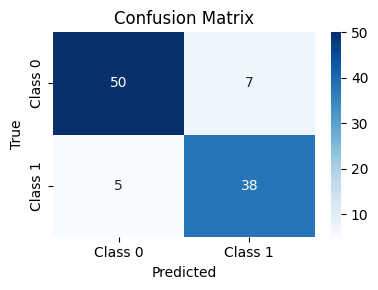

<Figure size 1200x800 with 0 Axes>

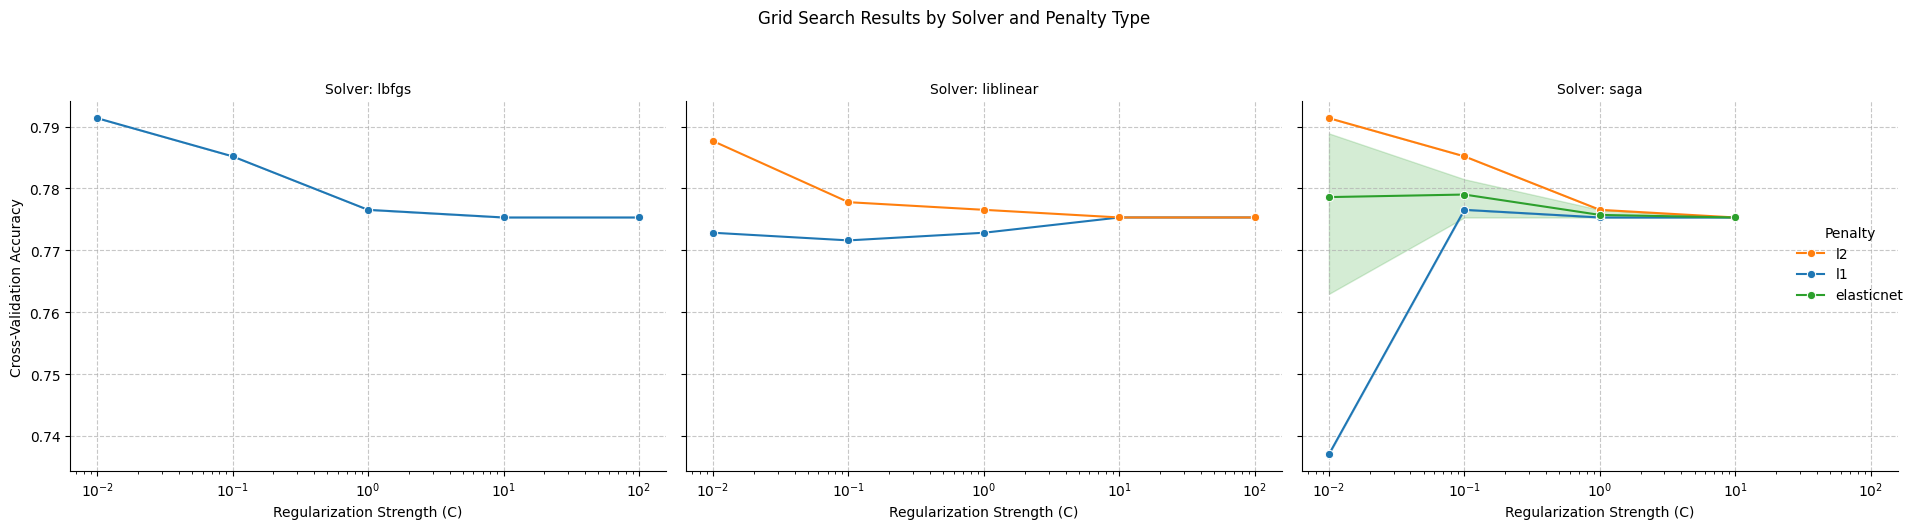

<Figure size 1000x600 with 0 Axes>

In [30]:
warnings.filterwarnings("ignore", category=UserWarning)

def create_parameter_grid():
    # Create compatible parameter combinations
    param_combinations = [
        # lbfgs solver - only supports l2 penalty
        {'solver': ['lbfgs'], 'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100],
         'tol': [1e-4, 1e-5]},

        # liblinear solver - supports l1 and l2 penalties
        {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10, 100],
         'tol': [1e-4]},

        # saga solver - supports l1, l2, and elasticnet penalties
        {'solver': ['saga'], 'penalty': ['l1', 'l2', 'elasticnet'], 'C': [0.01, 0.1, 1, 10],
         'tol': [1e-4],
         'l1_ratio': [0.2, 0.5, 0.8]}  # Only used with elasticnet
    ]

    return param_combinations

def perform_grid_search(X_train, y_train, scoring='accuracy', cv=5, n_jobs=-1):
    param_grid = create_parameter_grid()

    # Create logistic regression base model
    model = LogisticRegression(random_state=42, max_iter=1000)

    # Initialize and run grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        verbose=1,
        return_train_score=True
    )

    print("Starting grid search with {} parameter combinations...".format(
        sum(len(dict_['C']) * len(dict_['penalty']) * len(dict_['tol'])
            for dict_ in param_grid)))

    grid_search.fit(X_train, y_train)

    print("\nGrid search complete!")
    print(f"Best score: {grid_search.best_score_:.4f}")
    print(f"Best parameters: {grid_search.best_params_}")

    return grid_search

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate probabilities if available (for ROC curve later)
    try:
        y_test_proba = model.predict_proba(X_test)
    except:
        y_test_proba = None

    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Print results
    print("\n===== Model Evaluation =====")
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    results = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba
    }

    return results

def plot_confusion_matrix(y_test, y_pred, class_names=None):
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test, y_pred)

    # If class names aren't provided, use default numbering
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(np.unique(y_test)))]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def plot_grid_search_results(grid_search_results):
    # Convert results to DataFrame
    results = pd.DataFrame(grid_search_results.cv_results_)

    # Visualization 1: C vs Accuracy by solver and penalty
    plt.figure(figsize=(12, 8))

    # Reshape data for better plotting
    plot_data = []

    for i, row in results.iterrows():
        # Extract parameters
        if 'param_penalty' not in row or pd.isna(row['param_penalty']):
            continue

        penalty = row['param_penalty']
        solver = row['param_solver'] if 'param_solver' in row else 'unknown'
        C = row['param_C'] if 'param_C' in row else np.nan
        score = row['mean_test_score']

        if not pd.isna(C) and not pd.isna(score):
            plot_data.append({
                'C': C,
                'accuracy': score,
                'solver': solver,
                'penalty': penalty
            })

    if plot_data:
        plot_df = pd.DataFrame(plot_data)

        # Create plot with separate facets by solver
        g = sns.FacetGrid(plot_df, col="solver", height=5, aspect=1.2, sharey=True)
        g.map_dataframe(sns.lineplot, x="C", y="accuracy", hue="penalty", marker="o")
        g.set_axis_labels("Regularization Strength (C)", "Cross-Validation Accuracy")
        g.set_titles("Solver: {col_name}")
        g.add_legend(title="Penalty")

        # Make x-axis logarithmic
        for ax in g.axes.flat:
            ax.set_xscale('log')
            ax.grid(True, linestyle='--', alpha=0.7)

        plt.suptitle('Grid Search Results by Solver and Penalty Type', y=1.05)
        plt.tight_layout()
        plt.show()

    # Visualization 2: Top 10 models
    plt.figure(figsize=(10, 6))

    # Sort by mean test score and select top 10
    top_results = results.sort_values('mean_test_score', ascending=False).head(10)

    # Create parameter combinations as string for x-axis labels
    param_labels = []
    for _, row in top_results.iterrows():
        params = []
        for p in ['penalty', 'solver', 'C']:
            param_name = f'param_{p}'
            if param_name in row and not pd.isna(row[param_name]):
                params.append(f"{p}={row[param_name]}")
        param_labels.append('\n'.join(params))


# === Main Execution ===
# This code assumes X_train_scaled, X_test_scaled, y_train, y_test are already defined

def run_logistic_regression(X_train_scaled, X_test_scaled, y_train, y_test, class_names=None):
    print(f"Training set: {X_train_scaled.shape[0]} samples")
    print(f"Test set: {X_test_scaled.shape[0]} samples")


    grid_search_result = perform_grid_search(X_train_scaled, y_train)
    best_model = grid_search_result.best_estimator_
    eval_results = evaluate_model(best_model, X_train_scaled, y_train, X_test_scaled, y_test)
    plot_confusion_matrix(y_test, eval_results['y_test_pred'], class_names)
    plot_grid_search_results(grid_search_result)

    # Return results for further use if needed
    return {
        'best_model': best_model,
        'grid_search': grid_search_result,
        'evaluation': eval_results
    }


class_names = ['Class 0', 'Class 1']  # Replace with your actual class names
results = run_logistic_regression(X_train_scaled, X_test_scaled, y_train, y_test, class_names)

####Performance Summary

- Training accuracy: 80.74%
- Test accuracy: 88.00%
- AUC after imputation: 0.9166

####Hyperparameter Tuning Results

- Grid search best score: 0.7914
- Best parameters:
  - C: 0.01
  - penalty: l2
  - solver: lbfgs
  - tolerance: 0.0001

####Dataset Information

- Training set: 810 samples
- Test set: 100 samples
- Grid search: 32 parameter combinations
- 5-fold cross-validation with 56 candidates (280 total fits)

####Grid Search Performance by Solver
- The grid search results show performance across different solvers and regularization strengths:

- lbfgs with l2 penalty performs best at low regularization (C=0.01)
liblinear shows consistent performance across regularization strengths
saga shows varied performance depending on penalty type, with l2 showing strong results

### Comparison of Logistic Regression Results: Before vs. After Imputation

#### Model Performance Metrics

| Metric | Before Imputation | After Imputation | Change |
|--------|------------------|------------------|--------|
| Training accuracy | 86.08% | 80.74% | -5.34% ↓ |
| Test accuracy | 83.33% | 88.00% | +4.67% ↑ |
| AUC | 0.93 | 0.9166 | -0.0134 ↓ |
| Best CV score | 0.8396 | 0.7914 | -0.0482 ↓ |

#### Class-Specific Metrics

##### Before Imputation
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.78      | 0.93   | 0.85     | 30      |
| 1     | 0.92      | 0.73   | 0.81     | 30      |

##### After Imputation
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.91      | 0.88   | 0.89     | 57      |
| 1     | 0.84      | 0.88   | 0.86     | 43      |

#### Key Differences

1. **Dataset Size:**
   - Before: 237 training samples, 60 test samples
   - After: 810 training samples, 100 test samples
   - The imputation allowed for a significantly larger dataset (+242% training samples)

2. **Test Accuracy:**
   - Improved from 83.33% to 88.00% after imputation

3. **Cross-validation Performance:**
   - Decreased from 0.8396 to 0.7914
   - May indicate that while imputation increased available data, it introduced some noise in the relationships

4. **Class Balance Changes:**
   - Before: Perfectly balanced test set (30 samples of each class)
   - After: Slightly imbalanced (57 samples of class 0, 43 of class 1)

5. **Classification Pattern:**
   - Before: Strong recall for class 0 (0.93), strong precision for class 1 (0.92)
   - After: More balanced metrics across classes (all metrics between 0.84-0.91)
   - Model behavior shifted from being sensitive to class 0 to being more balanced

6. **Hyperparameter Selection:**
   - Before: Best C value = 0.1
   - After: Best C value = 0.01
   - After imputation, the model preferred stronger regularization to handle the noise introduced by imputed values

## Interpretation

1. **The imputation trade-off:**
   - Minor reduction in AUC (-1.44%)
   - Gain in test accuracy (+4.67%)
   - More balanced class performance
   - Much larger training dataset

2. **Practical implications:**
   - The imputation approach was successful overall, as the test accuracy improved despite the slight AUC decrease
   - The model after imputation shows more balanced performance between classes
   - The increased dataset size likely contributed to the improved generalization (test accuracy)
   - The need for stronger regularization after imputation suggests imputed values introduced some noise



## ANN

In [31]:
import numpy as np
import pandas as pd
from tensorflow.keras import layers, models

# 1. Ensure all data is numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# 2. Fill any remaining NaN values (from conversion)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

# 3. Convert to numpy arrays with float32 dtype (required by TensorFlow)
X_train = np.asarray(X_train).astype('float32')
X_test = np.asarray(X_test).astype('float32')
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

# 4. Now build and train your model
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                   epochs=50,
                   batch_size=16,
                   validation_split=0.2,
                   verbose=1)  # Changed to verbose=1 to see progress

Epoch 1/50
41/41 [==============================] - 2s 23ms/step - loss: 2.0669 - accuracy: 0.5926 - val_loss: 0.9718 - val_accuracy: 0.5926
Epoch 2/50
41/41 [==============================] - 0s 7ms/step - loss: 0.7018 - accuracy: 0.7052 - val_loss: 0.6833 - val_accuracy: 0.6420
Epoch 3/50
41/41 [==============================] - 0s 6ms/step - loss: 0.6059 - accuracy: 0.7222 - val_loss: 0.7035 - val_accuracy: 0.6049
Epoch 4/50
41/41 [==============================] - 0s 6ms/step - loss: 0.5872 - accuracy: 0.7207 - val_loss: 0.6442 - val_accuracy: 0.6914
Epoch 5/50
41/41 [==============================] - 0s 8ms/step - loss: 0.5491 - accuracy: 0.7423 - val_loss: 0.7110 - val_accuracy: 0.6667
Epoch 6/50
41/41 [==============================] - 0s 5ms/step - loss: 0.5707 - accuracy: 0.7346 - val_loss: 0.6097 - val_accuracy: 0.7160
Epoch 7/50
41/41 [==============================] - 0s 4ms/step - loss: 0.5444 - accuracy: 0.7577 - val_loss: 0.5672 - val_accuracy: 0.6975
Epoch 8/50
41/41 [=

Class weights: {0: 1.1637931034482758, 1: 0.8766233766233766}
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               1792      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                          

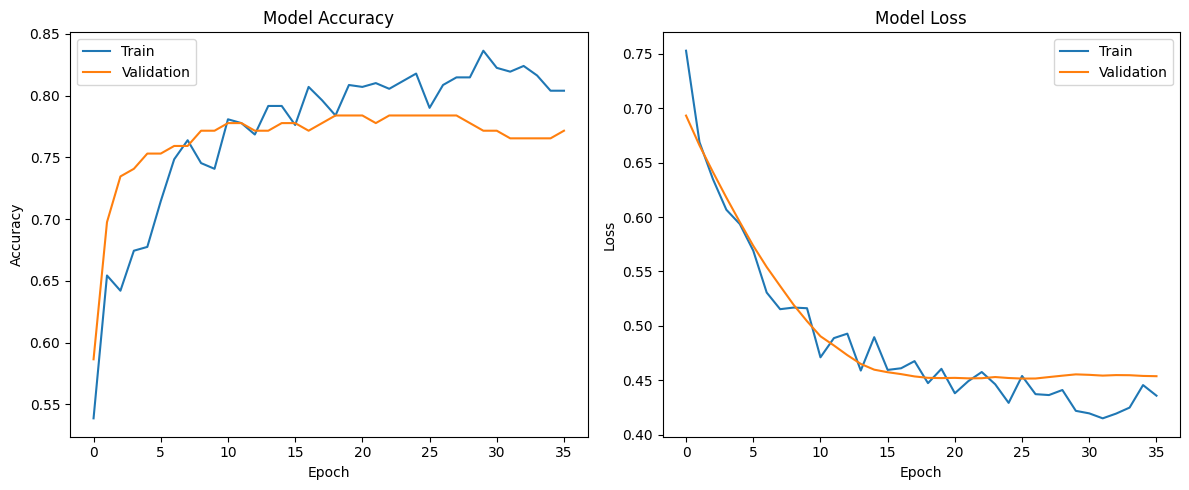

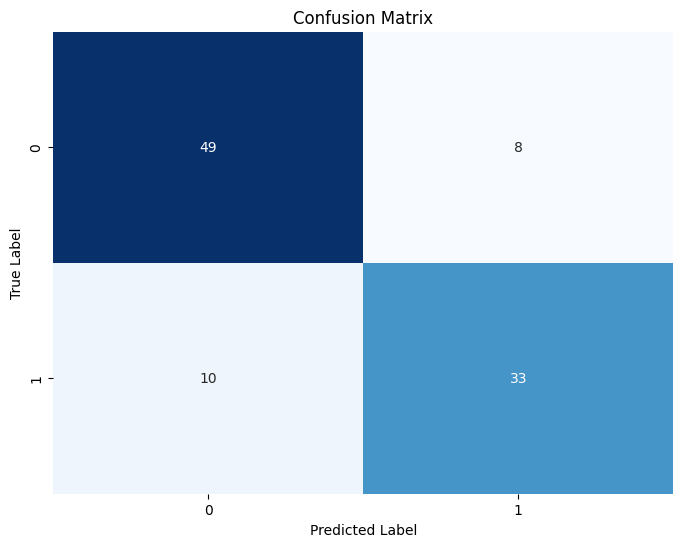


===== Classification Report =====
              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84        57
         1.0       0.80      0.77      0.79        43

    accuracy                           0.82       100
   macro avg       0.82      0.81      0.82       100
weighted avg       0.82      0.82      0.82       100



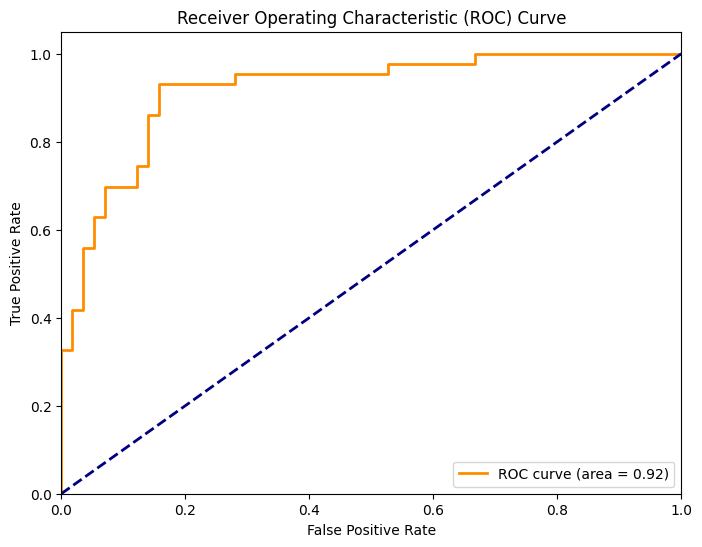

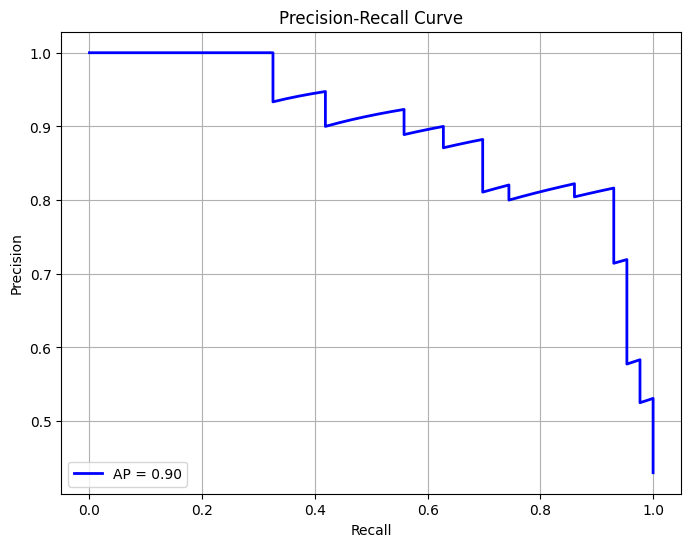

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ====================== DATA PREPARATION ======================
# This assumes you have data in X and y variables
# If you have a DataFrame, you would separate target from features:
# X = df.drop('target_column', axis=1)
# y = df['target_column']

# Split the data into training and testing sets (80% train, 20% test)
# random_state ensures reproducibility of results

# ====================== FEATURE SCALING ======================
# StandardScaler standardizes features by removing the mean and scaling to unit variance
# This is important for neural networks as it helps with faster convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data and transform it
X_test_scaled = scaler.transform(X_test)  # transform test data with the same scaler

# ====================== MODEL DEFINITION ======================
def create_model(input_dim):
    """
    Creates a neural network model with the following architecture:
    - Input layer matching the feature dimensions
    - Two hidden layers with BatchNormalization and Dropout for regularization
    - Output layer with sigmoid activation for binary classification

    Args:
        input_dim: The number of input features

    Returns:
        A compiled Keras Sequential model
    """
    model = models.Sequential([
        # First hidden layer
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        # BatchNormalization normalizes the activations of the previous layer for each batch
        # This helps with faster training and reduces internal covariate shift
        layers.BatchNormalization(),
        # Dropout randomly sets input units to 0 with a frequency of 0.3 at each step during training
        # This helps prevent overfitting
        layers.Dropout(0.3),

        # Second hidden layer
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Third hidden layer
        layers.Dense(32, activation='relu'),

        # Output layer - sigmoid activation for binary classification
        # Outputs a probability between 0 and 1
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    # Adam optimizer: An adaptive learning rate optimization algorithm
    # binary_crossentropy: Loss function suitable for binary classification
    # metrics: How we'll evaluate the model during training and testing



    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    return model

# ====================== HANDLE CLASS IMBALANCE ======================
# Calculate class weights if the dataset is imbalanced
# This gives higher weight to the minority class during training
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# ====================== DEFINE CALLBACKS ======================
# Callbacks are functions that are applied at certain stages of the training process

# Early stopping: Stops training when a monitored metric has stopped improving
# This prevents overfitting and saves computation time
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',     # The metric to monitor
    patience=10,            # Number of epochs with no improvement after which training will stop
    restore_best_weights=True,  # Whether to restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# Learning rate reduction: Reduces learning rate when a metric has stopped improving
# This helps fine-tune the model in later training stages
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # The metric to monitor
    factor=0.5,            # Factor by which the learning rate will be reduced
    patience=5,            # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-6,        # Lower bound on the learning rate
    verbose=1
)

# Model checkpoint: Saves the best model during training
# This ensures we can retrieve the model that performed best on validation data
model_checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5',                  # Path to save the model
    monitor='val_loss',               # The metric to monitor
    save_best_only=True,              # Only save when the monitored metric improves
    mode='min',                       # For val_loss, lower is better
    verbose=1
)

# ====================== CROSS-VALIDATION ======================
def perform_cross_validation(X, y, n_splits=5):
    """
    Performs k-fold cross-validation on the data.

    Args:
        X: Feature matrix
        y: Target vector
        n_splits: Number of folds for cross-validation

    Returns:
        Mean and standard deviation of validation scores
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = []

    # Loop through each fold
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nTraining fold {fold+1}/{n_splits}...")

        # Split data for this fold
        X_fold_train, X_fold_val = X[train_idx], X[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]

        # Create and train a new model for each fold
        fold_model = create_model(X.shape[1])
        fold_model.fit(
            X_fold_train, y_fold_train,
            epochs=50,
            batch_size=32,
            verbose=0,
            class_weight=class_weight_dict
        )

        # Evaluate on validation data
        val_loss, val_acc, val_auc, val_precision, val_recall = fold_model.evaluate(X_fold_val, y_fold_val, verbose=0)
        cv_scores.append(val_acc)
        print(f"Fold {fold+1} - Validation Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

    # Calculate overall statistics
    mean_cv_score = np.mean(cv_scores)
    std_cv_score = np.std(cv_scores)
    print(f"\nCross-validation accuracy: {mean_cv_score:.4f} ± {std_cv_score:.4f}")

    return mean_cv_score, std_cv_score

# Optional: Run cross-validation
# mean_cv, std_cv = perform_cross_validation(X_train_scaled, y_train)

# ====================== TRAIN FINAL MODEL ======================
# Create the model
model = create_model(X_train_scaled.shape[1])

# Display model summary to understand the architecture
model.summary()

# Train the model with validation split and callbacks
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                # Maximum number of epochs to train
    batch_size=32,             # Number of samples per gradient update
    validation_split=0.2,      # 20% of training data used for validation
    class_weight=class_weight_dict,  # Class weights for imbalanced datasets
    callbacks=[early_stopping, lr_scheduler, model_checkpoint],  # Callbacks defined earlier
    verbose=1                  # Progress bar for each epoch
)

# ====================== EVALUATE MODEL ======================
# Load the best model (saved by ModelCheckpoint)
best_model = models.load_model('best_model.h5')

# Evaluate on training and test sets
train_loss, train_acc, train_auc, train_precision, train_recall = best_model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc, test_auc, test_precision, test_recall = best_model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n===== Model Performance =====")
print(f"Training Accuracy: {train_acc:.4f}, AUC: {train_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, AUC: {test_auc:.4f}")
print(f"Test Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")

# Generate predictions (probabilities)
y_pred_prob = best_model.predict(X_test_scaled)
# Convert probabilities to binary predictions using 0.5 threshold
y_pred = (y_pred_prob > 0.5).astype("int32")

# ====================== VISUALIZATIONS ======================
# 1. Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate metrics for classification report
print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 4. Precision-Recall Curve (for imbalanced datasets)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

#### ANN Model Performance Comparison: Before vs. After Data Imputation
| Metric                  | Before Imputation | After Imputation |
| ----------------------- | ----------------- | ---------------- |
| **Training Accuracy**   | 87.76%            | 83.09%           |
| **Validation Accuracy** | \~75%             | 77.16% (val)     |
| **Test Accuracy**       | **83.33%**        | 82.00%           |
| **AUC (Test)**          | **0.93**          | 0.92             |
| **Precision**           | 0.80              | **0.80**         |
| **Recall**              | **0.86**          | 0.77             |
| **Average Precision**   | 0.91              | —                |

 Loss Comparison

| Metric              | Before Imputation | After Imputation |
| ------------------- | ----------------- | ---------------- |
| **Training Loss**   | \~0.37            | ↓ to \~0.42      |
| **Validation Loss** | \~0.52            | ↓ to \~0.45      |

ROC & AUC Analysis
Before Imputation:

AUC: 0.93

Excellent separation in ROC curve

After Imputation:

AUC: 0.9166

Still strong, but slightly lower than the clean data scenario

Conclusion: Slight trade-off in AUC.
The decrease from 0.93 to 0.9166 represents about a 1.44% reduction in performance
This small difference suggests imputation maintained most of the predictive power

Classification Report Comparison:

| Class         | Precision (Before) | Recall (Before) | Precision (After) | Recall (After) |
| ------------- | ------------------ | --------------- | ----------------- | -------------- |
| **Class 0**   | 0.87               | 0.81            | 0.83              | **0.86**       |
| **Class 1**   | 0.80               | **0.86**        | 0.80              | 0.77           |
| **Macro Avg** | 0.83               | 0.83            | 0.82              | 0.81           |

- Model before imputation has higher recall on Class 1 (disease cases).

- Model after imputation has higher recall on Class 0 (non-disease cases), due to increased data variability.

